# Table of Contents


*   [Overview](#overview)
*   [Software Requirements](#software-requirements)
*   [Data Understanding](#data-understanding)
*   [Data Preperation](#data-preparation)
*   [Modelling](#modelling)
    - [Pipeline](#pipeline)
    - [Experiment - Custom Models](#custom)
    - [Experiment - Transfer Learning](#pretrained)


<a name="overview"></a>
# 1) Overview



Wir, Gruppe 4, haben uns für das Thema 1: "Klassifikation von Bildern aus der industriellen Qualitätskontrolle" entschieden.

Gruppenmitglieder:
- 80751 Simon Ruttmann
- 3011613 Marcel Staiger
- 3014537 Tobias Karl

Die Aufgabe haben wir völlständig in diesem Jupyter Notebook behandelt. Für die Entwicklung haben wir Google Colab verwendet. Da das Notebook recht umfangreich ist, empfehlen wir Google Colab, da dieses ein detailliertes Inhaltsverzeichnis im Seitenbereich bereitstellt, mittels dem man gut durch das Notebook navigieren kann.

Das Notebook orientiert sich an den CRISP-DM Phasen, wobei die Evaluationsphase jeweils am Ende eines Lernpfads in der Modell-Phase durchgeführt worden ist. In einer ersten Phase wird der bestehende Datensatz untesucht. Darauf aufbauend wird der Datensatz im Kapitel Data Preperation aufbearbeitet. Den Kern des Colabs bildet das Kapitel Modelling. In diesem wird zunächst eine kleine Pipeline aufgebaut, damit die Code Duplikation verringert wird. Anschließend sind wir 2 Lernpfade durchloffen. In dem ersten Pfad haben wir uns auf eigene Modelle "from Scratch" konzentriert. Im zweiten Pfad haben wir vortrainierte Modelle verwendet und Transfer-Learning eingesetzt.

Damit das Notebook kleiner ist und schneller lädt, haben wir die Ausgaben entfernt. Eine Version mit allen Ausgaben ist unter diesem [Link](https://colab.research.google.com/drive/17XbS2KkFQyzhz5NnZGXyPWoFFaqdRn3O) verfügbar.
Alle Daten und Modelle die wir in diesem Notebook verwenden, sind über Google Drive geshared. Wir greifen auf diese Artefakte mit gdown zu.
Die Daten, Modelle, dieses Colab und die Präsentationsfolien befinden sich zudem auf GitHub [(Link)](https://github.com/SimonRuttmann/MachineLearningAndDeepLearning).

Dieses Colab ist mit untenstehendem QR-Code oder unter diesem Link erreichbar: [Link](https://colab.research.google.com/drive/1yYsZch0dEkwV8WvkbjrFEj5WRPeidCT_#scrollTo=lV895LrHgFbx)

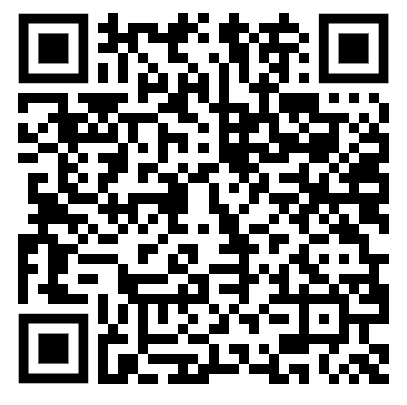

<a name="software-requirements"></a>
# 2) Software Requirements

### 2.1 Packages

Dieses Notebook wurde in Google Colab entwickelt. Die Laufzeitumgebung ist **Python 3.12.12**.

Folgende Libraries sind notwendig:

* **numpy**  

* **TensorFlow**  
  
* **gdown**  

* **Pandas**  


In [ ]:
%%capture
!pip install tensorflow
!pip -q install gdown
!pip install pandas


In [ ]:
!pip freeze

<details>
   <summary>Pip-Log</summary>

```
absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
aiosqlite==0.22.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.2
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.0
anywidget==0.9.21
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2025.12.15.0.40.51
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.6
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.30.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==3.12.2
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.4
captum==0.8.0
catalogue==2.0.10
certifi==2025.11.12
cffi==2.0.0
chardet==5.2.0
charset-normalizer==3.4.4
chex==0.1.90
clarabel==0.11.1
click==8.3.1
click-plugins==1.1.1.2
cligj==0.7.2
cloudpathlib==0.23.0
cloudpickle==3.1.2
cmake==3.31.10
cmdstanpy==1.3.0
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
community==1.0.0b1
confection==0.1.5
cons==0.4.7
contourpy==1.3.3
cramjam==2.11.0
cryptography==43.0.3
cufflinks==0.17.3
curl_cffi==0.13.0
cvxopt==1.3.2
cvxpy==1.6.7
cycler==0.12.1
cyipopt==1.5.0
cymem==2.0.13
Cython==3.0.12
dask==2025.12.0
dataproc-spark-connect==1.0.1
datasets==4.0.0
db-dtypes==1.4.4
dbus-python==1.2.18
debugpy==1.8.15
decorator==4.4.2
defusedxml==0.7.1
deprecation==2.1.0
diffusers==0.36.0
dill==0.3.8
distro==1.9.0
dlib==19.24.6
dm-tree==0.1.9
docstring_parser==0.17.0
docutils==0.21.2
dopamine_rl==4.1.2
duckdb==1.3.2
earthengine-api==1.5.24
easydict==1.13
editdistance==0.8.1
eerepr==0.1.2
einops==0.8.1
en_core_web_sm @ https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl#sha256=1932429db727d4bff3deed6b34cfc05df17794f4a52eeb26cf8928f7c1a0fb85
entrypoints==0.4
esda==2.8.0
et_xmlfile==2.0.0
etils==1.13.0
etuples==0.3.10
Farama-Notifications==0.0.4
fastai==2.8.6
fastapi==0.123.10
fastcore==1.9.2
fastdownload==0.0.7
fastjsonschema==2.21.2
fastprogress==1.0.3
fasttransform==0.0.2
ffmpy==1.0.0
filelock==3.20.0
fiona==1.10.1
firebase-admin==6.9.0
Flask==3.1.2
flatbuffers==25.9.23
flax==0.10.7
folium==0.20.0
fonttools==4.61.1
fqdn==1.5.1
frozendict==2.4.7
frozenlist==1.8.0
fsspec==2025.3.0
future==1.0.0
gast==0.7.0
gcsfs==2025.3.0
GDAL==3.8.4
gdown==5.2.0
geemap==0.35.3
geocoder==1.38.1
geographiclib==2.1
geopandas==1.1.1
geopy==2.4.1
giddy==2.3.8
gin-config==0.5.0
gitdb==4.0.12
GitPython==3.1.45
glob2==0.7
google==3.0.0
google-adk==1.21.0
google-ai-generativelanguage==0.6.15
google-api-core==2.28.1
google-api-python-client==2.187.0
google-auth==2.43.0
google-auth-httplib2==0.2.1
google-auth-oauthlib==1.2.2
google-cloud-aiplatform==1.130.0
google-cloud-appengine-logging==1.7.0
google-cloud-audit-log==0.4.0
google-cloud-bigquery==3.38.0
google-cloud-bigquery-connection==1.19.0
google-cloud-bigquery-storage==2.35.0
google-cloud-bigtable==2.34.0
google-cloud-core==2.5.0
google-cloud-dataproc==5.23.0
google-cloud-datastore==2.21.0
google-cloud-discoveryengine==0.13.12
google-cloud-firestore==2.21.0
google-cloud-functions==1.21.0
google-cloud-language==2.18.0
google-cloud-logging==3.12.1
google-cloud-monitoring==2.28.0
google-cloud-resource-manager==1.15.0
google-cloud-secret-manager==2.25.0
google-cloud-spanner==3.60.0
google-cloud-speech==2.34.0
google-cloud-storage==3.7.0
google-cloud-trace==1.17.0
google-cloud-translate==3.23.0
google-colab @ file:///colabtools/dist/google_colab-1.0.0.tar.gz
google-crc32c==1.7.1
google-genai==1.55.0
google-generativeai==0.8.5
google-pasta==0.2.0
google-resumable-media==2.8.0
googleapis-common-protos==1.72.0
googledrivedownloader==1.1.0
gradio==5.50.0
gradio_client==1.14.0
graphviz==0.21
greenlet==3.3.0
groovy==0.1.2
grpc-google-iam-v1==0.14.3
grpc-interceptor==0.15.4
grpcio==1.76.0
grpcio-status==1.71.2
grpclib==0.4.9
gspread==6.2.1
gspread-dataframe==4.0.0
gym==0.25.2
gym-notices==0.1.0
gymnasium==1.2.2
h11==0.16.0
h2==4.3.0
h5netcdf==1.7.3
h5py==3.15.1
hdbscan==0.8.41
hf-xet==1.2.0
hf_transfer==0.1.9
highspy==1.12.0
holidays==0.86
holoviews==1.22.1
hpack==4.1.0
html5lib==1.1
httpcore==1.0.9
httpimport==1.4.1
httplib2==0.31.0
httpx==0.28.1
httpx-sse==0.4.3
huggingface-hub==0.36.0
humanize==4.14.0
hyperframe==6.1.0
hyperopt==0.2.7
ibis-framework==9.5.0
idna==3.11
ImageIO==2.37.2
imageio-ffmpeg==0.6.0
imagesize==1.4.1
imbalanced-learn==0.14.0
immutabledict==4.2.2
importlib_metadata==8.7.0
importlib_resources==6.5.2
imutils==0.5.4
inequality==1.1.2
inflect==7.5.0
iniconfig==2.3.0
intel-cmplr-lib-ur==2025.3.1
intel-openmp==2025.3.1
ipyevents==2.0.4
ipyfilechooser==0.6.0
ipykernel==6.17.1
ipyleaflet==0.20.0
ipyparallel==8.8.0
ipython==7.34.0
ipython-genutils==0.2.0
ipython-sql==0.5.0
ipytree==0.2.2
ipywidgets==7.7.1
isoduration==20.11.0
itsdangerous==2.2.0
jaraco.classes==3.4.0
jaraco.context==6.0.1
jaraco.functools==4.3.0
jax==0.7.2
jaxlib==0.7.2
jeepney==0.9.0
jieba==0.42.1
Jinja2==3.1.6
jiter==0.12.0
joblib==1.5.3
jsonpatch==1.33
jsonpickle==4.1.1
jsonpointer==3.0.0
jsonschema==4.25.1
jsonschema-specifications==2025.9.1
jupyter-console==6.6.3
jupyter-events==0.12.0
jupyter-leaflet==0.20.0
jupyter_client==7.4.9
jupyter_core==5.9.1
jupyter_kernel_gateway @ git+https://github.com/googlecolab/kernel_gateway@b134e9945df25c2dcb98ade9129399be10788671
jupyter_server==2.14.0
jupyter_server_terminals==0.5.3
jupyterlab_pygments==0.3.0
jupyterlab_widgets==3.0.16
jupytext==1.18.1
kaggle==1.7.4.5
kagglehub==0.3.13
keras==3.10.0
keras-hub==0.21.1
keras-nlp==0.21.1
keyring==25.7.0
keyrings.google-artifactregistry-auth==1.1.2
kiwisolver==1.4.9
langchain==1.2.0
langchain-core==1.2.1
langgraph==1.0.5
langgraph-checkpoint==3.0.1
langgraph-prebuilt==1.0.5
langgraph-sdk==0.3.0
langsmith==0.4.59
lark==1.3.1
launchpadlib==1.10.16
lazr.restfulclient==0.14.4
lazr.uri==1.0.6
lazy_loader==0.4
libclang==18.1.1
libpysal==4.13.0
librosa==0.11.0
lightgbm==4.6.0
linkify-it-py==2.0.3
llvmlite==0.43.0
locket==1.0.0
logical-unification==0.4.7
lxml==6.0.2
Mako==1.3.10
mapclassify==2.10.0
Markdown==3.10
markdown-it-py==4.0.0
MarkupSafe==3.0.3
matplotlib==3.10.0
matplotlib-inline==0.2.1
matplotlib-venn==1.1.2
mcp==1.24.0
mdit-py-plugins==0.5.0
mdurl==0.1.2
mgwr==2.2.1
miniKanren==1.0.5
missingno==0.5.2
mistune==3.1.4
mizani==0.13.5
mkl==2025.3.0
ml_dtypes==0.5.4
mlxtend==0.23.4
mmh3==5.2.0
momepy==0.10.0
more-itertools==10.8.0
moviepy==1.0.3
mpmath==1.3.0
msgpack==1.1.2
multidict==6.7.0
multipledispatch==1.0.0
multiprocess==0.70.16
multitasking==0.0.12
murmurhash==1.0.15
music21==9.9.1
namex==0.1.0
narwhals==2.13.0
natsort==8.4.0
nbclassic==1.3.3
nbclient==0.10.2
nbconvert==7.16.6
nbformat==5.10.4
ndindex==1.10.1
nest-asyncio==1.6.0
networkx==3.6.1
nibabel==5.3.3
nltk==3.9.1
notebook==6.5.7
notebook_shim==0.2.4
numba==0.60.0
numexpr==2.14.1
numpy==1.26.4
nvidia-nccl-cu12==2.28.9
oauth2client==4.1.3
oauthlib==3.3.1
omegaconf==2.3.0
onemkl-license==2025.3.0
openai==2.12.0
opencv-contrib-python==4.12.0.88
opencv-python==4.12.0.88
opencv-python-headless==4.12.0.88
openpyxl==3.1.5
opentelemetry-api==1.37.0
opentelemetry-exporter-gcp-logging==1.11.0a0
opentelemetry-exporter-gcp-monitoring==1.11.0a0
opentelemetry-exporter-gcp-trace==1.11.0
opentelemetry-exporter-otlp-proto-common==1.37.0
opentelemetry-exporter-otlp-proto-http==1.37.0
opentelemetry-proto==1.37.0
opentelemetry-resourcedetector-gcp==1.11.0a0
opentelemetry-sdk==1.37.0
opentelemetry-semantic-conventions==0.58b0
opt_einsum==3.4.0
optax==0.2.6
optree==0.18.0
orbax-checkpoint==0.11.31
orjson==3.11.5
ormsgpack==1.12.1
osqp==1.0.5
overrides==7.7.0
packaging==25.0
pandas==2.2.2
pandas-datareader==0.10.0
pandas-gbq==0.30.0
pandas-stubs==2.2.2.240909
pandocfilters==1.5.1
panel==1.8.4
param==2.3.1
parso==0.8.5
parsy==2.2
partd==1.4.2
patsy==1.0.2
peewee==3.18.3
peft==0.18.0
pexpect==4.9.0
pickleshare==0.7.5
pillow==11.3.0
platformdirs==4.5.1
plotly==5.24.1
plotnine==0.14.5
pluggy==1.6.0
plum-dispatch==2.6.0
ply==3.11
pointpats==2.5.2
polars==1.31.0
pooch==1.8.2
portpicker==1.5.2
preshed==3.0.12
prettytable==3.17.0
proglog==0.1.12
progressbar2==4.5.0
prometheus_client==0.23.1
promise==2.3
prompt_toolkit==3.0.52
propcache==0.4.1
prophet==1.2.1
proto-plus==1.26.1
protobuf==5.29.5
psutil==5.9.5
psycopg2==2.9.11
psygnal==0.15.0
ptyprocess==0.7.0
PuLP==3.3.0
py-cpuinfo==9.0.0
py4j==0.10.9.9
pyarrow==18.1.0
pyasn1==0.6.1
pyasn1_modules==0.4.2
pycairo==1.29.0
pycocotools==2.0.10
pycparser==2.23
pycryptodomex==3.23.0
pydantic==2.12.3
pydantic-settings==2.12.0
pydantic_core==2.41.4
pydata-google-auth==1.9.1
pydot==4.0.1
pydotplus==2.0.2
PyDrive2==1.21.3
pydub==0.25.1
pyerfa==2.0.1.5
pygame==2.6.1
pygit2==1.19.0
Pygments==2.19.2
PyGObject==3.48.2
PyJWT==2.10.1
pymc==5.26.1
pynndescent==0.5.13
pyogrio==0.12.1
pyomo==6.9.5
PyOpenGL==3.1.10
pyOpenSSL==24.2.1
pyparsing==3.2.5
pyperclip==1.11.0
pyproj==3.7.2
pysal==25.7
pyshp==3.0.3
PySocks==1.7.1
pyspark==4.0.1
pytensor==2.35.1
pytest==8.4.2
python-apt==0.0.0
python-box==7.3.2
python-dateutil==2.9.0.post0
python-dotenv==1.2.1
python-json-logger==4.0.0
python-louvain==0.16
python-multipart==0.0.20
python-slugify==8.0.4
python-snappy==0.7.3
python-utils==3.9.1
pytz==2025.2
pyviz_comms==3.0.6
PyWavelets==1.9.0
PyYAML==6.0.3
pyzmq==26.2.1
quantecon==0.10.1
quantus==0.6.0
rasterio==1.4.4
rasterstats==0.20.0
ratelim==0.1.6
referencing==0.37.0
regex==2025.11.3
requests==2.32.4
requests-oauthlib==2.0.0
requests-toolbelt==1.0.0
requirements-parser==0.9.0
rfc3339-validator==0.1.4
rfc3986-validator==0.1.1
rfc3987-syntax==1.1.0
rich==13.9.4
roman-numerals-py==3.1.0
rpds-py==0.30.0
rpy2==3.5.17
rsa==4.9.1
rtree==1.4.1
ruff==0.14.9
safehttpx==0.1.7
safetensors==0.7.0
scikit-base==0.13.0
scikit-image==0.25.2
scikit-learn==1.6.1
scipy==1.16.3
scooby==0.11.0
scs==3.2.9
seaborn==0.13.2
SecretStorage==3.5.0
segregation==2.5.3
semantic-version==2.10.0
Send2Trash==1.8.3
sentence-transformers==5.2.0
sentencepiece==0.2.1
sentry-sdk==2.47.0
setuptools==75.2.0
shap==0.50.0
shapely==2.1.2
shellingham==1.5.4
simple-parsing==0.1.7
simplejson==3.20.2
simsimd==6.5.3
six==1.17.0
sklearn-pandas==2.2.0
sktime==0.40.1
slicer==0.0.8
smart_open==7.5.0
smmap==5.0.2
sniffio==1.3.1
snowballstemmer==3.0.1
soundfile==0.13.1
soupsieve==2.8
soxr==1.0.0
spacy==3.8.11
spacy-legacy==3.0.12
spacy-loggers==1.0.5
spaghetti==1.7.6
spanner-graph-notebook==1.1.8
spglm==1.1.0
Sphinx==8.2.3
sphinxcontrib-applehelp==2.0.0
sphinxcontrib-devhelp==2.0.0
sphinxcontrib-htmlhelp==2.1.0
sphinxcontrib-jsmath==1.0.1
sphinxcontrib-qthelp==2.0.0
sphinxcontrib-serializinghtml==2.0.0
spint==1.0.7
splot==1.1.7
spopt==0.7.0
spreg==1.8.4
SQLAlchemy==2.0.45
sqlalchemy-spanner==1.17.1
sqlglot==25.20.2
sqlparse==0.5.4
srsly==2.5.2
sse-starlette==3.0.4
stanio==0.5.1
starlette==0.50.0
statsmodels==0.14.6
stringzilla==4.5.1
stumpy==1.13.0
sympy==1.14.0
tables==3.10.2
tabulate==0.9.0
tbb==2022.3.0
tcmlib==1.4.1
tenacity==9.1.2
tensorboard==2.19.0
tensorboard-data-server==0.7.2
tensorflow==2.19.0
tensorflow-datasets==4.9.9
tensorflow-hub==0.16.1
tensorflow-metadata==1.17.2
tensorflow-probability==0.25.0
tensorflow-text==2.19.0
tensorflow_decision_forests==1.12.0
tensorstore==0.1.80
termcolor==3.2.0
terminado==0.18.1
text-unidecode==1.3
textblob==0.19.0
tf-explain==0.3.1
tf-slim==1.1.0
tf_keras==2.19.0
thinc==8.3.10
threadpoolctl==3.6.0
tifffile==2025.12.12
tiktoken==0.12.0
timm==1.0.22
tinycss2==1.4.0
tobler==0.12.1
tokenizers==0.22.1
toml==0.10.2
tomlkit==0.13.3
toolz==0.12.1
torch==2.9.0+cpu
torchao==0.10.0
torchaudio==2.9.0+cpu
torchdata==0.11.0
torchsummary==1.5.1
torchtune==0.6.1
torchvision==0.24.0+cpu
tornado==6.5.1
tqdm==4.67.1
traitlets==5.7.1
traittypes==0.2.3
transformers==4.57.3
treescope==0.1.10
tsfresh==0.21.1
tweepy==4.16.0
typeguard==4.4.4
typer==0.20.0
typer-slim==0.20.0
types-pytz==2025.2.0.20251108
types-setuptools==80.9.0.20250822
typing-inspection==0.4.2
typing_extensions==4.15.0
tzdata==2025.3
tzlocal==5.3.1
uc-micro-py==1.0.3
umap-learn==0.5.9.post2
umf==1.0.2
uri-template==1.3.0
uritemplate==4.2.0
urllib3==2.5.0
uuid_utils==0.12.0
uvicorn==0.38.0
vega-datasets==0.9.0
wadllib==1.3.6
wandb==0.23.1
wasabi==1.1.3
watchdog==6.0.0
wcwidth==0.2.14
weasel==0.4.3
webcolors==25.10.0
webencodings==0.5.1
websocket-client==1.9.0
websockets==15.0.1
Werkzeug==3.1.4
wheel==0.45.1
widgetsnbextension==3.6.10
wordcloud==1.9.4
wrapt==2.0.1
wurlitzer==3.1.1
xarray==2025.12.0
xarray-einstats==0.9.1
xgboost==3.1.2
xlrd==2.0.2
xxhash==3.6.0
xyzservices==2025.11.0
yarl==1.22.0
ydf==0.13.0
yellowbrick==1.5
yfinance==0.2.66
zipp==3.23.0
zstandard==0.25.0
```



>⚠️ **Ggf. ist Laufzeit-Neustart notwendig!**  
>Menü oben links: **Laufzeit** → **Sitzung neu starten**



### 2.2 Hardware Accelerator

 >⚠️ **Einschalten der T4 GPU (optional, notwendig fürs Training)**  
 >Menü oben links **Laufzeit** → **Laufzeit ändern** → wähle **T4 GPU**.  
 >Nur notwendig, wenn man die Modelle trainieren will. Für Visualisierungen etc. reicht die CPU.


In [ ]:
import tensorflow as tf
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

<a name="data-understanding"></a>
# 3) Data Understanding

Wir verwenden den MVTec-Datensatz von [MVTec Software](https://www.mvtec.com/company/research/datasets/mvtec-ad). Der Datensatz ist für das Benchmarking von Anomalieerkennungen gedacht. Wir verwenden diesen für die Klassifikation. Der Datensatz wird über diese [Link](https://drive.google.com/file/d/1dvMJAcDLnU1GiPZGp-uqwahBbKyGj_0y/view?usp=sharing) via Google Drive bereitgestellt.

Das MVTec AD Dataset ist in 15 Objektkategorien unterteilt.
Jede Kategorie besitzt einen Trainings- und einen Testordner.
Der Trainingsdatensatz enthält ausschließlich fehlerfreie ("good") Bilder,
während der Testdatensatz sowohl fehlerfreie als auch defekte Beispiele umfasst.
Für jede Defektklasse existieren zusätzlich Pixel-genaue Ground-Truth-Masken
im Ordner `ground_truth`, die nur für defekte Bilder vorhanden sind.

MVTec AD Dataset:

```
dataset_root/
├─ bottle/
├─ cable/
├─ capsule/
├─ carpet/
├─ grid/
├─ hazelnut/
├─ leather/
├─ metal_nut/
├─ pill/
├─ screw/
├─ tile/
├─ toothbrush/
├─ transistor/
├─ wood/
└─ zipper/
```

Jede Kategorie hat die gleiche Grundstruktur:
```
<category>/
├─ train/
│  └─ good/                 # nur "good" im Training
├─ test/
│  ├─ good/                 # gute Testbilder
│  └─ <defect_type>/        # Defektklassen (z.B. crack, contamination, ...)
└─ ground_truth/
   └─ <defect_type>/        # Pixel-Masken zu den Defekten (nur für Defekte)
```



## 3.1 Dataclass

Um einen Überblick über den verwendeten Datensatz zu erhalten, werden für alle Bilder die relevanten Metadaten erfasst. Diese Metadaten bilden die Grundlage für die weitere Verarbeitung und Analyse.

Folgende Informationen sind relevant:

- Der Dateipfad des Bildes  
- Die zugehörige Kategorie (z. B. *cable*)  
- Der Status des Bildes (fehlerfrei oder fehlerhaft)  
- Der Fehlertyp, abgeleitet aus dem jeweiligen Ordnernamen  
  (z. B. *broken_large* in der Kategorie *bottle*)


In [ ]:
class ImageMetaData:
    def __init__(self, path: str, category: str, is_ok: bool, error_type: str | None = None):
        self.path: str = path
        self.category: str = category
        self.is_ok: bool = bool(is_ok)
        self.error_type: str | None = error_type

    def print(self) -> str:
        status = "IO" if self.is_ok else "NIO"
        err = self.error_type if self.error_type is not None else "none"
        return f"ImageMetaData(path='{self.path}', category='{self.category}', status='{status}', error_type='{err}')"

### 3.1.1 Download dataset

Für dieses Colab wird der MVTec-Datensatz [hier](https://drive.google.com/file/d/1dvMJAcDLnU1GiPZGp-uqwahBbKyGj_0y/view?usp=sharing) über Google Drive bereitgestellt.

Lädt die Datei `mvtec.tar.xz` aus Google Drive herunter (falls es noch nicht vorhanden ist).


In [ ]:
import os
import gdown

def download_datasets() -> str:
    data_dir = "/content/data"
    os.makedirs(data_dir, exist_ok=True)

    file_url = "https://drive.google.com/file/d/1dvMJAcDLnU1GiPZGp-uqwahBbKyGj_0y/view?usp=sharing"
    out_path = os.path.join(data_dir, "mvtec_anomaly_detection.tar.xz")

    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        print(f"Info: File already exists -> skipping ({out_path})")
        return out_path

    print("Info: Downloading mvtec_anomaly_detection.tar.xz ...")
    gdown.download(
        url=file_url,
        output=out_path,
        quiet=False,
        fuzzy=True,
        use_cookies=True,
    )

    print(f"Info: Done -> {out_path}")
    return out_path

### 3.1.2 Unzip dataset

Extrahiert das `mvtec_anomaly_detection.tar.xz` Archiv in den `data/` Ordner (falls es noch nicht entpackt wurde).

In [ ]:
import os
import tarfile

def unzip_datasets() -> None:
    data_dir = "data"
    prefix = "mvtec_anomaly_detection"

    tar_path = os.path.join(data_dir, f"{prefix}.tar.xz")
    out_dir  = os.path.join(data_dir, prefix)

    if not os.path.exists(tar_path):
        print(f"Warning: {prefix}: archive not found -> skipping ({tar_path})")
        return

    if os.path.isdir(out_dir) and len(os.listdir(out_dir)) > 0:
        print(f"Info: {prefix}: already extracted -> skipping ({out_dir})")
        return

    os.makedirs(out_dir, exist_ok=True)
    print(f"Info: Extracting {prefix} -> {out_dir}")

    with tarfile.open(tar_path, "r:xz") as t:
        t.extractall(out_dir)


### 3.1.3 Load metainfos to dataclass

Erstellt eine Liste an `ImageMetaData` aus dem extrahierten `mvtec_anomaly_detection.tar.xz` Archiv.

In [ ]:
from pathlib import Path
from typing import Optional, List

def build_metadata() -> List[ImageMetaData]:
    dataset_root = Path("data") / "mvtec_anomaly_detection"
    root = Path(dataset_root)
    items: List[ImageMetaData] = []

    for category_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        category = category_dir.name

        train_good_dir = category_dir / "train" / "good"
        test_good_dir  = category_dir / "test" / "good"

        if train_good_dir.is_dir():
            for p in sorted(train_good_dir.rglob("*.png")):
                items.append(ImageMetaData(str(p), category, True, None))

        if test_good_dir.is_dir():
            for p in sorted(test_good_dir.rglob("*.png")):
                items.append(ImageMetaData(str(p), category, True, None))

        test_dir = category_dir / "test"
        if test_dir.is_dir():
            for defect_dir in sorted([d for d in test_dir.iterdir() if d.is_dir() and d.name != "good"]):
                defect_type = defect_dir.name
                for p in sorted(defect_dir.rglob("*.png")):
                    items.append(ImageMetaData(str(p), category, False, defect_type))

    return items


### 3.1.4 Execute

In [ ]:
download_datasets()
unzip_datasets()
data_infos: List[ImageMetaData] = build_metadata()

## 3.2 Analyze Category-ratio and IO/NIO-ratios

Auf Basis der Liste an `ImageMetaData` wird ein Pandas `DataFrame` erstellt, in dem wir analysieren, wie das Verhältnis der Klassen untereinander ist. Pro Klasse untersuchen wir zudem das Verhältnis zwischen IO und NIO.


In [ ]:
import pandas as pd
from typing import Optional, List

def dataset_summary(data_infos: List[ImageMetaData]) -> pd.DataFrame:
    data_frame = pd.DataFrame([{
        "path":         info.path,
        "category":     info.category,
        "is_ok":        info.is_ok,
        "error_type":   info.error_type
    } for info in data_infos])

    amount_total_all: int = len(data_frame)
    summary = []

    # Categories
    for category, group in data_frame.groupby("category"):
        good_dataframe: pd.DataFrame = group[group["is_ok"] == True]
        bad_dataframe: pd.DataFrame  = group[group["is_ok"] == False]

        amount_total: int = len(group)
        amount_good: int = len(good_dataframe)
        amount_bad: int = len(bad_dataframe)

        category_share_percent: float = amount_total / amount_total_all * 100.0
        good_share_percent: float = amount_good / amount_total * 100.0
        bad_share_percent: float  = amount_bad / amount_total * 100.0

        unique_error_types = ((bad_dataframe["error_type"].dropna()).unique())
        amount_error_types: int = len(unique_error_types)

        summary.append({
            "category": category,
            "category_share_percent": category_share_percent,
            "amount_total": amount_total,
            "amount_good": amount_good,
            "amount_bad": amount_bad,
            "bad_share_percent": bad_share_percent,
            "good_share_percent": good_share_percent,
            "amount_error_types": amount_error_types
        })

    # All categories
    good_dataframe: pd.DataFrame = data_frame[data_frame["is_ok"] == True]
    bad_dataframe: pd.DataFrame  = data_frame[data_frame["is_ok"] == False]

    amount_total: int = len(data_frame)
    amount_good: int = len(good_dataframe)
    amount_bad: int = len(bad_dataframe)

    good_share_percent: float = amount_good / amount_total * 100.0
    bad_share_percent: float  = amount_bad / amount_total * 100.0

    unique_error_types = ((bad_dataframe["error_type"].dropna()).unique())
    amount_error_types: int = len(unique_error_types)

    summary.append({
        "category": "All",
        "category_share_percent": 100.0,
        "amount_total": amount_total,
        "amount_good": amount_good,
        "amount_bad": amount_bad,
        "bad_share_percent": bad_share_percent,
        "good_share_percent": good_share_percent,
        "amount_error_types": amount_error_types
    })

    result_frame = pd.DataFrame(summary)
    return result_frame


In [ ]:
summary_dataframe = dataset_summary(data_infos)

summary_dataframe_to_display = summary_dataframe.rename(columns={
    "category": "Kategorie",
    "category_share_percent": "Anteil Kategorie (%)",
    "amount_total": "Gesamtanzahl",
    "amount_good": "Anzahl Ok",
    "amount_bad": "Anzahl Fehler",
    "good_share_percent": "Anteil Ok (%)",
    "bad_share_percent": "Anteil Fehler (%)",
    "amount_error_types": "Anzahl Fehlertypen",
})

display(summary_dataframe_to_display.style.format({
    "Anteil Ok (%)": "{:.0f} %",
    "Anteil Fehler (%)": "{:.0f} %",
    "Anteil Kategorie (%)": "{:.0f} %"
}))

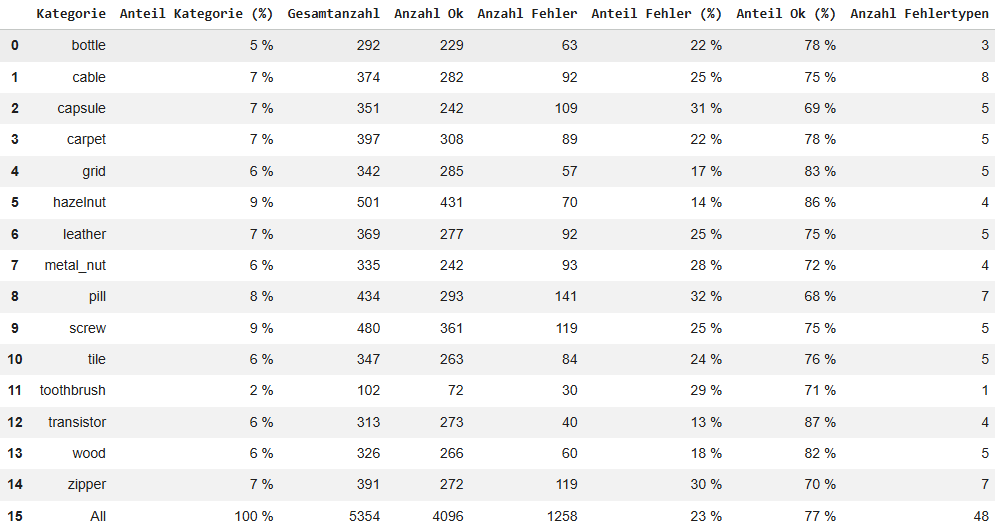

Insgesamt sind die Klassen im Datensatz weitgehend ausgewogen verteilt. Eine Ausnahme bildet die Kategorie *toothbrush*, da im Vergleich zu anderen Kategorien relativ wenige Beispiele vorhanden sind.

Deutlich kritischer ist die stark schiefe Verteilung zwischen fehlerfreien (*good*) und fehlerhaften (*bad*) Bildern über alle Kategorien hinweg. In nahezu allen Klassen überwiegen die fehlerfreien Beispiele deutlich. Bei der Modellierung muss daher berücksichtigt werden, das es sich um ein stark unausgeglichenes Klassifikationsproblem handelt.

## 3.3 Analyze Error-Categoy ratios within NIO

Im Folgenden untersuchen wir wie sich die Fehlerkategorien innerhalb einer Kategorie zueinenader verhalten. Wir verwenden dafür wieder die Liste an `ImageMetaData` und erstellen uns daraus ein Pandas `DataFrame`.

In [ ]:
import pandas as pd
from typing import List

def error_type_share_per_category(data_infos: List[ImageMetaData]) -> pd.DataFrame:
    data_frame = pd.DataFrame([{
        "path":         info.path,
        "category":     info.category,
        "is_ok":        info.is_ok,
        "error_type":   info.error_type
    } for info in data_infos])

    bad_dataframe: pd.DataFrame = data_frame[data_frame["is_ok"] == False].copy()

    count_frame: pd.DataFrame = (
        bad_dataframe
        .groupby(["category", "error_type"], dropna=True)
        .size()
        .reset_index(name="amount_error_images")
    )

    count_frame["amount_error_images_total_category"] = (
        count_frame
        .groupby("category")["amount_error_images"]
        .transform("sum")
    )

    count_frame["error_type_share_percent_in_category"] = (
        count_frame["amount_error_images"] / count_frame["amount_error_images_total_category"] * 100.0
    )

    count_frame["amount_error_types_in_category"] = (
        count_frame
        .groupby("category")["error_type"]
        .transform("nunique")
    )

    count_frame["perfect_balance_share_percent_in_category"] = (
        100.0 / count_frame["amount_error_types_in_category"]
    )

    count_frame["difference_percent_points"] = (
        count_frame["error_type_share_percent_in_category"]
        - count_frame["perfect_balance_share_percent_in_category"]
    )

    result_frame: pd.DataFrame = (
        count_frame
        .sort_values(["category", "error_type_share_percent_in_category"], ascending=[True, False])
        .reset_index(drop=True)
    )

    return result_frame

In [ ]:
error_type_share_dataframe = error_type_share_per_category(data_infos)

error_type_share_dataframe_to_display = error_type_share_dataframe.rename(columns={
    "category": "Kategorie",
    "error_type": "Fehlertyp",
    "amount_error_images": "Anzahl Fehlerbilder",
    "amount_error_images_total_category": "Anzahl Fehlerbilder Gesamt (Kategorie)",
    "error_type_share_percent_in_category": "Anteil Fehlertyp innerhalb Kategorie (%)",
    "amount_error_types_in_category": "Anzahl Fehlertypen (Kategorie)",
    "perfect_balance_share_percent_in_category": "Soll-Anteil perfekte Balance (%)",
    "difference_percent_points": "Abweichung (Prozentpunkte)",
})

display(error_type_share_dataframe_to_display.style.format({
    "Anteil Fehlertyp innerhalb Kategorie (%)": "{:.1f} %",
    "Soll-Anteil perfekte Balance (%)": "{:.2f} %",
    "Abweichung (Prozentpunkte)": "{:+.2f}",
}))


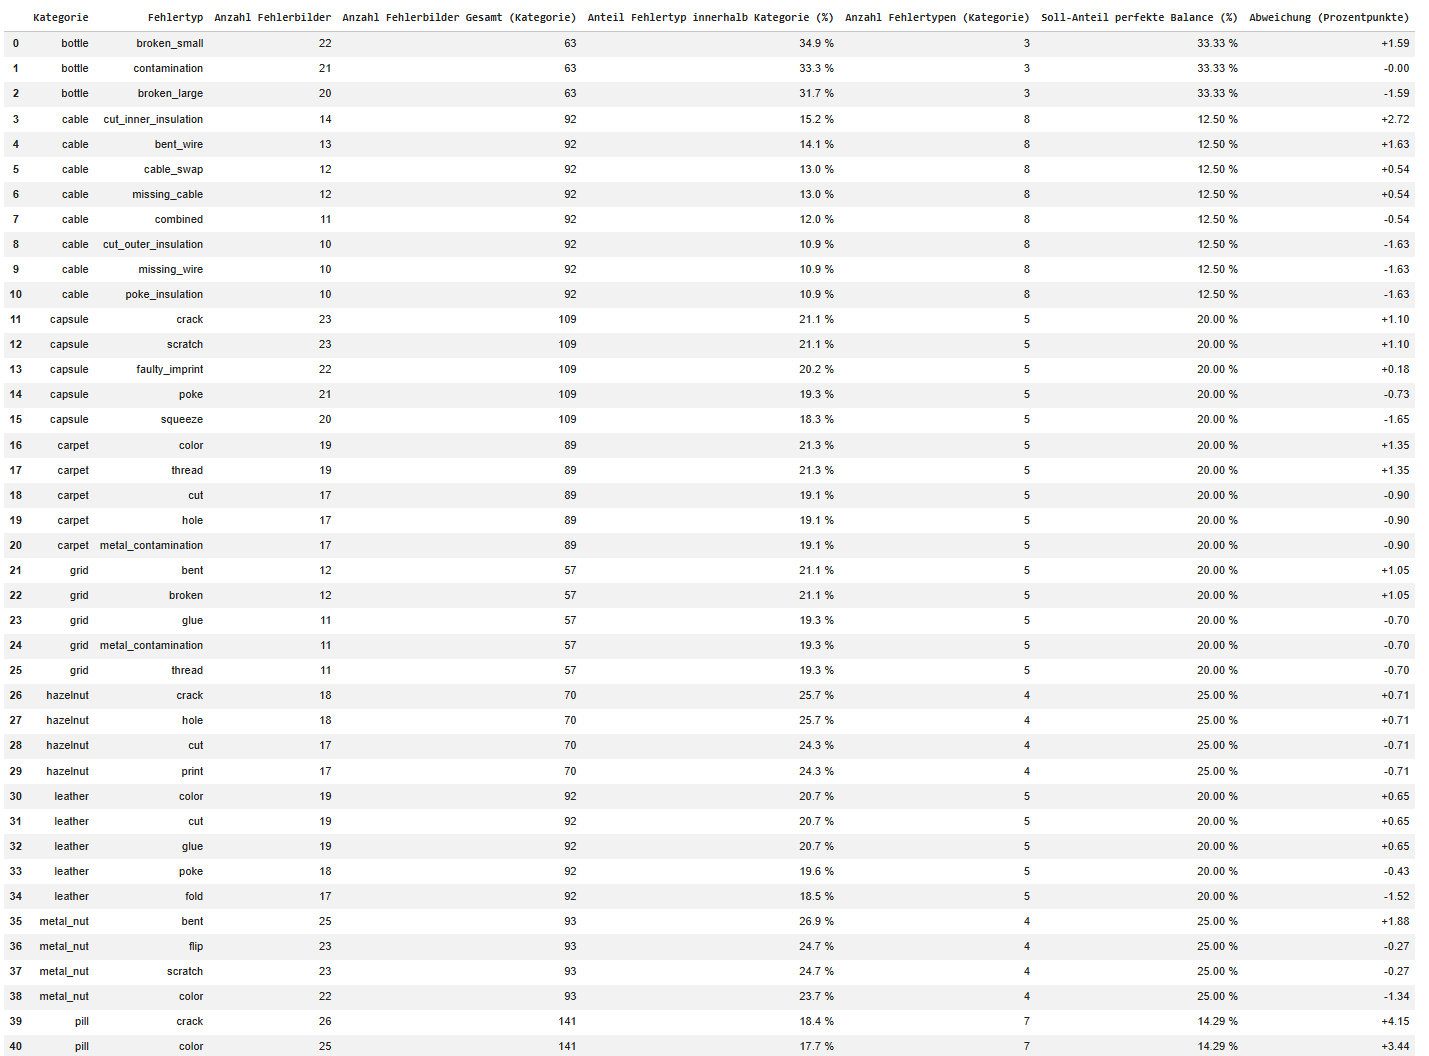

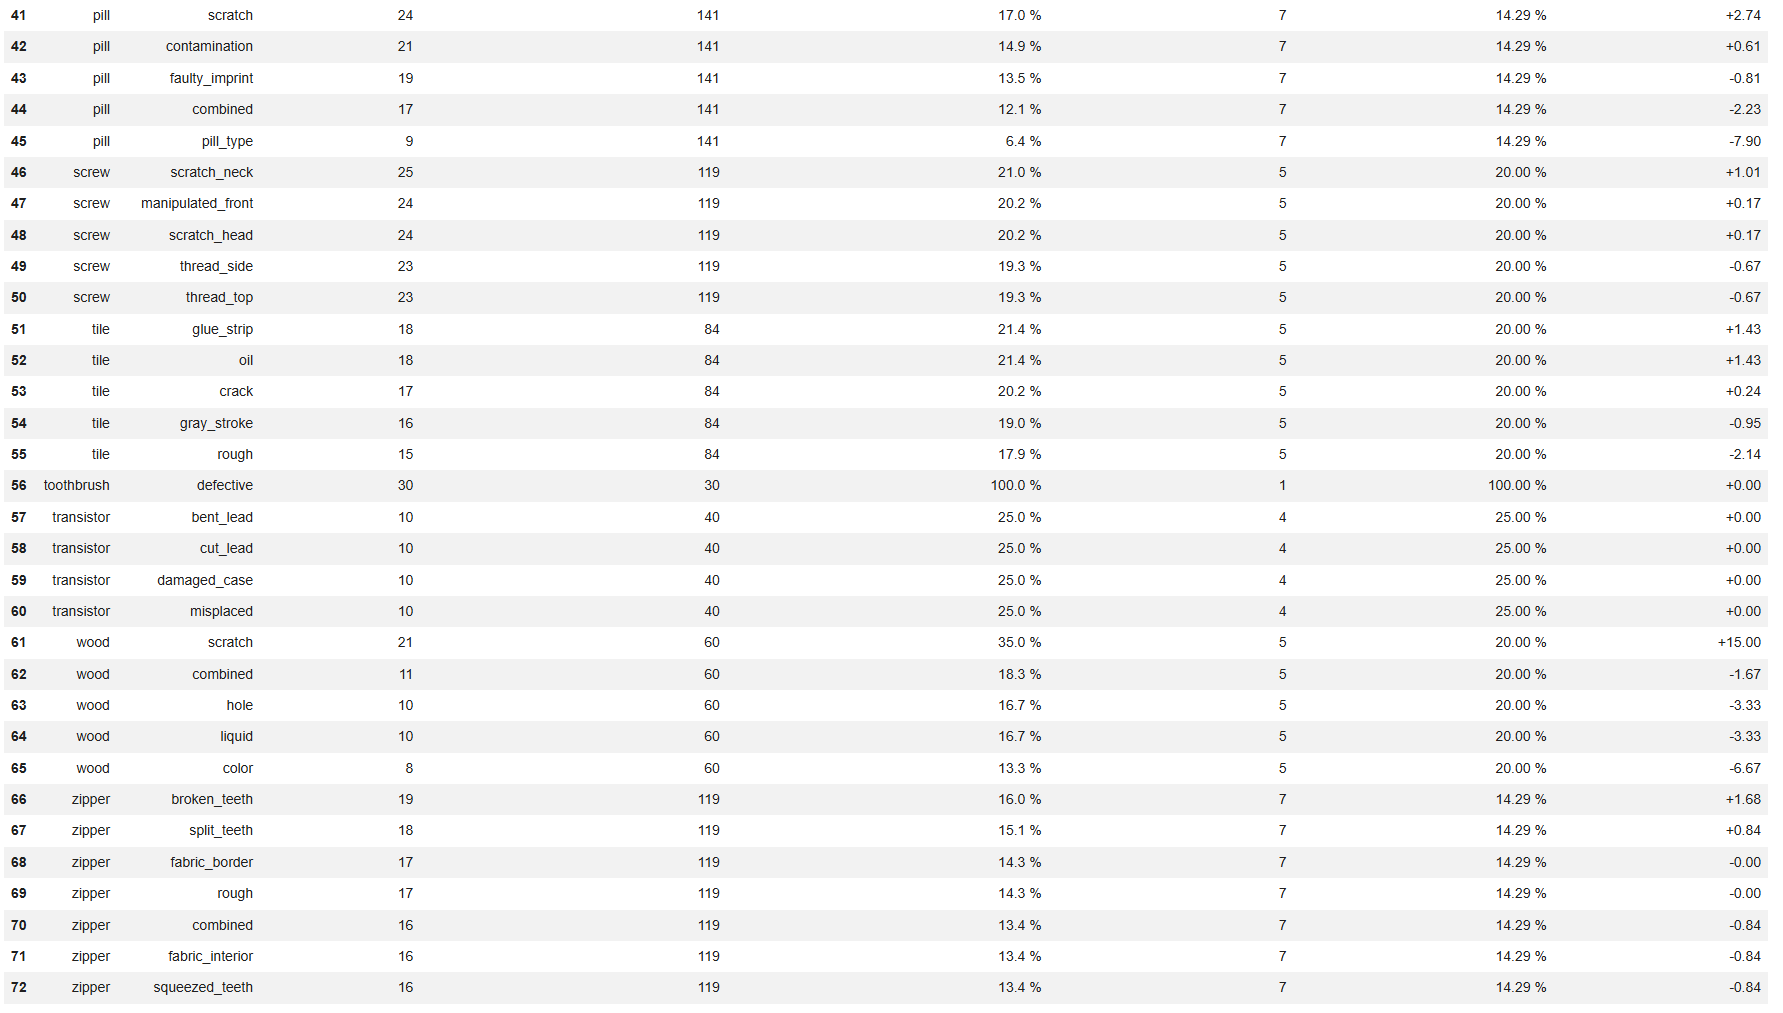

Werden die Fehlerkategorien betrachtet, so zeigt sich, dass diese ziemlich ausbalanziert sind. Eine Ausnahme bildet der Scratch beim Holz. Hier haben wir eine Abweichung von +15%. Das bedeutet, das diese Klasse innerhalb der Holzfehler etwas überrepräsentiert ist.

## 3.4 Summary

Für den Datensatz ist vorallem die stark schiefe Verteilung zwischen fehlerfreien und fehlerhaften Bildern über alle Kategorien hinweg kritsch. Die anderen Verteilungen sehen wir im Verhältnis als nicht so kritisch an. Wir fokusieren uns daher in diesem Colab auf die schiefe Verteilung zwischen IO und NIO.

<a name="data-preparation"></a>
# 4) Data Preparation

Ziel dieser Phase ist es, den MVTec-Datensatz von  [MVTec Software](https://www.mvtec.com/company/research/datasets/mvtec-ad) so umzustrukturieren, dass er  für die Bildklassifikation nach Kategorie und Zustand (IO, NIO) möglichst einfach eingesetzt werden kann.

In unserem Anwendungsfall soll später der Keras-Ordnerloader  
`keras.utils.image_dataset_from_directory` verwendet werden.  
Aus diesem Grund wird eine neue Verzeichnisstruktur aufgebaut, in der jede Kategorie in einen **IO**- und einen **NIO**-Ordner aufgeteilt wird.


- Im **IO-Ordner** befinden sich alle fehlerfreien Bilder (*good*) der jeweiligen Kategorie.  
- Alle fehlerhaften Bilder einer Kategorie werden gesammelt im **NIO-Ordner** abgelegt.  
- Die vorhandenen `ground_truth`-Masken werden in diesem Setup nicht verwendet.  
- Sämtliche Bilder werden über alle Kategorien hinweg von ursprünglich ca. **1–1.5 MB** auf etwa **5–10 KB** verkleinert, um die Trainingszeiten auf einem moderaten Niveau zu halten.  
- Zusätzlich wird **Data Augmentation** eingesetzt, um das Verhältnis zwischen **NIO**- und **IO**-Beispielen auszugleichen.
- Die Bilder werden in **Training**, **Validierung** und **Test** gesplittet. Wir stratifizieren dabei nach der Fehlerkategorie. Augmentate und deren Originale sind zudem immer im gleichen Split enthalten.

Links:

> Original-Ordner [hier](https://drive.google.com/file/d/1dvMJAcDLnU1GiPZGp-uqwahBbKyGj_0y/view?usp=sharing).

> Klassifikations-Ordner komprimiert mit Data Augmentation [hier](https://drive.google.com/file/d/1WwMxiOZ5RM-WUKqgjj0COcNpepw8uO8c/view?usp=sharing).

> Klassifikations-Ordner komprimiert ohne Data Augmenation [hier](https://drive.google.com/file/d/11jGWy7wVKnn0OeQ6a1Wc1-bgOMm7PAMX/view?usp=sharing).

> Klassifikations-Ordner komprimiert mit Data Augmentation nur nach Kategorie [hier](https://drive.google.com/file/d/18XJAFWiyFQJtasa39Xfv1Oe8e-xMgkX0/view?usp=sharing).

> Klassifikations-Ordner komprimiert ohne Data Augmenation nur nach Kategorie [hier](https://drive.google.com/file/d/1RwlzUVk6AiEHyHj7q8XXNygVh9E7tcPt/view?usp=sharing).

### Ordnerstruktur:

```
dataset_root/
├─ bottle_IO/      ├─ bottle_NIO/
├─ cable_IO/       ├─ cable_NIO/
├─ capsule_IO/     ├─ capsule_NIO/
├─ carpet_IO/      ├─ carpet_NIO/
├─ grid_IO/        ├─ grid_NIO/
├─ hazelnut_IO/    ├─ hazelnut_NIO/
├─ leather_IO/     ├─ leather_NIO/
├─ metal_nut_IO/   ├─ metal_nut_NIO/
├─ pill_IO/        ├─ pill_NIO/
├─ screw_IO/       ├─ screw_NIO/
├─ tile_IO/        ├─ tile_NIO/
├─ toothbrush_IO/  ├─ toothbrush_NIO/
├─ transistor_IO/  ├─ transistor_NIO/
├─ wood_IO/        ├─ wood_NIO/
└─ zipper_IO/      └─ zipper_NIO/
```

### NIO Ordner:

```
- bottle_NIO_broken_large_000.jpg
- bottle_NIO_broken_large_000__aug_01.jpg
- bottle_NIO_broken_large_000__aug_02.jpg
- bottle_NIO_broken_large_000__aug_03.jpg

- bottle_NIO_broken_large_001.jpg
- bottle_NIO_broken_large_001__aug_01.jpg
- bottle_NIO_broken_large_001__aug_02.jpg
- bottle_NIO_broken_large_001__aug_03.jpg
```

### IO Ordner:

```
- bottle_IO_good_000.jpg
- bottle_IO_good_001.jpg
- bottle_IO_good_002.jpg
- bottle_IO_good_003.jpg
```


## 4.1 Data Augmentation

Um das Verhältnis zwischen **NIO**- und **IO**-Beispielen auszugleichen, wird im folgenden **Data Augmentation** eingesetzt. Es werden dabei die **NIO** so oft augmentiert, sodass das Verhältnis zwischen **NIO** und **IO** exakt **50:50** ist.

### 4.1.1. Augmentation Policy

Nicht jede Augmentation ist für jede Kategorie sinnvoll. Eine falsche Transformationen kann die Bildinhalte verfälschen und künstliche Artefakte erzeugen (z. B. wenn eine Flasche durch Rotation/Interpolation plötzlich „Ecken“ bekommt). Daher wird die Augmentation pro Kategorie bewusst eingeschränkt und nur mit solchen Operationen umgesetzt, die zu einem realistischen Bild führen.

In [ ]:
from pathlib import Path

DEFAULT_POLICY = {
    # Geometrie
    "rotation_mode": "none",        # 'none' | 'small'
    "rotation_limit_deg": 0,
    "flip_strategy": None,          # None | 'h' | 'v' | 'one_of_hv'

    # Farbe / Belichtung
    "use_brightness_contrast": False,
    "brightness_limit": 0.0,
    "contrast_limit": 0.0,
    "brightness_p": 0.0,

    "use_hsv": False,
    "hue_shift_limit": 0,
    "sat_shift_limit": 0,
    "val_shift_limit": 0,
    "hsv_p": 0.0,

    "use_gamma": False,
    "gamma_limit": (100, 100),
    "gamma_p": 0.0,
}

POLICY = {
    # ───────────── kleine Rotation ─────────────
    "bottle":     {"rotation_mode": "small", "rotation_limit_deg": 10},
    "cable":      {"rotation_mode": "small", "rotation_limit_deg": 10},

    # ───────────── leichter Farb-/Belichtungsjitter ─────────────
    "capsule":    {
        "use_brightness_contrast": True,
        "brightness_limit": 0.08,
        "contrast_limit": 0.08,
        "brightness_p": 1.0,
        "use_hsv": True,
        "hue_shift_limit": 5,
        "sat_shift_limit": 8,
        "val_shift_limit": 8,
        "hsv_p": 1.0
    },

    "pill":       {
        "use_brightness_contrast": True,
        "brightness_limit": 0.08,
        "contrast_limit": 0.08,
        "brightness_p": 1.0,
        "use_hsv": True,
        "hue_shift_limit": 5,
        "sat_shift_limit": 10,
        "val_shift_limit": 8,
        "hsv_p": 1.0
    },

    # ───────────── Rotation + Farbe ─────────────
    "screw":      {
        "rotation_mode": "small",
        "rotation_limit_deg": 10,
        "use_brightness_contrast": True,
        "brightness_limit": 0.05,
        "contrast_limit": 0.05,
        "brightness_p": 1.0
    },

    # ───────────── Spiegelung zufällige Achse ─────────────
    "carpet":     {"flip_strategy": "one_of_hv"},
    "grid":       {"flip_strategy": "one_of_hv"},
    "hazelnut":   {"flip_strategy": "one_of_hv"},
    "metal_nut":  {"flip_strategy": "one_of_hv"},

    # ───────────── Spiegelung Y-Achse ─────────────
    "toothbrush": {"flip_strategy": "h"},
    "transistor": {"flip_strategy": "h"},
    "wood":       {"flip_strategy": "h"},
    "zipper":     {"flip_strategy": "h"},

    # Default
    "leather":    {},
    "tile":       {}
}

def policy_for(category: str) -> dict:
    # Defaults + spezifische Overrides (Overrides gewinnen)
    return {**DEFAULT_POLICY, **POLICY.get(category, {})}


### 4.1.2 Build Augmentationpipeline from policy

Baut eine Augmentierungspipeline unter der Verwendung der Policy für die Kategorie

In [ ]:
import albumentations as A
import cv2

def build_transform_for_category_from_policy(category: str) -> A.Compose:
    policy = policy_for(category)
    augmentation_steps = []



    # --- Rotation ---
    rotation_mode = policy.get("rotation_mode", "none")

    if rotation_mode == "discrete_90":
        rotation_transform = A.RandomRotate90(p=1.0)
        augmentation_steps.append(rotation_transform)

    elif rotation_mode == "small":
        rotation_limit_degrees = policy.get("rotation_limit_deg", 0)
        rotation_transform = A.Rotate(
            limit=rotation_limit_degrees,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        )
        augmentation_steps.append(rotation_transform)

    elif rotation_mode == "medium":
        rotation_limit_degrees = max(int(policy.get("rotation_limit_deg", 20)), 1)
        rotation_transform = A.Rotate(
            limit=rotation_limit_degrees,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        )
        augmentation_steps.append(rotation_transform)

    elif rotation_mode == "free":
        rotation_transform = A.Rotate(limit=180, border_mode=cv2.BORDER_REFLECT_101, p=1.0)
        augmentation_steps.append(rotation_transform)



    # --- Flips ---
    flip_strategy = policy.get("flip_strategy")
    flip_probability = policy.get("flip_prob", 1.0)

    if flip_strategy == "one_of_hv":
        horizontal_flip = A.HorizontalFlip(p=1.0)
        vertical_flip = A.VerticalFlip(p=1.0)
        flip_transform = A.OneOf([horizontal_flip, vertical_flip], p=1.0)
        augmentation_steps.append(flip_transform)

    elif flip_strategy == "h":
        flip_transform = A.HorizontalFlip(p=flip_probability)
        augmentation_steps.append(flip_transform)

    elif flip_strategy == "v":
        flip_transform = A.VerticalFlip(p=flip_probability)
        augmentation_steps.append(flip_transform)



    # --- Farb-/Belichtungsvariationen ---
    use_brightness_contrast = policy.get("use_brightness_contrast", False)
    brightness_probability = policy.get("brightness_p", 0.0)

    if use_brightness_contrast and brightness_probability > 0:
        brightness_transform = A.RandomBrightnessContrast(
            brightness_limit=policy.get("brightness_limit", 0.0),
            contrast_limit=policy.get("contrast_limit", 0.0),
            p=brightness_probability
        )
        augmentation_steps.append(brightness_transform)



    use_hsv = policy.get("use_hsv", False)
    hsv_probability = policy.get("hsv_p", 0.0)

    if use_hsv and hsv_probability > 0:
        hsv_transform = A.HueSaturationValue(
            hue_shift_limit=policy.get("hue_shift_limit", 0),
            sat_shift_limit=policy.get("sat_shift_limit", 0),
            val_shift_limit=policy.get("val_shift_limit", 0),
            p=hsv_probability
        )
        augmentation_steps.append(hsv_transform)



    use_gamma = policy.get("use_gamma", False)
    gamma_probability = policy.get("gamma_p", 0.0)

    if use_gamma and gamma_probability > 0:
        gamma_transform = A.RandomGamma(
            gamma_limit=policy.get("gamma_limit", (100, 100)),
            p=gamma_probability
        )
        augmentation_steps.append(gamma_transform)

    # Keine Blur/Noise/Perspektive – bewusst ausgelassen, um Defekte zu erhalten
    augmentation_pipeline = A.Compose(augmentation_steps)
    return augmentation_pipeline


### 4.1.3 Generate augmentation from original

  Nimmt ein ImageMetaData, liest das Bild, augmentiert es anhand der Kategorie-Policy und speichert es in die gleiche relative Ordnerstruktur ins Augmentation-Verzeichnis `mvtec_anomaly_detection_augmentation`.

  Beispiel:
    
    data/mvtec_anomaly_detection/bottle/test/broken_large/000.png
    
  wird augmentiert und hier abgelegt

    data/mvtec_anomaly_detection_augmentation/bottle/test/broken_large/000__aug.png

  

In [ ]:
from pathlib import Path
import cv2

def augment_single_image(image_info: ImageMetaData) -> Path:

    # Determine aug path
    source_root: Path = Path("data") / "mvtec_anomaly_detection"
    target_root: Path = Path("data") / "mvtec_anomaly_detection_augmentation"

    input_image_path = Path(image_info.path)
    relative_path = input_image_path.relative_to(source_root)

    output_image_path = target_root / relative_path
    output_image_path = next(p for p in (output_image_path.with_name(f"{output_image_path.stem}__aug_{i:02d}{output_image_path.suffix}") for i in range(1, 10)) if not p.exists())

    output_image_path.parent.mkdir(parents=True, exist_ok=True)

    # Pipeline of category
    augmentation_pipeline = build_transform_for_category_from_policy(image_info.category)

    # Read
    input_image_bgr = cv2.imread(str(input_image_path), cv2.IMREAD_COLOR)
    input_image_rgb = cv2.cvtColor(input_image_bgr, cv2.COLOR_BGR2RGB)

    # Augment
    augmentation_result = augmentation_pipeline(image=input_image_rgb)
    augmented_image_rgb = augmentation_result["image"]
    augmented_image_bgr = cv2.cvtColor(augmented_image_rgb, cv2.COLOR_RGB2BGR)

    # Write
    write_successful = cv2.imwrite(str(output_image_path), augmented_image_bgr)
    if not write_successful:
        raise IOError(f"Could not write image: {output_image_path}")

    return output_image_path


### 4.1.4 Augment to 50:50

Für jede Kategorie werden so viele augmentierte NIO-Bilder erzeugt, bis NIO == IO (50:50).
Dafür wird über die Liste der fehlerhaften Bilder zyklisch iteriert und jedes Bild bei Bedarf mehrfach augmentiert.

In [ ]:
def augment_to_50_50(items: List[ImageMetaData]) -> None:
    categories: List[str] = []
    for item in items:
        if item.category not in categories:
            categories.append(item.category)

    for category in categories:
        # Select items of category
        items_of_category: List[ImageMetaData] = []
        for item in items:
            if item.category == category:
                items_of_category.append(item)

        # Determine good count and bad count
        good_count = 0
        bad_count = 0
        for item in items_of_category:
            if item.is_ok is True:
                good_count += 1
            else:
                bad_count += 1

        bad_items_of_category: List[ImageMetaData] = []
        for item in items_of_category:
            if item.is_ok is False:
                bad_items_of_category.append(item)

        while bad_count < good_count:
            for item in bad_items_of_category:
                if bad_count == good_count:
                    break

                augment_single_image(item)
                bad_count += 1

In [ ]:
from collections import Counter

counts = Counter(item.is_ok for item in data_infos if item.category == "bottle")
print("bottle IO (True):", counts.get(True, 0))
print("bottle NIO (False):", counts.get(False, 0))


In [ ]:
augment_to_50_50(data_infos)

### 4.1.5 Combine Folders

In [ ]:
from pathlib import Path
import shutil

def merge_mvtec_and_augmentation() -> Path:
    source_root = Path("data") / "mvtec_anomaly_detection"
    augmentation_root = Path("data") / "mvtec_anomaly_detection_augmentation"
    merged_root = Path("data") / "mvtec_anomaly_detection_merged"

    shutil.copytree(source_root, merged_root, dirs_exist_ok=True)
    shutil.copytree(augmentation_root, merged_root, dirs_exist_ok=True)

    return merged_root

In [ ]:
merge_mvtec_and_augmentation()

## 4.2 Apply new folder structure

Liest Bilder und kopiert diese in die neue Ordnerstuktur.

Namensschema:     
`<category>_<IO|NIO>_<error_type>_<original_filename>`

Beispiel:


```
bottle/test/broken_small/000.png
-> dataset_root/bottle_NIO/bottle_NIO_broken_small_000.png

bottle/test/broken_small/000__aug_01.png    
-> dataset_root/bottle_NIO/bottle_NIO_broken_small_000__aug_01.png
```



In [ ]:
from pathlib import Path
import shutil

def apply_classification_structure(
    merged_root: Path,
    dataset_root: Path,
    file_extension: str = ".png",
) -> None:
    dataset_root.mkdir(parents=True, exist_ok=True)

    for image_path in merged_root.rglob(f"*{file_extension}"):
        if "ground_truth" in image_path.parts:
            continue

        relative_path = image_path.relative_to(merged_root)
        if len(relative_path.parts) < 4:
            continue

        category = relative_path.parts[0]
        split = relative_path.parts[1]
        error_type = relative_path.parts[2]

        status = "IO" if error_type == "good" else "NIO"
        target_folder = dataset_root / f"{category}_{status}"

        target_name = ""
        if error_type == "good":
            # ...avoid overwriting from test/good to train/good...
            target_name = f"{category}_{status}_{split}_{error_type}_{image_path.name}"
        else:
            target_name = f"{category}_{status}_{error_type}_{image_path.name}"

        target_folder.mkdir(parents=True, exist_ok=True)
        target_path = target_folder / target_name

        shutil.copy2(image_path, target_path)


In [ ]:
merged_root: Path = Path("data") / "mvtec_anomaly_detection_merged"
dataset_root: Path = Path("data") / "mvtec_anomaly_detection_augmentation_classification"

apply_classification_structure(merged_root, dataset_root)

In [ ]:
merged_root: Path = Path("data") / "mvtec_anomaly_detection"
dataset_root: Path = Path("data") / "mvtec_anomaly_detection_classification"

apply_classification_structure(merged_root, dataset_root)

## 4.3 Reduce Datasize

Wir reduzieren Bilder von ursprünglich ca. **1–1.5 MB** auf etwa **5–10 KB**.

In [ ]:
from pathlib import Path
from PIL import Image

def compress_images(in_root,out_root):
    in_root = Path(in_root)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    for src in in_root.rglob("*"):
        if not src.is_file():
            continue
        if src.suffix.lower() not in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]:
            continue

        rel = src.relative_to(in_root)
        out_path = (out_root / rel).with_suffix(".jpg")
        out_path.parent.mkdir(parents=True, exist_ok=True)

        with Image.open(src) as im:
            im = im.convert("RGB").resize((180, 180))
            im.save(out_path, "JPEG", quality=70)


In [ ]:
compress_images("data/mvtec_anomaly_detection_augmentation_classification",
                "data/mvtec_anomaly_detection_augmentation_classification_compressed");

In [ ]:
compress_images("data/mvtec_anomaly_detection_classification",
                "data/mvtec_anomaly_detection_classification_compressed");

## 4.4 Split into Training, Validation and Test

Datensplit

> Wir haben uns für drei Datensplits entschieden: **Training**, **Validierung** und **Test**. Der Trainingssplit wird zum Lernen verwendet. Der Validierungssplit wird während des Trainings zur Überwachung durch Callbacks verwendet und auch zwischen den Trainings von uns als Entwicklern als Vergleichsgröße verwendet. Dadurch optimieren wir indirekt auf den Validierungsdatensatz.
Wir verwenden daher für die Evaluation einen seperaten Testdatenatz.


> **Vorsicht** ⚠️
Da wir augementierte Daten verwenden, haben wir darauf geachtet, das in der Splitlogik eine Gruppe von (Originalbild + Augmentate) entweder im Trainings-, im Validierungs- oder im Testdatensatz vorkommt. D.h. es ist unterbunden, das man im Training auf ein Orignalbild trainiert und man gegen ein augmentat dieses Bildes später in der Evalulierungsphase testet. Das Verhältnis zwischen IO und NIO ist in allen Splits nahezu 50:50.

> **Vorsicht** ⚠️
Es gibt verschiedene Fehlergruppen. Um einen sauberen Split zu erreichen, achten wir darauf, das wir nach der Fehlerkategorie stratifiziert splitten.


In [ ]:
import random, shutil
from pathlib import Path
from dataclasses import dataclass, field
from typing import List

# 1. Build
# Error => Aug Group => Files of augmentation
# E.g.    broken_large
#      => broken_large_000,                                   broken_large_001
#      => broken_large_000.jpg, broken_large_000__aug_01.jpg, broken_large_001.jpg, broken_large_001__aug_01.jpg
# 2. Split for each error by aug group
@dataclass
class AugGroup:
    name: str
    files: List[Path] = field(default_factory=list)

@dataclass
class ErrorGroup:
    name: str
    aug_groups: List[AugGroup] = field(default_factory=list)

def nio_error_type(aug_group_name: str, class_name: str) -> str:
    rest = aug_group_name[len(class_name) + 1:]
    parts = rest.split("_")
    return "_".join(parts[:-1])

def split_grouped_dataset_stratified(
    source_folder: Path,
    output_folder: Path,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    seed=42
):
    rng = random.Random(seed)

    for class_folder in source_folder.iterdir():
        error_groups: List[ErrorGroup] = []

        # Build hierarchy: ErrorGroup -> AugGroup -> Files
        for file_path in class_folder.iterdir():
            aug_group_name = file_path.stem.split("__aug_", 1)[0]

            error_name = "ALL"
            if class_folder.name.endswith("_NIO"):
                error_name = nio_error_type(aug_group_name, class_folder.name)

            # Find error or create
            current_error_group = None
            for eg in error_groups:
                if eg.name == error_name:
                    current_error_group = eg
                    break
            if current_error_group is None:
                current_error_group = ErrorGroup(error_name)
                error_groups.append(current_error_group)

            # Find aug group or create
            current_aug_group = None
            for ag in current_error_group.aug_groups:
                if ag.name == aug_group_name:
                    current_aug_group = ag
                    break
            if current_aug_group is None:
                current_aug_group = AugGroup(aug_group_name)
                current_error_group.aug_groups.append(current_aug_group)

            # Add to aug group
            current_aug_group.files.append(file_path)

        # Split per error group (stratified)
        train_aug_groups, val_aug_groups = set(), set()

        for error_group in error_groups:
            aug_group_names = [ag.name for ag in error_group.aug_groups]
            rng.shuffle(aug_group_names)

            n = len(aug_group_names)
            n_train = int(round(train_ratio * n))
            n_val   = int(round(val_ratio * n))

            train_aug_groups.update(aug_group_names[:n_train])
            val_aug_groups.update(aug_group_names[n_train:n_train + n_val])

        # Copy files
        for error_group in error_groups:
            for aug_group in error_group.aug_groups:
                split = (
                    "train" if aug_group.name in train_aug_groups
                    else "val" if aug_group.name in val_aug_groups
                    else "test"
                )
                for file_path in aug_group.files:
                    dst = output_folder / split / class_folder.name / file_path.name
                    dst.parent.mkdir(parents=True, exist_ok=True)
                    shutil.copy2(file_path, dst)


In [ ]:
split_grouped_dataset_stratified(Path(r"data/mvtec_anomaly_detection_augmentation_classification_compressed"),
                                 Path(r"data/mvtec_anomaly_detection_augmentation_classification_compressed_train_val_test"), 0.8, 0.1, 0.1)

In [ ]:
split_grouped_dataset_stratified(Path(r"data/mvtec_anomaly_detection_classification_compressed"),
                                 Path(r"data/mvtec_anomaly_detection_classification_compressed_train_val_test"), 0.8, 0.1, 0.1)

## 4.5 Merge for category classification only

In [ ]:
from pathlib import Path
import shutil

def merge_io_nio_to_new_folder(source_root: Path, output_root: Path):
    if output_root.exists():
        shutil.rmtree(output_root)
    shutil.copytree(source_root, output_root)

    for split_name in ("train", "val", "test"):
        split_folder = output_root / split_name

        for class_folder in split_folder.iterdir():
            name = class_folder.name
            base = name[:-3] if name.endswith("_IO") else name[:-4] if name.endswith("_NIO") else None
            if base is None:
                continue

            target_folder = split_folder / base
            target_folder.mkdir(exist_ok=True)

            for image_file in class_folder.iterdir():
                shutil.copy2(image_file, target_folder / image_file.name)

        for class_folder in split_folder.iterdir():
            if class_folder.name.endswith("_IO") or class_folder.name.endswith("_NIO"):
                shutil.rmtree(class_folder)


In [ ]:
merge_io_nio_to_new_folder(Path(r"data/mvtec_anomaly_detection_augmentation_classification_compressed_train_val_test"),
                           Path(r"data/mvtec_anomaly_detection_augmentation_classification_compressed_train_val_test_categories_only"))

In [ ]:
merge_io_nio_to_new_folder(Path(r"data/mvtec_anomaly_detection_classification_compressed_train_val_test"),
                           Path(r"data/mvtec_anomaly_detection_classification_compressed_train_val_test_categories_only"))

## 4.6 Export

Komprimierte Ordner klassifiziert nach Kategorie und IO/NIO. Einmal mit augmentierten Bildern und einmal ohne augmentierten Bildern downloaden.

In [ ]:
from pathlib import Path
from google.colab import files
import shutil

folder = Path("data") / "mvtec_anomaly_detection_augmentation_classification_compressed_train_val_test"
zip_base = "mvtec_anomaly_detection_augmentation_classification_compressed_train_val_test"

shutil.make_archive(zip_base, "zip", root_dir=str(folder))
files.download(zip_base + ".zip")

In [ ]:
from pathlib import Path
from google.colab import files
import shutil

folder = Path("data") / "mvtec_anomaly_detection_classification_compressed_train_val_test"
zip_base = "mvtec_anomaly_detection_classification_compressed_train_val_test"

shutil.make_archive(zip_base, "zip", root_dir=str(folder))
files.download(zip_base + ".zip")

Komprimierte Ordner klassifiziert nur nach Kategorie. Einmal mit augmentierten Bildern und einmal ohne augmentierten Bildern downloaden.

In [ ]:
from pathlib import Path
from google.colab import files
import shutil

folder = Path("data") / "mvtec_anomaly_detection_augmentation_classification_compressed_train_val_test_categories_only"
zip_base = "mvtec_anomaly_detection_augmentation_classification_compressed_train_val_test_categories_only"

shutil.make_archive(zip_base, "zip", root_dir=str(folder))
files.download(zip_base + ".zip")

In [ ]:
from pathlib import Path
from google.colab import files
import shutil

folder = Path("data") / "mvtec_anomaly_detection_classification_compressed_train_val_test_categories_only"
zip_base = "mvtec_anomaly_detection_classification_compressed_train_val_test_categories_only"

shutil.make_archive(zip_base, "zip", root_dir=str(folder))
files.download(zip_base + ".zip")

## 4.7 Download

Die eben heruntergeladenen Ordner werden über Google Drive zur Verfügung gestellt und können mit dieser Methode in die Google Colab Runtime geladen werden. Dadurch müssen wir nach einem Neustart der Colab Runtime nicht wieder die ersten Phasen durchlaufen, sondern können dirket die aufbereiteten Daten downloaden und mit der Modellelierung starten.

In [ ]:
import os
import zipfile
import gdown

def load(file_url: str, prefix: str) -> str:
    data_dir: str = "/content/data"
    os.makedirs(data_dir, exist_ok=True)

    zip_path = os.path.join(data_dir, f"{prefix}.zip")
    out_dir  = os.path.join(data_dir, prefix)

    # Download
    if os.path.exists(zip_path) and os.path.getsize(zip_path) > 0:
        print(f"Info: File already exists -> skipping download ({zip_path})")
    else:
        print("Info: Downloading archive ...")
        gdown.download(
            url=file_url,
            output=zip_path,
            quiet=False,
            fuzzy=True,
            use_cookies=True,
        )
        if not (os.path.exists(zip_path) and os.path.getsize(zip_path) > 0):
            raise RuntimeError(f"Download failed or produced empty file: {zip_path}")
        print(f"Info: Done -> {zip_path}")

    # Extract
    if os.path.isdir(out_dir) and len(os.listdir(out_dir)) > 0:
        print(f"Info: Already extracted -> skipping ({out_dir})")
        return out_dir

    os.makedirs(out_dir, exist_ok=True)
    print(f"Info: Extracting {prefix} -> {out_dir}")

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

    print("Info: Extraction done.")
    return out_dir

In [ ]:
file_url: str = "https://drive.google.com/file/d/1WwMxiOZ5RM-WUKqgjj0COcNpepw8uO8c/view?usp=sharing"
prefix: str = "data_augmented_split"
load(file_url, prefix)

In [ ]:
file_url: str = "https://drive.google.com/file/d/11jGWy7wVKnn0OeQ6a1Wc1-bgOMm7PAMX/view?usp=sharing"
prefix: str = "data_not_augmented_split"
load(file_url, prefix)

In [ ]:
file_url: str = "https://drive.google.com/file/d/18XJAFWiyFQJtasa39Xfv1Oe8e-xMgkX0/view?usp=sharing"
prefix: str = "data_augmented_split_categories_only"
load(file_url, prefix)

In [ ]:
file_url: str = "https://drive.google.com/file/d/1RwlzUVk6AiEHyHj7q8XXNygVh9E7tcPt/view?usp=sharing"
prefix: str = "data_not_augmented_split_categories_only"
load(file_url, prefix)

<a name="modelling"></a>
# 5) Modelling


Die Modellierung splittet sich in zwei Lernpfade. Dem entwicklen und trainieren von eigenen Modellen, sowie dem verwenden von vortrainierten Modellen.

Wir gehen davon aus, dass vortrainierte Modelle mit Transferlearning bessere Ergebnisse liefern werden, dennoch haben wir uns - gerade zu Lernzwecken - dazu entschieden zunächst Custom Modelle zu erstellen und von Grund auf zu trainieren. Im Anschluss daran haben wir uns im zweiten Pfad mit den vortrainierten Modellen auseinander gesetzt.


<a name="pipeline"></a>
## 5.1 Pipeline

Ziel dieser Phase ist es, eine kleine Pipeline aufzubauen, mit der verschiedene Modelle einfach trainiert, evaluiert, exportiert und importiert werden können.


### 5.1.1 Training


Wir verwenden 3 Callbacks während es Trainings

- Early Stopping

  Beendet das Training, wenn sich der Validierungsfehler über mehrere Epochen nicht verbessert.
  Dies reduziert die Trainingszeit erheblich und schützt uns zudem vor Overfitting.

- Model Checkpoint
  
  Speichert das Modell mit dem kleinsten Validierungsfehler.

- Learning Rate Reducer
  
  Reduziert die Lernrate, wenn eine Verbesserung ausbleibt.


In [ ]:
from dataclasses import dataclass
from typing import Dict, Optional, List
import numpy as np
import tensorflow as tf
from tensorflow import keras


@dataclass
class TrainInput:
    data_dir: str
    model: tf.keras.Model
    batch_size: int = 32
    seed: int = 42
    epochs: int = 50
    class_weight: Optional[Dict[int, float]] = None
    tensorboard_logdir: Optional[str] = None
    callback_metric: str = "val_loss"
    class_names: Optional[List[str]] = None


@dataclass
class TrainOutput:
    model: tf.keras.Model
    hist: keras.callbacks.History

def train(inp: TrainInput) -> TrainOutput:
    tf.keras.utils.set_random_seed(inp.seed)

    training_train_tensor = tf.keras.utils.image_dataset_from_directory(
        inp.data_dir+"/train",
        seed=inp.seed,
        image_size=(180, 180),
        batch_size=inp.batch_size,
        class_names=inp.class_names
    )

    training_eval_tensor = tf.keras.utils.image_dataset_from_directory(
        inp.data_dir+"/val",
        seed=inp.seed,
        image_size=(180, 180),
        batch_size=inp.batch_size,
        class_names=inp.class_names
    )

    callbacks = [
        # Stops earlier than specified epochs, when no longer a
        # significant improve on 'val_loss' occurs for 10 epochs
        keras.callbacks.EarlyStopping(
            monitor=inp.callback_metric,
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        # Saves the best model based on val_loss
        keras.callbacks.ModelCheckpoint(
            f"{inp.model.name}.keras",
            monitor=inp.callback_metric,
            save_best_only=True
        ),
        # Reduces learning rate when a val_loss has stopped improving.
        keras.callbacks.ReduceLROnPlateau(
            monitor=inp.callback_metric,
            factor=0.1,
            patience=5,
            verbose=1
        )
    ]

    if inp.tensorboard_logdir:
        callbacks.append(
            keras.callbacks.TensorBoard(
                log_dir=inp.tensorboard_logdir,
                histogram_freq=0,
                write_graph=True)
            )


    hist = inp.model.fit(
        training_train_tensor,
        validation_data=training_eval_tensor,
        epochs=inp.epochs,
        callbacks=callbacks,
        verbose=1,
        class_weight=inp.class_weight,  # When none => ignored
    )

    return TrainOutput(
        model=inp.model,
        hist=hist)

### 5.1.2 Import & Export

Einfache Methoden zum Import und Export der Modelle.
Erlaubt uns zusätzliche Infos mit anzuhängen.

In [ ]:
from pathlib import Path
import json
import zipfile

def export_model(run: dict):
    out_dir: str = "export"
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    name = run["name"]

    model_path = out_dir / f"{name}.keras"
    meta_path = out_dir / f"{name}_meta.json"
    zip_path = out_dir / f"{name}_bundle.zip"

    # save model
    run["model"].save(model_path)

    # save meta
    meta = {
        "name": name,
        "model": run["model_name"],
        "hyperparams": {
            "lr": float(run["lr"]),
            "seed": int(run["seed"]),
            "epochs": int(run["epochs"]),
        }
    }
    meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    # zip
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        zf.write(model_path, arcname=model_path.name)
        zf.write(meta_path, arcname=meta_path.name)

    return str(zip_path)


In [ ]:
from pathlib import Path
import zipfile
import tensorflow as tf
from tensorflow import keras
import gdown

def import_model(drive_url: str, bundle_name: str) -> tf.keras.Model:
    root = Path("import")
    root.mkdir(parents=True, exist_ok=True)

    zip_file = root / f"{bundle_name}.zip"
    extract_dir = root / bundle_name
    extract_dir.mkdir(parents=True, exist_ok=True)

    if (not zip_file.exists()) or (zip_file.stat().st_size == 0):
        gdown.download(
            url=drive_url,
            output=str(zip_file),
            quiet=False,
            fuzzy=True,
            use_cookies=True,
        )

    with zipfile.ZipFile(zip_file, "r") as zf:
        zf.extractall(extract_dir)

    candidates = list(extract_dir.rglob("*.keras"))
    model_path = candidates[0]
    return keras.models.load_model(model_path)


### 5.1.3 Resulttable

In den Experimenten werden wir öfters die Modelle über den ACC-Score hinaus evaluieren. Daher definieren wir uns im Vorfeld eine Methode, welche uns die Werte als Pandas DataFrame zurückgibt.


In [ ]:
import numpy as np
import pandas as pd
from tensorflow import keras
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
)


def eval(model, data_dir: str, batch_size: int = 32, seed: int = 42, class_names=None) -> pd.DataFrame:
    ds = keras.utils.image_dataset_from_directory(
        data_dir,
        seed=seed,
        image_size=(180, 180),
        batch_size=batch_size,
        shuffle=False,
        class_names=class_names,
    )

    class_names = ds.class_names  #[bottle, cable, ...]
    C = len(class_names)
    labels = np.arange(C)         #[0, 1, 2, 3, ...] <= Position of the categories

    y_true = np.concatenate([y.numpy() for _, y in ds], axis=0).astype(int)       # Label values for all data e.g. [bottle_IO, bottle_IO, cable_IO, bottle_NIO ...]
    probs = np.concatenate([model.predict(x, verbose=0) for x, _ in ds], axis=0)  # Propabities as 3d array e.g. [ [0.8, 0.1, 0.1, ... ] (img1), [0.1, 0.7, 0.1, ...](img2) ]
    y_pred = probs.argmax(axis=1).astype(int)                                     # Predicition. Prop flat to 1d by max in inner array e.g. [ 0, 1, ...]

    prec_per_class = precision_score(y_true, y_pred, average=None, labels=labels, zero_division=0)
    rec_per_class  = recall_score(y_true, y_pred, average=None, labels=labels, zero_division=0)
    f1_per_class   = f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0)

    true_count = np.bincount(y_true, minlength=C)
    pred_count = np.bincount(y_pred, minlength=C)

    acc_per_class = np.array([
        accuracy_score((y_true == k).astype(int), (y_pred == k).astype(int))
        for k in range(C)
    ], dtype=float)

    df = pd.DataFrame({
        "class": class_names,
        "true_count": true_count,
        "pred_count": pred_count,
        "precision": prec_per_class,
        "recall": rec_per_class,
        "f1": f1_per_class,
        "accuracy": acc_per_class,
    }).sort_values("true_count", ascending=False).reset_index(drop=True)

    summary = pd.DataFrame([{
        "class": "ALL",
        "true_count": int(len(y_true)),
        "pred_count": int(len(y_pred)),
        "precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }])

    return pd.concat([df, summary], ignore_index=True)


### 5.1.4 Confusion Matrix

Stellt für ein Modell eine Confusion Matrix dar, indem es gegen das gegebene Datenverzeichnis prüft.

In [ ]:
import numpy as np
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusionmatrix(model, data_dir: str, batch_size: int = 32, seed: int = 42) -> None:
    ds = keras.utils.image_dataset_from_directory(
        data_dir,
        seed=seed,
        image_size=(180, 180),
        batch_size=batch_size,
        shuffle=False
    )

    class_names = ds.class_names  #[bottle, cable, ...]
    C = len(class_names)
    labels = np.arange(C)         #[0, 1, 2, 3, ...] <= Position of the categories

    y_true = np.concatenate([y.numpy() for _, y in ds], axis=0).astype(int)       # Label values for all data e.g. [bottle_IO, bottle_IO, cable_IO, bottle_NIO ...]
    probs = np.concatenate([model.predict(x, verbose=0) for x, _ in ds], axis=0)  # Propabities as 3d array e.g. [ [0.8, 0.1, 0.1, ... ] (img1), [0.1, 0.7, 0.1, ...](img2) ]
    y_pred = probs.argmax(axis=1).astype(int)                                     # Predicition. Prop flat to 1d by max in inner array e.g. [ 0, 1, ...]

    cm = confusion_matrix(y_true, y_pred, normalize="true")

    fig, ax = plt.subplots(figsize=(22, 18))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        values_format=".2f",
    )
    plt.show()

    return cm


<a name="custom"></a>
## 5.2 Experiments - Custom Models

Diese Sektion zeigt unseren Learning-Pfad, den wir für die Custom-Modelle durchloffen sind.

---

**Zusammenfassung des Learnigpfads:**

Als erstes reduzierten wir das Problem nur auf die Klassifikation von Kategorien. Um dieses Problem zu lösen probierten wir ein Custom VGG 16 aus. Dieses ist allerdings zu groß für diese Aufgabe. Daraufhin probierten wir ein kleineres Modell aus, ein Custom Xception. Auch dieses erwieß sich als zu groß. Daraufhin probierten wir ein minimales CNN Modell aus. Dieses erreichte für die Klassifikation sehr gute Ergebnisse.

Das Modell haben wir anschließend für Kategorie-Klassifikation und IO/NIO-Klassifikation eingesetzt. Dies sah auf den ersten Moment sehr gut aus. Bei genauerer Betrachtung zeigte sich jedoch, dass das Set zu unbalanziert ist und das Modell eine hohe Accuracy erreicht, indem es die zahlenmäßig stark unterlegenen NIOs ignoriert. Um dieses Problem zu lösen haben wir 2 Maßnahmen ausprobiert. Zum Ersten die Klassengewichtung in der Lossfunktion, zum Zweiten ein Upsampling der NIOs durch Augmentierung. Beide Maßnahmen waren sehr effektiv. Da die Augmentierung etwas bessere Ergebnisse brachte und beide Maßnahmen zusammen keinen Sinn ergeben, haben wir für die weitere Modellierung nur die augmentierten Daten verwendet.

Um das Modell weiter zu verbessern, haben wir für das Modell eine Hyperparametersuche durchgeführt. Wir haben dafür immer nur einen Parameter auf einmal ausgetauscht, um die Anzahl an notwendigen Trainings gering zu halten. Das getunte Modell hat auf dem Validierungsdatensatz einen besseren F1 Score als originale Modell.
Uns ist beim Trainieren aufgefallen, dass die val_loss Metrik für Callbacks manchmal ungünstig ist. Dies haben wir anschießend auch unter der Verwendung des Tensorboards untersucht. Eine Confusion Matrix hat uns gezeigt, dass das Modell nur innerhalb einer Kategorie falsch vorhersagt.

Abschließend haben wir 2 Variationen des simple_cnn aufgebaut. Die erste Variation ist ein Ensemble an Classifiern. Erst die Kategorie und dann pro Kategorie ein eigener Classifier.
Die Zweite Variation bildet ein einziger 2 Head-Classifier. In diesem Trainieren wir auf zwei Labels für zwei Heads und zwei Lossfunktionen.

Am Ende haben wir das getunte Modell, das Ensemble und den 2 Head-Classifier gegen die Testwerte ausgeführt und die Ergebnisse miteinander verglichen.
Insgesamt haben sich alle 3 in ihrer Performance als vergleichbar herausgestellt.

---

Für das erstellen und trainieren aller Modelle gibt es ein paar grundlegende Überlegungen die wir uns gemacht haben.

**Fehlerfunktion:**

Wir verwenden Cross-Entropy als Loss-Funktion. Die Cross-Entropy misst, wie gut diese vorhergesagte Verteilung zur richtigen Klasse passt. Ist die vorhergesagte Wahrscheinlichkeit für die korrekte Klasse hoch, dann ist der Loss kleiner. Das erscheint uns für diese Aufgabe sinnvoll. Wir sind auf die Loss Funktion über das [Keras Tutorial](https://keras.io/examples/vision/image_classification_from_scratch/) gekommen, in dem die binäre Version verwendet wird.

Implementierungstechnisch benötigen wir die `sparse_categorical_crossentropy` ([Link](https://keras.io/api/losses/probabilistic_losses/#sparsecategoricalcrossentropy-class)), weil unsere Labels durch den Keras Loader mit `image_dataset_from_directory` als Integer-Klassenindizes vorliegen (e.g. 0 ... 29).

Damit wir ihn verwenden können, besitzen alle unsere Modelle einen Softmax-Output Layer, welcher die Ergebnisse so skaliert, dass das Ergebnis 1 ergibt. D.h. wir können den Output als Wahrscheinlichkeit pro Klasse interpretieren.


**Optimizer:**

Wir verwenden den in der Vorlesung vorgestellten Optimizer Adam.



### 5.2.1 Classify categories - VGG 16


In einem ersten Schritt haben wir das Problem erstmal nur auf die Kategorieklassifikation reduziert.

Für das Modell haben wir uns die in der Vorlesung vorgestellte VGG 16 Referenzarchitektur angeschaut und diese programmiert, auch wenn wir inital relativ sicher waren, dass dieses Modell für unsere einfache Klassifikation zu komplex ist und zu viele Parameter besitzt.


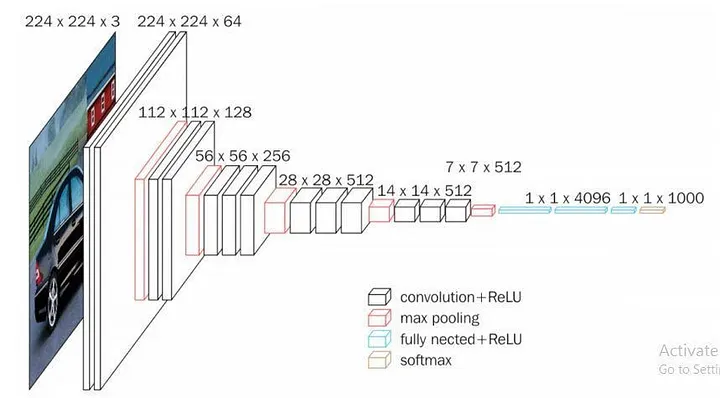

([Link](https://medium.com/@mygreatlearning/everything-you-need-to-know-about-vgg16-7315defb5918))

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_custom_vgg16(num_classes=15):
    # Pixels: 180x180, for each RGB Values
    input_shape=(180, 180, 3)

    inputs = keras.Input(shape=input_shape)      # Define input-layer
    x = layers.Resizing(224, 224)(inputs)        # The images are not 224x224. We use 180x180
    x = layers.Rescaling(1./255)(x)              # Rescaling RGB (reach from 0 - 255 divide by 255 to have a value within 0 - 1)


    # Meaning of: x = layers.Conv2D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
    # Dim. automatically defined to 224x224 from the previous layer
    # Filters: 64 Filters
    # Kernel-size:3x3 window area
    #   => Each Filter 3x3 Area multiplied by 3 values (RGB) => 27 Weights
    # Padding="same" => Keep 224x224x64. Otherwise it would be 222x222
    #                  (most left, right, top, bottom areas could not be calcuated by 3x3 area)
    # Activation = "relu": Rectified linear units e.g. f(x) = max(0,x)

    # Feature learning
    x = layers.Conv2D(filters=64, kernel_size=3, padding="same", activation="relu")(x)  # 224x224
    x = layers.Conv2D(filters=64, kernel_size=3, padding="same", activation="relu")(x)

    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)                              # 112x112 (Biggest value of 2x2 area. Strides 2 => Stepsize2 => Dim/2)
    x = layers.Conv2D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters=128, kernel_size=3, padding="same", activation="relu")(x)

    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)                               # 56x56
    x = layers.Conv2D(filters=256, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters=256, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters=256, kernel_size=3, padding="same", activation="relu")(x)

    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)                               # 28x28
    x = layers.Conv2D(filters=512, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters=512, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters=512, kernel_size=3, padding="same", activation="relu")(x)

    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)                               # 14x14
    x = layers.Conv2D(filters=512, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters=512, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters=512, kernel_size=3, padding="same", activation="relu")(x)

    # Classification
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)                                # 7x7
    x = layers.Flatten()(x)                                                                # 7x7 (area) x 512 Filter => 25088
    x = layers.Dense(4096, activation="relu")(x)                                           # 25088 => 4096
    x = layers.Dense(4096, activation="relu")(x)
    x = layers.Dense(4096, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)                           # Prediction layer => Probabilities

    return keras.Model(inputs, outputs, name="vgg16_custom")

In [ ]:
from tensorflow import keras

lr = 1e-3
epochs = 30
seed = 42

model = create_custom_vgg16()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr),
    loss= keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_not_augmented_split_categories_only",
    model=model,
    seed=seed,
    epochs=epochs,
)

out = train(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs
)

zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```
Found 4286 files belonging to 15 classes.
Found 534 files belonging to 15 classes.
Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.0878 - loss: 50.4636 - val_accuracy: 0.0861 - val_loss: 2.6741 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 107s 801ms/step - accuracy: 0.0881 - loss: 2.6769 - val_accuracy: 0.0861 - val_loss: 2.6731 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.0846 - loss: 2.6777 - val_accuracy: 0.0861 - val_loss: 2.6724 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 126s 947ms/step - accuracy: 0.0830 - loss: 2.6763 - val_accuracy: 0.0861 - val_loss: 2.6723 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.0799 - loss: 2.6763 - val_accuracy: 0.0861 - val_loss: 2.6721 - learning_rate: 0.0010
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 64s 474ms/step - accuracy: 0.0857 - loss: 2.6757 - val_accuracy: 0.0861 - val_loss: 2.6724 - learning_rate: 0.0010
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.0792 - loss: 2.6750 - val_accuracy: 0.0861 - val_loss: 2.6719 - learning_rate: 0.0010
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 86s 642ms/step - accuracy: 0.0831 - loss: 2.6750 - val_accuracy: 0.0861 - val_loss: 2.6718 - learning_rate: 0.0010
Epoch 9/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.0846 - loss: 2.6738 - val_accuracy: 0.0861 - val_loss: 2.6718 - learning_rate: 0.0010
Epoch 10/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 63s 467ms/step - accuracy: 0.0854 - loss: 2.6730 - val_accuracy: 0.0861 - val_loss: 2.6719 - learning_rate: 0.0010
Epoch 11/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.0808 - loss: 2.6737 - val_accuracy: 0.0861 - val_loss: 2.6714 - learning_rate: 0.0010
Epoch 12/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.0865 - loss: 2.6744 - val_accuracy: 0.0861 - val_loss: 2.6713 - learning_rate: 0.0010
Epoch 13/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 63s 467ms/step - accuracy: 0.0821 - loss: 2.6743 - val_accuracy: 0.0861 - val_loss: 2.6714 - learning_rate: 0.0010
Epoch 14/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 63s 467ms/step - accuracy: 0.0851 - loss: 2.6743 - val_accuracy: 0.0861 - val_loss: 2.6714 - learning_rate: 0.0010
Epoch 15/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.0839 - loss: 2.6725 - val_accuracy: 0.0861 - val_loss: 2.6712 - learning_rate: 0.0010
Epoch 16/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.0835 - loss: 2.6716 - val_accuracy: 0.0861 - val_loss: 2.6712 - learning_rate: 0.0010
Epoch 17/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.0856 - loss: 2.6724 - val_accuracy: 0.0861 - val_loss: 2.6712 - learning_rate: 0.0010
Epoch 18/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 63s 468ms/step - accuracy: 0.0864 - loss: 2.6744 - val_accuracy: 0.0861 - val_loss: 2.6714 - learning_rate: 0.0010
Epoch 19/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 130s 976ms/step - accuracy: 0.0857 - loss: 2.6714 - val_accuracy: 0.0861 - val_loss: 2.6711 - learning_rate: 0.0010
Epoch 20/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 120s 898ms/step - accuracy: 0.0834 - loss: 2.6717 - val_accuracy: 0.0861 - val_loss: 2.6711 - learning_rate: 0.0010
Epoch 21/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.0841 - loss: 2.6728
Epoch 21: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
134/134 ━━━━━━━━━━━━━━━━━━━━ 63s 468ms/step - accuracy: 0.0841 - loss: 2.6728 - val_accuracy: 0.0861 - val_loss: 2.6714 - learning_rate: 0.0010
Epoch 22/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 63s 467ms/step - accuracy: 0.0743 - loss: 2.6734 - val_accuracy: 0.0861 - val_loss: 2.6712 - learning_rate: 1.0000e-04
Epoch 23/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 97s 727ms/step - accuracy: 0.0757 - loss: 2.6724 - val_accuracy: 0.0861 - val_loss: 2.6711 - learning_rate: 1.0000e-04
Epoch 24/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 90s 676ms/step - accuracy: 0.0750 - loss: 2.6729 - val_accuracy: 0.0861 - val_loss: 2.6710 - learning_rate: 1.0000e-04
Epoch 25/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 106s 795ms/step - accuracy: 0.0738 - loss: 2.6726 - val_accuracy: 0.0861 - val_loss: 2.6710 - learning_rate: 1.0000e-04
Epoch 26/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 143s 805ms/step - accuracy: 0.0777 - loss: 2.6717 - val_accuracy: 0.0861 - val_loss: 2.6709 - learning_rate: 1.0000e-04
Epoch 27/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 104s 781ms/step - accuracy: 0.0860 - loss: 2.6719 - val_accuracy: 0.0955 - val_loss: 2.6709 - learning_rate: 1.0000e-04
Epoch 28/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 113s 843ms/step - accuracy: 0.0969 - loss: 2.6726 - val_accuracy: 0.0955 - val_loss: 2.6709 - learning_rate: 1.0000e-04
Epoch 29/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 103s 769ms/step - accuracy: 0.0976 - loss: 2.6719 - val_accuracy: 0.0955 - val_loss: 2.6708 - learning_rate: 1.0000e-04
Epoch 30/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 98s 733ms/step - accuracy: 0.0953 - loss: 2.6713 - val_accuracy: 0.0955 - val_loss: 2.6708 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.
Exported: export/vgg16_custom_bundle.zip
```

In [ ]:
model = import_model("https://drive.google.com/file/d/1j2nVBUvl-2qeMclPPO5WhApJouHitkJR/view?usp=sharing", "vgg16_custom_bundle")

In [ ]:
df = eval(model, "data/data_not_augmented_split_categories_only/val", batch_size=32, seed=42)
df

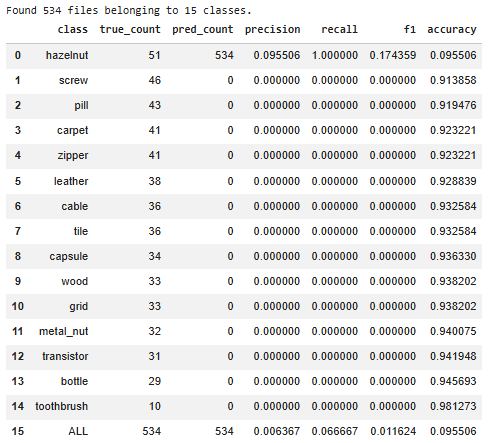

Der Trainingsverlauf zeigt wie vermutet, das dieses Modell viel zu komplex ist bzw. massiv überdimensioniert für dieses Problem/den Datensatz ist. Es tritt kein Lern-Effekt ein. Es wird nur die Haselnull vorhergesagt. Aufgrund desssen haben wir in dem nachfolgenden Versuch das Modell deutlich leichter gemacht.

### 5.2.2 Classify categories - Xception

Xception Modell aus dem Keras Guide [Image classification from scratch](https://keras.io/examples/vision/image_classification_from_scratch/)



In [ ]:
def make_xception(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = layers.Dense(units, activation=None)(x)
    return keras.Model(inputs, outputs, name="xception")

In [ ]:
from tensorflow import keras

lr = 1e-3
epochs = 30
seed = 42
batch_size = 32
image_size = (180, 180)


model = make_xception(input_shape=image_size + (3,), num_classes=15)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr),
    loss= keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_not_augmented_split_categories_only",
    model=model,
    batch_size=batch_size,
    seed=seed,
    epochs=epochs,
)

out = train(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs
)

zip_path = export_model(run)
print("Exported:", zip_path)

df = eval(out.model, "data/data_not_augmented_split_categories_only/test", batch_size=batch_size, seed=seed)
df


<details>
  <summary>Training-Log</summary>

```
Found 4286 files belonging to 15 classes.
Found 534 files belonging to 15 classes.
Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 67s 381ms/step - accuracy: 0.0938 - loss: 5.1559 - val_accuracy: 0.0618 - val_loss: 2.7081 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 233ms/step - accuracy: 0.0631 - loss: 2.7081 - val_accuracy: 0.0618 - val_loss: 2.7081 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 232ms/step - accuracy: 0.0534 - loss: 2.7081 - val_accuracy: 0.0618 - val_loss: 2.7081 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 231ms/step - accuracy: 0.0575 - loss: 2.7100 - val_accuracy: 0.0000e+00 - val_loss: 2.7081 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 232ms/step - accuracy: 0.0193 - loss: 2.7081 - val_accuracy: 0.0000e+00 - val_loss: 2.7081 - learning_rate: 0.0010
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.0155 - loss: 2.7081
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 232ms/step - accuracy: 0.0156 - loss: 2.7081 - val_accuracy: 0.0000e+00 - val_loss: 2.7081 - learning_rate: 0.0010
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 231ms/step - accuracy: 0.0221 - loss: 2.7081 - val_accuracy: 0.0000e+00 - val_loss: 2.7081 - learning_rate: 1.0000e-04
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 231ms/step - accuracy: 0.0168 - loss: 2.7081 - val_accuracy: 0.0000e+00 - val_loss: 2.7081 - learning_rate: 1.0000e-04
Epoch 9/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 231ms/step - accuracy: 0.0154 - loss: 2.7081 - val_accuracy: 0.0000e+00 - val_loss: 2.7081 - learning_rate: 1.0000e-04
Epoch 10/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 231ms/step - accuracy: 0.0268 - loss: 2.7081 - val_accuracy: 0.0000e+00 - val_loss: 2.7081 - learning_rate: 1.0000e-04
Epoch 11/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.0201 - loss: 2.7081
Epoch 11: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 231ms/step - accuracy: 0.0201 - loss: 2.7081 - val_accuracy: 0.0000e+00 - val_loss: 2.7081 - learning_rate: 1.0000e-04
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.
Exported: export/xception_bundle.zip
Found 534 files belonging to 15 classes.
```

In [ ]:
model = import_model("https://drive.google.com/file/d/1pw8pnxt7xGlnAAtVrx4hUlqg1IOaFy-h/view?usp=sharing", "xception_bundle")

In [ ]:
df = eval(model, "data/data_not_augmented_split_categories_only/val", batch_size=32, seed=42)
df

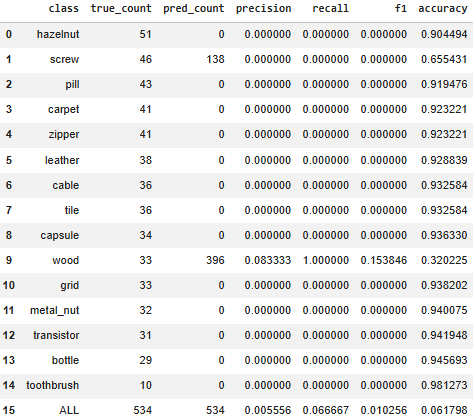

Der Trainingsverlauf zeigt auch hier, das dieses Modell zu komplex ist bzw. zu überdimensioniert für dieses Problem/den Datensatz ist. Auch hier tritt praktisch kein Lern-Effekt ein. An der gleichen `val_accuracy` und `val_loss` lässt sich vermuten, dass das Modell schon sehr schnell anfängt nur wenige Klassen vorherzusagen. Dies bestätigt die Ergebnistabelle. Es werden nur 2 Klassen vorhergesagt. Im nächsten Versuch haben wir daher eine Architektur gewählt, welche Minial ist.

### 5.2.3 Classifiy categories - Custom simple cnn

Modellaufbau:

Die Modellarchitektur ist stark an das VGG16 angeleht, jedoch absolut minimal gehalten.Es gibt nur 3 Convolutional-MaxPooling-Layers, welche als Backbone dienen. Der Classification-Head besteht aus einem einzelnen Dense Layer mit Rectified Linear Aktivierungsfunktion. Diesen haben wir später um einen Dropout erwetiert, da er sich sehr wirksam gegen Overfitting erwiesen hat. Den Output-Layer bildet die Softmax-Funktion.



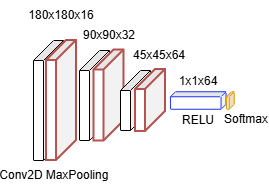

In [ ]:
def make_simple_cnn_category_only(input_shape=(180, 180, 3), num_classes=15):
    inputs = keras.Input(shape=input_shape)

    x = layers.Rescaling(1.0/255)(inputs)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="simple_cnn_category_only")

In [ ]:
import keras
from keras import layers

lr = 1e-3
epochs = 30
seed = 43

model = make_simple_cnn_category_only()
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_not_augmented_split_categories_only",
    model=model,
    seed=seed,
    epochs=epochs,
)

out = train(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs
)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Trainings-Log</summary>

```
Found 4286 files belonging to 15 classes.
Found 534 files belonging to 15 classes.
Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.5900 - loss: 1.2751 - val_accuracy: 0.9401 - val_loss: 0.1247 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9605 - loss: 0.1111 - val_accuracy: 1.0000 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9844 - loss: 0.0480 - val_accuracy: 0.9981 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9844 - loss: 0.0452 - val_accuracy: 1.0000 - val_loss: 5.7048e-04 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9944 - loss: 0.0213 - val_accuracy: 0.9981 - val_loss: 0.0286 - learning_rate: 0.0010
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9931 - loss: 0.0228 - val_accuracy: 1.0000 - val_loss: 3.2420e-05 - learning_rate: 0.0010
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9920 - loss: 0.0230 - val_accuracy: 0.9981 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9904 - loss: 0.0283 - val_accuracy: 1.0000 - val_loss: 2.5365e-04 - learning_rate: 0.0010
Epoch 9/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9957 - loss: 0.0154 - val_accuracy: 0.9700 - val_loss: 0.0540 - learning_rate: 0.0010
Epoch 10/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9826 - loss: 0.0485 - val_accuracy: 1.0000 - val_loss: 8.4331e-05 - learning_rate: 0.0010
Epoch 11/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9959 - loss: 0.0121
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9959 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 3.9580e-04 - learning_rate: 0.0010
Epoch 12/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9918 - loss: 0.0185 - val_accuracy: 1.0000 - val_loss: 8.0507e-04 - learning_rate: 1.0000e-04
Epoch 13/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9978 - loss: 0.0098 - val_accuracy: 1.0000 - val_loss: 2.1985e-04 - learning_rate: 1.0000e-04
Epoch 14/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9979 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 8.2514e-05 - learning_rate: 1.0000e-04
Epoch 15/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9955 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 3.3275e-04 - learning_rate: 1.0000e-04
Epoch 16/30
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9982 - loss: 0.0075
Epoch 16: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9982 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 3.2507e-04 - learning_rate: 1.0000e-04
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6.
Exported: export/simple_cnn_category_only_bundle.zip
```



In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1B94yhHx2SJVVcEqCEdUBrJwt0q4Mn0Rf/view?usp=sharing",
    "simple_cnn_category_only_bundle")

In [ ]:
df = eval(model, "data/data_not_augmented_split_categories_only/val", batch_size=32, seed=42)
df

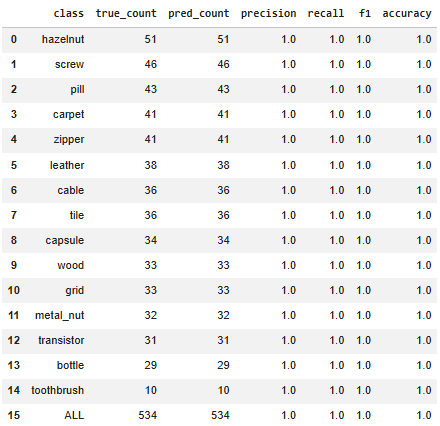

Wir sind davon ausgegangen, das die Kategorieaufgabe recht schnell gelernt werden kann, da an sehr einfachen Eigenschaften (z.B. die Hintergrundfarbe) gelernt werden kann.

Das Ergebnis war dennoch unerwartet.
Der Trainigsverlauf zeigte, dass das Modell die Kategorien sehr schnell lernt ohne dabei ein Overfitt zu verursachen. Das Validationergebnis zeigt, das die Klassifikation der Kategorien perfekt ist.


Aufgrund dessen bearbeiten wir für die Kategorieklassifikation dieses Modell nicht weiter und prüfen es gegen die Evaluationswerte.




In [ ]:
df = eval(model, "data/data_not_augmented_split_categories_only/test", batch_size=32, seed=42)
df

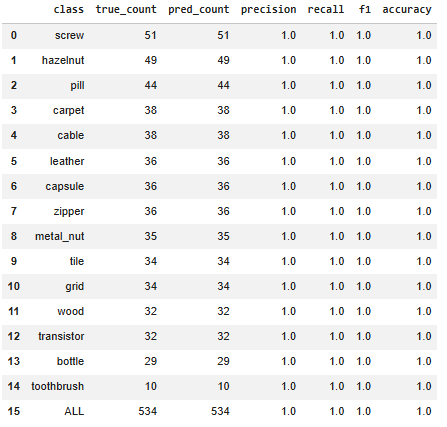

Die Evaluationswerte bestätigen die Vermutung.

### 5.2.4 Classify (categories x io/nio)

Da die Klassifikation der Kategorien so gut funktionert, wenden wir das Modell direkt auf Gesamtproblem an, indem wir jede Kategorie in IO und NIO klassifizieren. Dadruch ergibt sich ein 30er Klassifikationsproblem.

In [ ]:
def make_simple_cnn_category_and_io_nio(input_shape=(180, 180, 3), num_classes=30):
    inputs = keras.Input(shape=input_shape)

    x = layers.Rescaling(1.0/255)(inputs)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="simple_cnn_category_and_io_nio")

In [ ]:
import keras
from keras import layers

lr = 1e-3
epochs = 30
seed = 43

model = make_simple_cnn_category_and_io_nio()
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_not_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
)

out = train(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs
)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Trainings-Log</summary>

```
Found 4286 files belonging to 30 classes.
Found 534 files belonging to 30 classes.
Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.3950 - loss: 2.2650 - val_accuracy: 0.6891 - val_loss: 0.7345 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6798 - loss: 0.9147 - val_accuracy: 0.7566 - val_loss: 0.5647 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7111 - loss: 0.7462 - val_accuracy: 0.7790 - val_loss: 0.5417 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7537 - loss: 0.6156 - val_accuracy: 0.7116 - val_loss: 0.6911 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7372 - loss: 0.6111 - val_accuracy: 0.7734 - val_loss: 0.5281 - learning_rate: 0.0010
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7576 - loss: 0.5678 - val_accuracy: 0.7753 - val_loss: 0.4908 - learning_rate: 0.0010
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7756 - loss: 0.5296 - val_accuracy: 0.7697 - val_loss: 0.4983 - learning_rate: 0.0010
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7760 - loss: 0.5221 - val_accuracy: 0.7790 - val_loss: 0.4855 - learning_rate: 0.0010
Epoch 9/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7859 - loss: 0.4867 - val_accuracy: 0.7828 - val_loss: 0.4899 - learning_rate: 0.0010
Epoch 10/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7871 - loss: 0.4757 - val_accuracy: 0.7828 - val_loss: 0.4875 - learning_rate: 0.0010
Epoch 11/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8096 - loss: 0.4417 - val_accuracy: 0.7772 - val_loss: 0.4867 - learning_rate: 0.0010
Epoch 12/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8001 - loss: 0.4502 - val_accuracy: 0.7790 - val_loss: 0.5389 - learning_rate: 0.0010
Epoch 13/30
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8101 - loss: 0.4472
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8101 - loss: 0.4472 - val_accuracy: 0.7790 - val_loss: 0.4872 - learning_rate: 0.0010
Epoch 14/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8202 - loss: 0.4021 - val_accuracy: 0.7903 - val_loss: 0.4896 - learning_rate: 1.0000e-04
Epoch 15/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8399 - loss: 0.3614 - val_accuracy: 0.7903 - val_loss: 0.4985 - learning_rate: 1.0000e-04
Epoch 16/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8363 - loss: 0.3520 - val_accuracy: 0.7903 - val_loss: 0.5050 - learning_rate: 1.0000e-04
Epoch 17/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8525 - loss: 0.3320 - val_accuracy: 0.7921 - val_loss: 0.5167 - learning_rate: 1.0000e-04
Epoch 18/30
132/134 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8419 - loss: 0.3378
Epoch 18: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8419 - loss: 0.3379 - val_accuracy: 0.7903 - val_loss: 0.5116 - learning_rate: 1.0000e-04
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 8.
Exported: export/simple_cnn_category_and_io_nio_bundle.zip
```



In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1kRtMHQmO4SZjJ9sIe_Ar_cocY0M6N1aH/view?usp=sharing",
    "simple_cnn_category_and_io_nio")

In [ ]:
df = eval(model, "data/data_not_augmented_split/val", batch_size=32, seed=42)
df

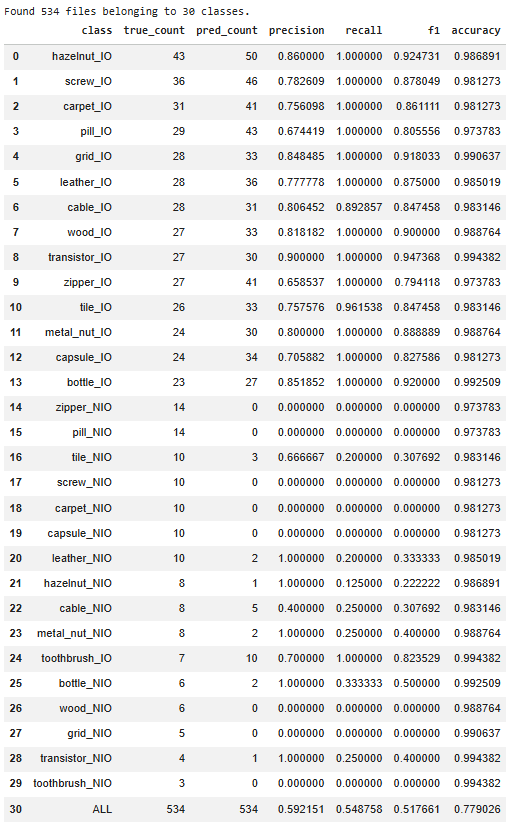

Das Modell hat sich als verwenbar erwiesen und scheint zunächst gute Ergebnisse zu liefern.
Jedoch **Voricht** ⚠️.
Die **Accuracy täuscht**, aufgrund der starken Class Imbalance zwischen IO und NIO.

In der Tabelle lässt sich dies sehr gut an den PredCounts, Precision, Recall und vorallem dem F1 Scores der NIO Klassen ablesen.
Im folgenden nutzen wir daher den **F1-Score** als Vergleichsmetrik, weil er die Precision und den Recall zusammenfasst und damit bei der Class Imbalance aussagekräftiger ist als (unbalanced) Accuracy.

Insgesamt gibt es eingie Maßnahmen die wir treffen können um dies zu reduzieren. So kann z.B. Downsampling eingsetzt werden. D.h. man verwendet nicht alle Bilder welche in Ordnung sind um das Klassenungleichgewicht abzuschwächen. In unseren Fall haben wir uns dagegen entschieden, da der Datensatz bereits sehr wenige Daten beinhaltet.
Im Folgenden verfolgen wir daher zwei andere Maßnahmen um die Imbalance anzupassen.

Einmal über die Anpassung Loss-Funktion und einmal in dem wir die NIO Bilder augmentieren. Wir halten uns dabei relativ nah an dem [TensorFlow Guide](https://www.tensorflow.org/tutorials/structured_data/imbalanced_data#look_at_the_data_distribution).

Im ersten Fall müssen wir die Daten nicht verändern. Stattdessen trimmen wir das Modell dazu auf NIO vorherzusagen, in dem wir eine Fehlklassifikation eines NIO Elements deutlich stärker - abhängig von der Anzahl wie oft das Element im Verhältnis zu IO vorkommt - gewichten. In der zweiten Maßnahme erhöhen wir den Anteil an NIO Bilder, indem wir diese durch Data Augemntation (aus der Data Preperation Phase) upsamplen.

### 5.2.5 Classify (categories x io/nio) with class weights

WIr verwenden die `compute_class_weights` und übergeben sie der Training-Pipeline. Diese werden dem kompilierten Modell beim `fit` übergeben.

Die Klassengewichte ermitteln wir anhand des Trainingsdatensates unter der Verwendung von SkLearns [compute_class_weights](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html). Hierbei wird das Klassenhäufigkeitsverhältnis miteinberechnet. Gibt es doppelt so viele IO Samples einer Kategorie gegebenüber der NIO Samples. So werden die NIO Samples gegenüber den IO Samples doppelt so stark gewichtet.


In [ ]:
def make_simple_cnn_category_and_io_nio_class_weights(input_shape=(180, 180, 3), num_classes=30):
    inputs = keras.Input(shape=input_shape)

    x = layers.Rescaling(1.0/255)(inputs)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="simple_cnn_category_and_io_nio_class_weights")

In [ ]:
import numpy as np
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight

def compute_class_weights(train_dir: str, seed: int, image_size=(180, 180), batch_size=32):
    ds = keras.utils.image_dataset_from_directory(
        train_dir,
        seed=seed,
        image_size=image_size,
        batch_size=batch_size,
        shuffle=False,
    )
    y = np.concatenate([yy.numpy() for _, yy in ds], axis=0).astype(int)
    classes = np.unique(y)
    w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(ww) for c, ww in zip(classes, w)}


In [ ]:
import keras
from keras import layers

lr = 1e-3
epochs = 30
seed = 43

model = make_simple_cnn_category_and_io_nio_class_weights()
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

class_weight = compute_class_weights(
    "data/data_not_augmented_split/train",
    seed=seed
)

inp = TrainInput(
    data_dir="data/data_not_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    class_weight=class_weight
)

out = train(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs
)
zip_path = export_model(run)
print("Exported:", zip_path)


<details>
  <summary>Training-Log</summary>

```
Found 4286 files belonging to 30 classes.
Found 4286 files belonging to 30 classes.
Found 534 files belonging to 30 classes.
Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.2406 - loss: 2.5364 - val_accuracy: 0.4551 - val_loss: 1.0040 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4434 - loss: 1.2131 - val_accuracy: 0.5225 - val_loss: 0.8444 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5000 - loss: 0.9958 - val_accuracy: 0.4775 - val_loss: 0.9189 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5537 - loss: 0.8521 - val_accuracy: 0.6311 - val_loss: 0.6447 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5470 - loss: 0.7682 - val_accuracy: 0.5431 - val_loss: 0.7072 - learning_rate: 0.0010
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6032 - loss: 0.7376 - val_accuracy: 0.5749 - val_loss: 0.6195 - learning_rate: 0.0010
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5989 - loss: 0.7012 - val_accuracy: 0.5693 - val_loss: 0.6518 - learning_rate: 0.0010
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6274 - loss: 0.6684 - val_accuracy: 0.6404 - val_loss: 0.5722 - learning_rate: 0.0010
Epoch 9/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6527 - loss: 0.6157 - val_accuracy: 0.5112 - val_loss: 0.9783 - learning_rate: 0.0010
Epoch 10/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6413 - loss: 0.6595 - val_accuracy: 0.7135 - val_loss: 0.5677 - learning_rate: 0.0010
Epoch 11/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6884 - loss: 0.5608 - val_accuracy: 0.5599 - val_loss: 0.6622 - learning_rate: 0.0010
Epoch 12/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6640 - loss: 0.5833 - val_accuracy: 0.7060 - val_loss: 0.5395 - learning_rate: 0.0010
Epoch 13/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7261 - loss: 0.5493 - val_accuracy: 0.7079 - val_loss: 0.5478 - learning_rate: 0.0010
Epoch 14/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7225 - loss: 0.5269 - val_accuracy: 0.6442 - val_loss: 0.6108 - learning_rate: 0.0010
Epoch 15/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7120 - loss: 0.5094 - val_accuracy: 0.6985 - val_loss: 0.5658 - learning_rate: 0.0010
Epoch 16/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7485 - loss: 0.4652 - val_accuracy: 0.6311 - val_loss: 0.6289 - learning_rate: 0.0010
Epoch 17/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7327 - loss: 0.5217
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7328 - loss: 0.5215 - val_accuracy: 0.6573 - val_loss: 0.5470 - learning_rate: 0.0010
Epoch 18/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7510 - loss: 0.4060 - val_accuracy: 0.7846 - val_loss: 0.4687 - learning_rate: 1.0000e-04
Epoch 19/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8143 - loss: 0.3651 - val_accuracy: 0.7790 - val_loss: 0.4786 - learning_rate: 1.0000e-04
Epoch 20/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8128 - loss: 0.3500 - val_accuracy: 0.7903 - val_loss: 0.4784 - learning_rate: 1.0000e-04
Epoch 21/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8284 - loss: 0.3485 - val_accuracy: 0.7884 - val_loss: 0.4738 - learning_rate: 1.0000e-04
Epoch 22/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8153 - loss: 0.3440 - val_accuracy: 0.8109 - val_loss: 0.4728 - learning_rate: 1.0000e-04
Epoch 23/30
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8230 - loss: 0.3461
Epoch 23: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8231 - loss: 0.3461 - val_accuracy: 0.7921 - val_loss: 0.4818 - learning_rate: 1.0000e-04
Epoch 24/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8226 - loss: 0.3351 - val_accuracy: 0.8109 - val_loss: 0.4752 - learning_rate: 1.0000e-05
Epoch 25/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8375 - loss: 0.3466 - val_accuracy: 0.8165 - val_loss: 0.4741 - learning_rate: 1.0000e-05
Epoch 26/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8427 - loss: 0.3128 - val_accuracy: 0.8109 - val_loss: 0.4741 - learning_rate: 1.0000e-05
Epoch 27/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8500 - loss: 0.3258 - val_accuracy: 0.8127 - val_loss: 0.4714 - learning_rate: 1.0000e-05
Epoch 28/30
131/134 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8283 - loss: 0.3219
Epoch 28: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8286 - loss: 0.3221 - val_accuracy: 0.8202 - val_loss: 0.4724 - learning_rate: 1.0000e-05
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 18.
Exported: export/simple_cnn_category_and_io_nio_class_weights_bundle.zip
```



In [ ]:
model = import_model(
    "https://drive.google.com/file/d/19i8kQ6GK1iREX-WVHFd8FbaFiZQRlhTS/view?usp=sharing",
    "simple_cnn_category_and_io_nio_class_weights_bundle")

In [ ]:
df = eval(model, "data/data_not_augmented_split/val", batch_size=32, seed=42)
df

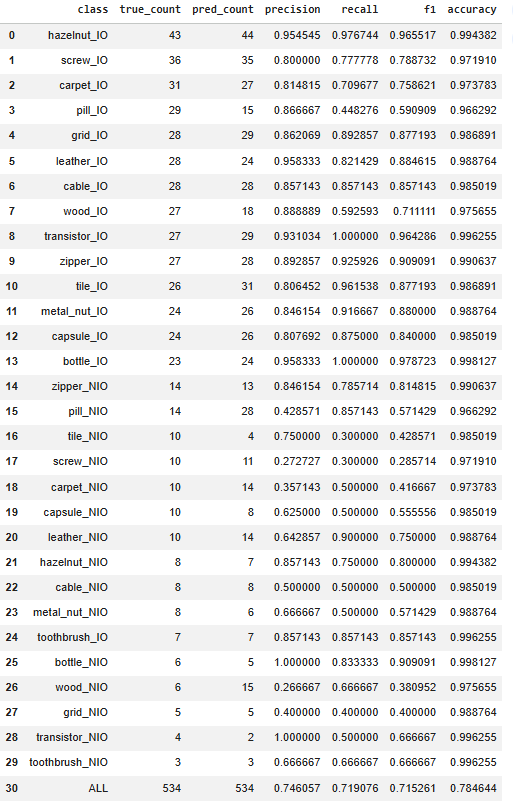

Man sieht, dass durch diese Änderung das Modell die NIOs nicht mehr so stark vernachlässigt. Der F1 Score von 0.51 auf 0.71 stark angestiegen ist.
Die Pred-Counts bestätigen dies ebenfalls.

### 5.2.6 Classify (categories x io/nio) with augmentation

Erklären Idee wir augmentieren die NIO bilder um imbalance anzupassen

In [ ]:
def make_simple_cnn_with_augmentation(input_shape=(180, 180, 3), num_classes=30):
    inputs = keras.Input(shape=input_shape)

    x = layers.Rescaling(1.0/255)(inputs)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="simple_cnn_with_augmentation")

In [ ]:
import keras
from keras import layers

lr = 1e-3
epochs = 30
seed = 43

model = make_simple_cnn_with_augmentation()
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
)

out = train(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs
)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>



```
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.2368 - loss: 2.4835 - val_accuracy: 0.5201 - val_loss: 0.9509 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5009 - loss: 1.1334 - val_accuracy: 0.5481 - val_loss: 0.7068 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5713 - loss: 0.8561 - val_accuracy: 0.6078 - val_loss: 0.6408 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.5965 - loss: 0.7700 - val_accuracy: 0.6212 - val_loss: 0.6127 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6139 - loss: 0.7457 - val_accuracy: 0.6151 - val_loss: 0.6092 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6392 - loss: 0.6940 - val_accuracy: 0.6809 - val_loss: 0.6317 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6597 - loss: 0.6378 - val_accuracy: 0.6675 - val_loss: 0.6021 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6549 - loss: 0.6499 - val_accuracy: 0.6443 - val_loss: 0.6122 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6815 - loss: 0.5902 - val_accuracy: 0.6565 - val_loss: 0.6112 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7040 - loss: 0.5925 - val_accuracy: 0.6894 - val_loss: 0.6334 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7117 - loss: 0.5648 - val_accuracy: 0.6663 - val_loss: 0.5917 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6814 - loss: 0.6220 - val_accuracy: 0.6991 - val_loss: 0.6108 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7101 - loss: 0.5530 - val_accuracy: 0.7138 - val_loss: 0.6118 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7334 - loss: 0.5008 - val_accuracy: 0.7223 - val_loss: 0.5889 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7536 - loss: 0.4848 - val_accuracy: 0.7089 - val_loss: 0.6485 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7517 - loss: 0.4830 - val_accuracy: 0.7004 - val_loss: 0.6553 - learning_rate: 0.0010
Epoch 17/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7578 - loss: 0.4882 - val_accuracy: 0.7199 - val_loss: 0.7004 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7590 - loss: 0.4825 - val_accuracy: 0.7393 - val_loss: 0.6473 - learning_rate: 0.0010
Epoch 19/30
203/206 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7739 - loss: 0.4502
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7738 - loss: 0.4504 - val_accuracy: 0.7320 - val_loss: 0.6563 - learning_rate: 0.0010
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7826 - loss: 0.4249 - val_accuracy: 0.7661 - val_loss: 0.6041 - learning_rate: 1.0000e-04
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7919 - loss: 0.4026 - val_accuracy: 0.7649 - val_loss: 0.6299 - learning_rate: 1.0000e-04
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8001 - loss: 0.4032 - val_accuracy: 0.7613 - val_loss: 0.6290 - learning_rate: 1.0000e-04
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8023 - loss: 0.3886 - val_accuracy: 0.7625 - val_loss: 0.6385 - learning_rate: 1.0000e-04
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8035 - loss: 0.3855
Epoch 24: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8036 - loss: 0.3855 - val_accuracy: 0.7637 - val_loss: 0.6453 - learning_rate: 1.0000e-04
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 14.
Exported: export/simple_cnn_with_augmentation_bundle.zip
```



In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1Kzyk1hdOxrIjUUonZhp9796dC_kkWxs-/view?usp=sharing",
    "simple_cnn_category_and_io_nio_class_weights_bundle")

In [ ]:
df = eval(model, "data/data_augmented_split/val", batch_size=32, seed=43)
df

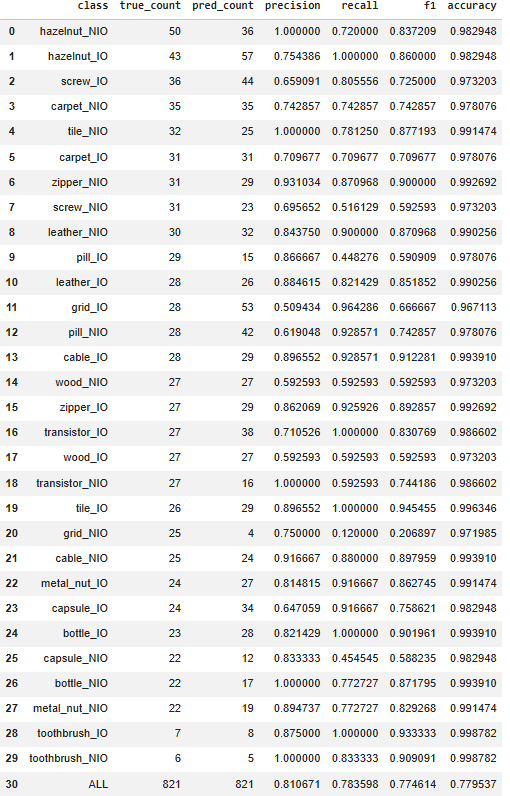

Man sieht auch hier, dass durch diese Änderung das Modell die NIOs nicht mehr so stark vernachlässigt. Der F1 Score ist hier von 0.51 auf 0.77 stark angestiegen. Auch hier bestätigen die Pred-Counts dies, wobei bei diesen beachtet werden muss, das hier nun auch der true_count durch die Augmentierung höher ist.


### 5.2.7 Compare class weights vs augmentation

Werden die beiden Validierungstabellen betrachtet, so sehen wir das beider Augmentierung das Modell insgesamt etwas besser abgeschnitten hat. Knapp 6%. Dieser Abstand bleibt auch umgefähr wenn wir verschiedene Seeds verwenden. Wir haben uns deshalb dazu entschieden, mit der Augmentierung weiter zu arbeiten.

Beim ausführen mit verschiedenen Seeds haben wir bereits bemerkt, das dieses Modell - bedingt durch die geringe Anzahl an originalen NIO Bildern - nicht sehr stabil ist.

### 5.2.8 Tuning simple cnn

Ursprünglich wollten wir das Modell mittels eines Keras Autotuners trainiern. Wir haben uns dann jedoch dagegen entschieden, da wir zu viele Parameter ausprobieren wollten und eine sehr hohe Anzahl an Trainings gebraucht hätten. Daher haben wir eine Basiskonfiguration ausgewählt (so wie bisher) und dann immer einen Parameter angepasst. Wir erhoffen uns davon, effizient herauszufinden, welche Parameter einen Einfluss haben und in welche Richtung wir diese anpassen müssen.

Um die Trainingszeit klein zu halten, haben wir zudem die Anzahl an Epochen auf 15 beschränkt.

In [ ]:
from tensorflow import keras
from keras import layers
import pandas as pd

def make_cnn_from_cfg(cfg, num_classes=30):
    inputs = keras.Input(shape=(180,180,3))
    x = layers.Rescaling(1./255)(inputs)

    filters_map = {
        "small":  [16, 32, 64, 128],
        "medium": [24, 48, 96, 192],
        "large":  [32, 64, 128, 256],
    }
    filters_per_block = filters_map[cfg["filters"]]

    for f in filters_per_block[:cfg["blocks"]]:
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x)

    if cfg["use_gap"]:
        x = layers.GlobalAveragePooling2D()(x)
    else:
        x = layers.Flatten()(x)

    for _ in range(cfg["dense_layers"]):
        x = layers.Dense(cfg["dense_units"], activation="relu")(x)

    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=cfg["name"])
    model.compile(
        optimizer=keras.optimizers.Adam(cfg["lr"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [ ]:
BASE = dict(
    blocks=3,
    filters="medium",
    use_gap=False,
    dense_layers=1,
    dense_units=64,
    lr=3e-4
)

runs = [
    dict(name="baseline", **BASE),

    dict(name="blocks_2", **{**BASE, "blocks": 2}),
    dict(name="blocks_4", **{**BASE, "blocks": 4}),

    dict(name="filters_small", **{**BASE, "filters": "small"}),
    dict(name="filters_large", **{**BASE, "filters": "large"}),

    dict(name="use_gap", **{**BASE, "use_gap": True}),
    dict(name="dense_layers_2", **{**BASE, "dense_layers": 2}),
    dict(name="dense_128", **{**BASE, "dense_units": 128}),
]


In [ ]:
import pandas as pd
import keras

data_dir = "data/data_augmented_split"
seed = 44
epochs = 20

results = []

for cfg in runs:
    print("\n==============================")
    print("RUN:", cfg["name"])
    print(cfg)
    print("==============================")

    model = make_cnn_from_cfg(cfg)

    model.compile(
        optimizer=keras.optimizers.Adam(cfg["lr"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    inp = TrainInput(
        data_dir=data_dir,
        model=model,
        seed=seed,
        epochs=epochs,
        batch_size=32,
    )

    out = train(inp)

    df_val = eval(out.model, f"{data_dir}/val", batch_size=32, seed=seed)
    val_acc = float(df_val.loc[df_val["class"] == "ALL", "accuracy"].iloc[0])
    val_f1 = float(df_val.loc[df_val["class"] == "ALL", "f1"].iloc[0])

    results.append({
        "name": cfg["name"],
        "blocks": cfg["blocks"],
        "filters": cfg["filters"],
        "use_gap": cfg["use_gap"],
        "dense_layers": cfg["dense_layers"],
        "dense_units": cfg["dense_units"],
        "lr": cfg["lr"],
        "accuracy": val_acc,
        "f1": val_f1
    })

res_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
res_df


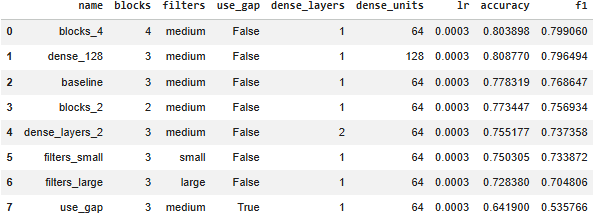

<details>
  <summary>Tuning-Log</summary>

```

==============================
RUN: baseline
{'name': 'baseline', 'blocks': 3, 'filters': 'medium', 'use_gap': False, 'dense_layers': 1, 'dense_units': 64, 'lr': 0.0003}
==============================
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.2239 - loss: 2.5540 - val_accuracy: 0.5505 - val_loss: 1.0025 - learning_rate: 3.0000e-04
Epoch 2/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.4935 - loss: 1.2336 - val_accuracy: 0.6127 - val_loss: 0.7190 - learning_rate: 3.0000e-04
Epoch 3/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5655 - loss: 0.9606 - val_accuracy: 0.6236 - val_loss: 0.6253 - learning_rate: 3.0000e-04
Epoch 4/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5885 - loss: 0.8777 - val_accuracy: 0.7040 - val_loss: 0.6060 - learning_rate: 3.0000e-04
Epoch 5/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6323 - loss: 0.7463 - val_accuracy: 0.6967 - val_loss: 0.5667 - learning_rate: 3.0000e-04
Epoch 6/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6651 - loss: 0.6835 - val_accuracy: 0.7052 - val_loss: 0.5466 - learning_rate: 3.0000e-04
Epoch 7/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6784 - loss: 0.6520 - val_accuracy: 0.7211 - val_loss: 0.5581 - learning_rate: 3.0000e-04
Epoch 8/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6982 - loss: 0.6158 - val_accuracy: 0.7113 - val_loss: 0.5286 - learning_rate: 3.0000e-04
Epoch 9/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.7153 - loss: 0.5978 - val_accuracy: 0.7284 - val_loss: 0.5357 - learning_rate: 3.0000e-04
Epoch 10/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.7247 - loss: 0.5622 - val_accuracy: 0.6797 - val_loss: 0.6870 - learning_rate: 3.0000e-04
Epoch 11/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.7295 - loss: 0.5456 - val_accuracy: 0.7515 - val_loss: 0.4827 - learning_rate: 3.0000e-04
Epoch 12/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7559 - loss: 0.5146 - val_accuracy: 0.7576 - val_loss: 0.5102 - learning_rate: 3.0000e-04
Epoch 13/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7712 - loss: 0.4756 - val_accuracy: 0.7783 - val_loss: 0.4800 - learning_rate: 3.0000e-04
Epoch 14/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.7874 - loss: 0.4641 - val_accuracy: 0.7661 - val_loss: 0.5029 - learning_rate: 3.0000e-04
Epoch 15/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7916 - loss: 0.4500 - val_accuracy: 0.7722 - val_loss: 0.5435 - learning_rate: 3.0000e-04
Epoch 16/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7986 - loss: 0.4315 - val_accuracy: 0.7540 - val_loss: 0.5568 - learning_rate: 3.0000e-04
Epoch 17/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8051 - loss: 0.4105 - val_accuracy: 0.7345 - val_loss: 0.6102 - learning_rate: 3.0000e-04
Epoch 18/20
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7856 - loss: 0.4324
Epoch 18: ReduceLROnPlateau reducing learning rate to 3.000000142492354e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7858 - loss: 0.4322 - val_accuracy: 0.7454 - val_loss: 0.5060 - learning_rate: 3.0000e-04
Epoch 19/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8294 - loss: 0.3690 - val_accuracy: 0.7978 - val_loss: 0.5334 - learning_rate: 3.0000e-05
Epoch 20/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8432 - loss: 0.3427 - val_accuracy: 0.8112 - val_loss: 0.4973 - learning_rate: 3.0000e-05
Restoring model weights from the end of the best epoch: 13.
Found 821 files belonging to 30 classes.

==============================
RUN: blocks_2
{'name': 'blocks_2', 'blocks': 2, 'filters': 'medium', 'use_gap': False, 'dense_layers': 1, 'dense_units': 64, 'lr': 0.0003}
==============================
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.1539 - loss: 2.9710 - val_accuracy: 0.4251 - val_loss: 1.4373 - learning_rate: 3.0000e-04
Epoch 2/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.3777 - loss: 1.7197 - val_accuracy: 0.5700 - val_loss: 0.9623 - learning_rate: 3.0000e-04
Epoch 3/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4821 - loss: 1.2746 - val_accuracy: 0.5932 - val_loss: 0.7961 - learning_rate: 3.0000e-04
Epoch 4/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5410 - loss: 1.0641 - val_accuracy: 0.6407 - val_loss: 0.6317 - learning_rate: 3.0000e-04
Epoch 5/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5853 - loss: 0.9347 - val_accuracy: 0.6590 - val_loss: 0.6117 - learning_rate: 3.0000e-04
Epoch 6/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6048 - loss: 0.8566 - val_accuracy: 0.6346 - val_loss: 0.5957 - learning_rate: 3.0000e-04
Epoch 7/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6242 - loss: 0.7822 - val_accuracy: 0.6407 - val_loss: 0.5882 - learning_rate: 3.0000e-04
Epoch 8/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6499 - loss: 0.7498 - val_accuracy: 0.6663 - val_loss: 0.6002 - learning_rate: 3.0000e-04
Epoch 9/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6403 - loss: 0.7433 - val_accuracy: 0.6760 - val_loss: 0.5797 - learning_rate: 3.0000e-04
Epoch 10/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6574 - loss: 0.6955 - val_accuracy: 0.6918 - val_loss: 0.5528 - learning_rate: 3.0000e-04
Epoch 11/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6784 - loss: 0.6713 - val_accuracy: 0.6760 - val_loss: 0.5694 - learning_rate: 3.0000e-04
Epoch 12/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6854 - loss: 0.6677 - val_accuracy: 0.7040 - val_loss: 0.5489 - learning_rate: 3.0000e-04
Epoch 13/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6974 - loss: 0.6118 - val_accuracy: 0.6797 - val_loss: 0.5735 - learning_rate: 3.0000e-04
Epoch 14/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6729 - loss: 0.6763 - val_accuracy: 0.7052 - val_loss: 0.5643 - learning_rate: 3.0000e-04
Epoch 15/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7060 - loss: 0.5935 - val_accuracy: 0.6833 - val_loss: 0.6029 - learning_rate: 3.0000e-04
Epoch 16/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7115 - loss: 0.5984 - val_accuracy: 0.7101 - val_loss: 0.6014 - learning_rate: 3.0000e-04
Epoch 17/20
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7261 - loss: 0.5565
Epoch 17: ReduceLROnPlateau reducing learning rate to 3.000000142492354e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7262 - loss: 0.5563 - val_accuracy: 0.7259 - val_loss: 0.6209 - learning_rate: 3.0000e-04
Epoch 18/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7654 - loss: 0.5131 - val_accuracy: 0.7467 - val_loss: 0.5442 - learning_rate: 3.0000e-05
Epoch 19/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7737 - loss: 0.4821 - val_accuracy: 0.7613 - val_loss: 0.5533 - learning_rate: 3.0000e-05
Epoch 20/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7806 - loss: 0.4806 - val_accuracy: 0.7734 - val_loss: 0.5435 - learning_rate: 3.0000e-05
Restoring model weights from the end of the best epoch: 20.
Found 821 files belonging to 30 classes.

==============================
RUN: blocks_4
{'name': 'blocks_4', 'blocks': 4, 'filters': 'medium', 'use_gap': False, 'dense_layers': 1, 'dense_units': 64, 'lr': 0.0003}
==============================
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.2129 - loss: 2.6367 - val_accuracy: 0.5798 - val_loss: 0.9962 - learning_rate: 3.0000e-04
Epoch 2/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5015 - loss: 1.2502 - val_accuracy: 0.6590 - val_loss: 0.7107 - learning_rate: 3.0000e-04
Epoch 3/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.5626 - loss: 1.0006 - val_accuracy: 0.6029 - val_loss: 0.7936 - learning_rate: 3.0000e-04
Epoch 4/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5834 - loss: 0.9395 - val_accuracy: 0.6626 - val_loss: 0.5986 - learning_rate: 3.0000e-04
Epoch 5/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6208 - loss: 0.7823 - val_accuracy: 0.6699 - val_loss: 0.6141 - learning_rate: 3.0000e-04
Epoch 6/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6589 - loss: 0.6997 - val_accuracy: 0.6724 - val_loss: 0.5806 - learning_rate: 3.0000e-04
Epoch 7/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6822 - loss: 0.6536 - val_accuracy: 0.7333 - val_loss: 0.4946 - learning_rate: 3.0000e-04
Epoch 8/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6926 - loss: 0.6217 - val_accuracy: 0.7320 - val_loss: 0.5320 - learning_rate: 3.0000e-04
Epoch 9/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6923 - loss: 0.6166 - val_accuracy: 0.7564 - val_loss: 0.4772 - learning_rate: 3.0000e-04
Epoch 10/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.7263 - loss: 0.5418 - val_accuracy: 0.7588 - val_loss: 0.4802 - learning_rate: 3.0000e-04
Epoch 11/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7393 - loss: 0.5200 - val_accuracy: 0.7588 - val_loss: 0.4811 - learning_rate: 3.0000e-04
Epoch 12/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7432 - loss: 0.5181 - val_accuracy: 0.7808 - val_loss: 0.4429 - learning_rate: 3.0000e-04
Epoch 13/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7559 - loss: 0.4901 - val_accuracy: 0.7296 - val_loss: 0.4743 - learning_rate: 3.0000e-04
Epoch 14/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7560 - loss: 0.4874 - val_accuracy: 0.7808 - val_loss: 0.4713 - learning_rate: 3.0000e-04
Epoch 15/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.7664 - loss: 0.4658 - val_accuracy: 0.7393 - val_loss: 0.5166 - learning_rate: 3.0000e-04
Epoch 16/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7471 - loss: 0.4900 - val_accuracy: 0.7686 - val_loss: 0.5046 - learning_rate: 3.0000e-04
Epoch 17/20
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7933 - loss: 0.4404
Epoch 17: ReduceLROnPlateau reducing learning rate to 3.000000142492354e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7933 - loss: 0.4403 - val_accuracy: 0.7722 - val_loss: 0.4903 - learning_rate: 3.0000e-04
Epoch 18/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.8033 - loss: 0.3995 - val_accuracy: 0.8149 - val_loss: 0.4379 - learning_rate: 3.0000e-05
Epoch 19/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8277 - loss: 0.3644 - val_accuracy: 0.8161 - val_loss: 0.4371 - learning_rate: 3.0000e-05
Epoch 20/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8423 - loss: 0.3449 - val_accuracy: 0.8039 - val_loss: 0.4287 - learning_rate: 3.0000e-05
Restoring model weights from the end of the best epoch: 20.
Found 821 files belonging to 30 classes.

==============================
RUN: filters_small
{'name': 'filters_small', 'blocks': 3, 'filters': 'small', 'use_gap': False, 'dense_layers': 1, 'dense_units': 64, 'lr': 0.0003}
==============================
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.2201 - loss: 2.6113 - val_accuracy: 0.4945 - val_loss: 1.0455 - learning_rate: 3.0000e-04
Epoch 2/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4847 - loss: 1.2777 - val_accuracy: 0.5944 - val_loss: 0.7734 - learning_rate: 3.0000e-04
Epoch 3/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5243 - loss: 1.0494 - val_accuracy: 0.6285 - val_loss: 0.6839 - learning_rate: 3.0000e-04
Epoch 4/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5786 - loss: 0.8830 - val_accuracy: 0.6297 - val_loss: 0.7565 - learning_rate: 3.0000e-04
Epoch 5/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6161 - loss: 0.8069 - val_accuracy: 0.6821 - val_loss: 0.5789 - learning_rate: 3.0000e-04
Epoch 6/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6622 - loss: 0.7052 - val_accuracy: 0.6906 - val_loss: 0.5807 - learning_rate: 3.0000e-04
Epoch 7/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6759 - loss: 0.6606 - val_accuracy: 0.7052 - val_loss: 0.5566 - learning_rate: 3.0000e-04
Epoch 8/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7001 - loss: 0.6143 - val_accuracy: 0.6931 - val_loss: 0.5778 - learning_rate: 3.0000e-04
Epoch 9/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7076 - loss: 0.5906 - val_accuracy: 0.7040 - val_loss: 0.5782 - learning_rate: 3.0000e-04
Epoch 10/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7345 - loss: 0.5584 - val_accuracy: 0.7320 - val_loss: 0.5471 - learning_rate: 3.0000e-04
Epoch 11/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7506 - loss: 0.5234 - val_accuracy: 0.7503 - val_loss: 0.5277 - learning_rate: 3.0000e-04
Epoch 12/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7420 - loss: 0.5374 - val_accuracy: 0.6967 - val_loss: 0.5770 - learning_rate: 3.0000e-04
Epoch 13/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7627 - loss: 0.4833 - val_accuracy: 0.6943 - val_loss: 0.5908 - learning_rate: 3.0000e-04
Epoch 14/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7564 - loss: 0.4927 - val_accuracy: 0.7369 - val_loss: 0.5396 - learning_rate: 3.0000e-04
Epoch 15/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7680 - loss: 0.4683 - val_accuracy: 0.7272 - val_loss: 0.5447 - learning_rate: 3.0000e-04
Epoch 16/20
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7807 - loss: 0.4527
Epoch 16: ReduceLROnPlateau reducing learning rate to 3.000000142492354e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7807 - loss: 0.4527 - val_accuracy: 0.7333 - val_loss: 0.5968 - learning_rate: 3.0000e-04
Epoch 17/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8150 - loss: 0.3993 - val_accuracy: 0.7759 - val_loss: 0.5685 - learning_rate: 3.0000e-05
Epoch 18/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8309 - loss: 0.3656 - val_accuracy: 0.7613 - val_loss: 0.5689 - learning_rate: 3.0000e-05
Epoch 19/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8296 - loss: 0.3710 - val_accuracy: 0.7649 - val_loss: 0.5674 - learning_rate: 3.0000e-05
Epoch 20/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8416 - loss: 0.3618 - val_accuracy: 0.7686 - val_loss: 0.5668 - learning_rate: 3.0000e-05
Restoring model weights from the end of the best epoch: 11.
Found 821 files belonging to 30 classes.

==============================
RUN: filters_large
{'name': 'filters_large', 'blocks': 3, 'filters': 'large', 'use_gap': False, 'dense_layers': 1, 'dense_units': 64, 'lr': 0.0003}
==============================
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.2524 - loss: 2.4966 - val_accuracy: 0.5274 - val_loss: 0.9561 - learning_rate: 3.0000e-04
Epoch 2/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.5181 - loss: 1.1946 - val_accuracy: 0.6066 - val_loss: 0.7230 - learning_rate: 3.0000e-04
Epoch 3/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5772 - loss: 0.9367 - val_accuracy: 0.6711 - val_loss: 0.6049 - learning_rate: 3.0000e-04
Epoch 4/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6430 - loss: 0.7708 - val_accuracy: 0.6346 - val_loss: 0.6582 - learning_rate: 3.0000e-04
Epoch 5/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6582 - loss: 0.6955 - val_accuracy: 0.6894 - val_loss: 0.5667 - learning_rate: 3.0000e-04
Epoch 6/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7153 - loss: 0.5930 - val_accuracy: 0.7052 - val_loss: 0.5654 - learning_rate: 3.0000e-04
Epoch 7/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7373 - loss: 0.5604 - val_accuracy: 0.7284 - val_loss: 0.5211 - learning_rate: 3.0000e-04
Epoch 8/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.7397 - loss: 0.5389 - val_accuracy: 0.7211 - val_loss: 0.5641 - learning_rate: 3.0000e-04
Epoch 9/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.7744 - loss: 0.4925 - val_accuracy: 0.7077 - val_loss: 0.5742 - learning_rate: 3.0000e-04
Epoch 10/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7830 - loss: 0.4664 - val_accuracy: 0.7357 - val_loss: 0.6158 - learning_rate: 3.0000e-04
Epoch 11/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.7923 - loss: 0.4413 - val_accuracy: 0.7515 - val_loss: 0.5908 - learning_rate: 3.0000e-04
Epoch 12/20
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8117 - loss: 0.4059
Epoch 12: ReduceLROnPlateau reducing learning rate to 3.000000142492354e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8117 - loss: 0.4059 - val_accuracy: 0.7272 - val_loss: 0.6182 - learning_rate: 3.0000e-04
Epoch 13/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8330 - loss: 0.3552 - val_accuracy: 0.7844 - val_loss: 0.5530 - learning_rate: 3.0000e-05
Epoch 14/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8527 - loss: 0.3231 - val_accuracy: 0.7868 - val_loss: 0.5706 - learning_rate: 3.0000e-05
Epoch 15/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8407 - loss: 0.3317 - val_accuracy: 0.7832 - val_loss: 0.5836 - learning_rate: 3.0000e-05
Epoch 16/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8494 - loss: 0.3182 - val_accuracy: 0.7881 - val_loss: 0.5671 - learning_rate: 3.0000e-05
Epoch 17/20
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8595 - loss: 0.3003
Epoch 17: ReduceLROnPlateau reducing learning rate to 3.000000106112566e-06.
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8595 - loss: 0.3002 - val_accuracy: 0.7868 - val_loss: 0.5886 - learning_rate: 3.0000e-05
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 7.
Found 821 files belonging to 30 classes.

==============================
RUN: use_gap
{'name': 'use_gap', 'blocks': 3, 'filters': 'medium', 'use_gap': True, 'dense_layers': 1, 'dense_units': 64, 'lr': 0.0003}
==============================
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.0559 - loss: 3.3198 - val_accuracy: 0.2326 - val_loss: 2.3989 - learning_rate: 3.0000e-04
Epoch 2/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.2622 - loss: 2.2555 - val_accuracy: 0.4117 - val_loss: 1.4466 - learning_rate: 3.0000e-04
Epoch 3/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.3721 - loss: 1.6286 - val_accuracy: 0.4519 - val_loss: 1.1093 - learning_rate: 3.0000e-04
Epoch 4/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.4149 - loss: 1.3816 - val_accuracy: 0.4811 - val_loss: 0.9512 - learning_rate: 3.0000e-04
Epoch 5/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4536 - loss: 1.2344 - val_accuracy: 0.5140 - val_loss: 0.8733 - learning_rate: 3.0000e-04
Epoch 6/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.4857 - loss: 1.1027 - val_accuracy: 0.5286 - val_loss: 0.8505 - learning_rate: 3.0000e-04
Epoch 7/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4955 - loss: 1.0469 - val_accuracy: 0.5298 - val_loss: 0.8029 - learning_rate: 3.0000e-04
Epoch 8/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4993 - loss: 0.9828 - val_accuracy: 0.5408 - val_loss: 0.7558 - learning_rate: 3.0000e-04
Epoch 9/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5124 - loss: 0.9470 - val_accuracy: 0.5895 - val_loss: 0.7139 - learning_rate: 3.0000e-04
Epoch 10/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5216 - loss: 0.8902 - val_accuracy: 0.5566 - val_loss: 0.7298 - learning_rate: 3.0000e-04
Epoch 11/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5342 - loss: 0.8638 - val_accuracy: 0.5786 - val_loss: 0.7070 - learning_rate: 3.0000e-04
Epoch 12/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5449 - loss: 0.8379 - val_accuracy: 0.5847 - val_loss: 0.6931 - learning_rate: 3.0000e-04
Epoch 13/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5626 - loss: 0.8065 - val_accuracy: 0.6212 - val_loss: 0.6596 - learning_rate: 3.0000e-04
Epoch 14/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5719 - loss: 0.7784 - val_accuracy: 0.6248 - val_loss: 0.6567 - learning_rate: 3.0000e-04
Epoch 15/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5567 - loss: 0.7722 - val_accuracy: 0.6017 - val_loss: 0.6573 - learning_rate: 3.0000e-04
Epoch 16/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5642 - loss: 0.7638 - val_accuracy: 0.5993 - val_loss: 0.7003 - learning_rate: 3.0000e-04
Epoch 17/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5669 - loss: 0.7502 - val_accuracy: 0.6139 - val_loss: 0.6441 - learning_rate: 3.0000e-04
Epoch 18/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5770 - loss: 0.7256 - val_accuracy: 0.6358 - val_loss: 0.6308 - learning_rate: 3.0000e-04
Epoch 19/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5704 - loss: 0.7287 - val_accuracy: 0.6151 - val_loss: 0.6516 - learning_rate: 3.0000e-04
Epoch 20/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5784 - loss: 0.7219 - val_accuracy: 0.6419 - val_loss: 0.6227 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 20.
Found 821 files belonging to 30 classes.

==============================
RUN: dense_layers_2
{'name': 'dense_layers_2', 'blocks': 3, 'filters': 'medium', 'use_gap': False, 'dense_layers': 2, 'dense_units': 64, 'lr': 0.0003}
==============================
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.2120 - loss: 2.6678 - val_accuracy: 0.5164 - val_loss: 1.0815 - learning_rate: 3.0000e-04
Epoch 2/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.4966 - loss: 1.2632 - val_accuracy: 0.5834 - val_loss: 0.8458 - learning_rate: 3.0000e-04
Epoch 3/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5493 - loss: 1.0017 - val_accuracy: 0.6236 - val_loss: 0.6565 - learning_rate: 3.0000e-04
Epoch 4/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5908 - loss: 0.8833 - val_accuracy: 0.6724 - val_loss: 0.6096 - learning_rate: 3.0000e-04
Epoch 5/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6518 - loss: 0.7155 - val_accuracy: 0.6663 - val_loss: 0.6557 - learning_rate: 3.0000e-04
Epoch 6/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6806 - loss: 0.6602 - val_accuracy: 0.7174 - val_loss: 0.5414 - learning_rate: 3.0000e-04
Epoch 7/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7103 - loss: 0.6094 - val_accuracy: 0.6687 - val_loss: 0.5729 - learning_rate: 3.0000e-04
Epoch 8/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7134 - loss: 0.5909 - val_accuracy: 0.7077 - val_loss: 0.5732 - learning_rate: 3.0000e-04
Epoch 9/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7332 - loss: 0.5371 - val_accuracy: 0.7357 - val_loss: 0.5477 - learning_rate: 3.0000e-04
Epoch 10/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7649 - loss: 0.4757 - val_accuracy: 0.7357 - val_loss: 0.5382 - learning_rate: 3.0000e-04
Epoch 11/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7918 - loss: 0.4378 - val_accuracy: 0.7552 - val_loss: 0.5253 - learning_rate: 3.0000e-04
Epoch 12/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7941 - loss: 0.4208 - val_accuracy: 0.7369 - val_loss: 0.5791 - learning_rate: 3.0000e-04
Epoch 13/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8277 - loss: 0.3712 - val_accuracy: 0.7893 - val_loss: 0.5623 - learning_rate: 3.0000e-04
Epoch 14/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8464 - loss: 0.3491 - val_accuracy: 0.7381 - val_loss: 0.6127 - learning_rate: 3.0000e-04
Epoch 15/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8358 - loss: 0.3415 - val_accuracy: 0.7588 - val_loss: 0.5930 - learning_rate: 3.0000e-04
Epoch 16/20
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8516 - loss: 0.3266
Epoch 16: ReduceLROnPlateau reducing learning rate to 3.000000142492354e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8516 - loss: 0.3265 - val_accuracy: 0.7540 - val_loss: 0.6978 - learning_rate: 3.0000e-04
Epoch 17/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8726 - loss: 0.2820 - val_accuracy: 0.7978 - val_loss: 0.5979 - learning_rate: 3.0000e-05
Epoch 18/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8830 - loss: 0.2447 - val_accuracy: 0.8027 - val_loss: 0.5892 - learning_rate: 3.0000e-05
Epoch 19/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8950 - loss: 0.2414 - val_accuracy: 0.7978 - val_loss: 0.6302 - learning_rate: 3.0000e-05
Epoch 20/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8991 - loss: 0.2327 - val_accuracy: 0.7929 - val_loss: 0.6061 - learning_rate: 3.0000e-05
Restoring model weights from the end of the best epoch: 11.
Found 821 files belonging to 30 classes.

==============================
RUN: dense_128
{'name': 'dense_128', 'blocks': 3, 'filters': 'medium', 'use_gap': False, 'dense_layers': 1, 'dense_units': 128, 'lr': 0.0003}
==============================
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.3291 - loss: 2.1121 - val_accuracy: 0.5542 - val_loss: 0.7644 - learning_rate: 3.0000e-04
Epoch 2/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5686 - loss: 0.8761 - val_accuracy: 0.6102 - val_loss: 0.6871 - learning_rate: 3.0000e-04
Epoch 3/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6203 - loss: 0.7596 - val_accuracy: 0.6322 - val_loss: 0.6796 - learning_rate: 3.0000e-04
Epoch 4/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6587 - loss: 0.6593 - val_accuracy: 0.6906 - val_loss: 0.5661 - learning_rate: 3.0000e-04
Epoch 5/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7147 - loss: 0.5777 - val_accuracy: 0.6833 - val_loss: 0.6268 - learning_rate: 3.0000e-04
Epoch 6/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7146 - loss: 0.5562 - val_accuracy: 0.6845 - val_loss: 0.5845 - learning_rate: 3.0000e-04
Epoch 7/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7519 - loss: 0.5031 - val_accuracy: 0.7138 - val_loss: 0.5347 - learning_rate: 3.0000e-04
Epoch 8/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7834 - loss: 0.4381 - val_accuracy: 0.7527 - val_loss: 0.5286 - learning_rate: 3.0000e-04
Epoch 9/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7995 - loss: 0.4278 - val_accuracy: 0.7186 - val_loss: 0.5850 - learning_rate: 3.0000e-04
Epoch 10/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8082 - loss: 0.4006 - val_accuracy: 0.7503 - val_loss: 0.5649 - learning_rate: 3.0000e-04
Epoch 11/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8244 - loss: 0.3805 - val_accuracy: 0.7527 - val_loss: 0.6182 - learning_rate: 3.0000e-04
Epoch 12/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8334 - loss: 0.3448 - val_accuracy: 0.7771 - val_loss: 0.5269 - learning_rate: 3.0000e-04
Epoch 13/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8452 - loss: 0.3298 - val_accuracy: 0.7381 - val_loss: 0.5346 - learning_rate: 3.0000e-04
Epoch 14/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8323 - loss: 0.3526 - val_accuracy: 0.7515 - val_loss: 0.5558 - learning_rate: 3.0000e-04
Epoch 15/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8587 - loss: 0.3096 - val_accuracy: 0.7783 - val_loss: 0.5389 - learning_rate: 3.0000e-04
Epoch 16/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8780 - loss: 0.2750 - val_accuracy: 0.7734 - val_loss: 0.5200 - learning_rate: 3.0000e-04
Epoch 17/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8904 - loss: 0.2520 - val_accuracy: 0.7503 - val_loss: 0.6416 - learning_rate: 3.0000e-04
Epoch 18/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8799 - loss: 0.2610 - val_accuracy: 0.7783 - val_loss: 0.5810 - learning_rate: 3.0000e-04
Epoch 19/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8959 - loss: 0.2319 - val_accuracy: 0.8088 - val_loss: 0.5105 - learning_rate: 3.0000e-04
Epoch 20/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9125 - loss: 0.2061 - val_accuracy: 0.7747 - val_loss: 0.6093 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 19.
Found 821 files belonging to 30 classes.


```


Als Tuningergebnis haben sich folgende Parameter vereinzelt als vorteilhaft gegenüber dem Bassimodell erwiesen.
- 4 Conv2D-MaxPooling2D Blocks
- Bestehende Filtergröße
- 1 Dense Layer
- Dense Layer mit 128 Blocks
- Flatten statt Global Average Pooling

Uns ist bewusst, dass wenn wir alle Parameter, die vereinzelt einen positiven Effekt haben, anwenden, wir nicht automatisch das beste Modelle erhalten. Um jedoch die beste Kombination herauszufinden, wären viele Trainingeinheiten notwenig.
Im nächsten Schritt haben wir uns daher entschieden all diese Parameter in dem Modell anzuwenden.

### 5.2.9 Run tuned simple cnn

Im Folgenden wird das simple_cnn Modell mit den ermittelten Parametern trainiert.

In [ ]:
from tensorflow import keras
from keras import layers

def simple_cnn_tuned(input_shape=(180, 180, 3), num_classes=30, lr=3e-4):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)

    for f in [24, 48, 96, 192]:
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)

    x = layers.Dense(64, activation="relu")(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="simple_cnn_tuned")
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [ ]:
import keras
from keras import layers

lr = 1e-3
epochs = 30
seed = 43

model = simple_cnn_tuned()
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir="logs/simple_cnn_tuned",
    callback_metric="val_accuracy"
)

out = train(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs,

)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.2851 - loss: 2.2155 - val_accuracy: 0.6054 - val_loss: 0.7504 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.5583 - loss: 0.9400 - val_accuracy: 0.6334 - val_loss: 0.6239 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6273 - loss: 0.7430 - val_accuracy: 0.7052 - val_loss: 0.5485 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6454 - loss: 0.6648 - val_accuracy: 0.6918 - val_loss: 0.5910 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6657 - loss: 0.6350 - val_accuracy: 0.6918 - val_loss: 0.5512 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.7040 - loss: 0.5440 - val_accuracy: 0.7077 - val_loss: 0.5306 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7214 - loss: 0.5296 - val_accuracy: 0.7101 - val_loss: 0.5089 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.7286 - loss: 0.5225 - val_accuracy: 0.7235 - val_loss: 0.4960 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7444 - loss: 0.4865 - val_accuracy: 0.7722 - val_loss: 0.5107 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7641 - loss: 0.4679 - val_accuracy: 0.7308 - val_loss: 0.5653 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7725 - loss: 0.4339 - val_accuracy: 0.7430 - val_loss: 0.5067 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7917 - loss: 0.4006 - val_accuracy: 0.7966 - val_loss: 0.5003 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.7967 - loss: 0.4076 - val_accuracy: 0.7515 - val_loss: 0.5557 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.7996 - loss: 0.3913 - val_accuracy: 0.7369 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7425 - loss: 0.6047 - val_accuracy: 0.7479 - val_loss: 0.5900 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.8310 - loss: 0.3477 - val_accuracy: 0.7893 - val_loss: 0.5069 - learning_rate: 0.0010
Epoch 17/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8377 - loss: 0.3354
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8377 - loss: 0.3354 - val_accuracy: 0.7844 - val_loss: 0.5766 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8641 - loss: 0.2885 - val_accuracy: 0.7929 - val_loss: 0.5200 - learning_rate: 1.0000e-04
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8778 - loss: 0.2575 - val_accuracy: 0.8076 - val_loss: 0.5192 - learning_rate: 1.0000e-04
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.8789 - loss: 0.2531 - val_accuracy: 0.7929 - val_loss: 0.5272 - learning_rate: 1.0000e-04
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8889 - loss: 0.2319 - val_accuracy: 0.7844 - val_loss: 0.5160 - learning_rate: 1.0000e-04
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8863 - loss: 0.2233 - val_accuracy: 0.7990 - val_loss: 0.5471 - learning_rate: 1.0000e-04
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8971 - loss: 0.2124 - val_accuracy: 0.7966 - val_loss: 0.5685 - learning_rate: 1.0000e-04
Epoch 24/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8922 - loss: 0.2240
Epoch 24: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8923 - loss: 0.2239 - val_accuracy: 0.8063 - val_loss: 0.5328 - learning_rate: 1.0000e-04
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8968 - loss: 0.2102 - val_accuracy: 0.8063 - val_loss: 0.5313 - learning_rate: 1.0000e-05
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9020 - loss: 0.2052 - val_accuracy: 0.8088 - val_loss: 0.5326 - learning_rate: 1.0000e-05
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9004 - loss: 0.2076 - val_accuracy: 0.8063 - val_loss: 0.5363 - learning_rate: 1.0000e-05
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9047 - loss: 0.1985 - val_accuracy: 0.8063 - val_loss: 0.5364 - learning_rate: 1.0000e-05
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9067 - loss: 0.1949 - val_accuracy: 0.8039 - val_loss: 0.5401 - learning_rate: 1.0000e-05
Epoch 30/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9026 - loss: 0.2002 - val_accuracy: 0.8027 - val_loss: 0.5454 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 26.
Exported: export/simple_cnn_tuned_bundle.zip

```


In [ ]:
model = import_model(
    "https://drive.google.com/file/d/11dIeq5jv0vJ0tj8OeWbqwk0u1JKlM5AL/view?usp=sharing",
    "simple_cnn_tuned_bundle")

In [ ]:
df = eval(model, "data/data_augmented_split/val", batch_size=32, seed=43)
df

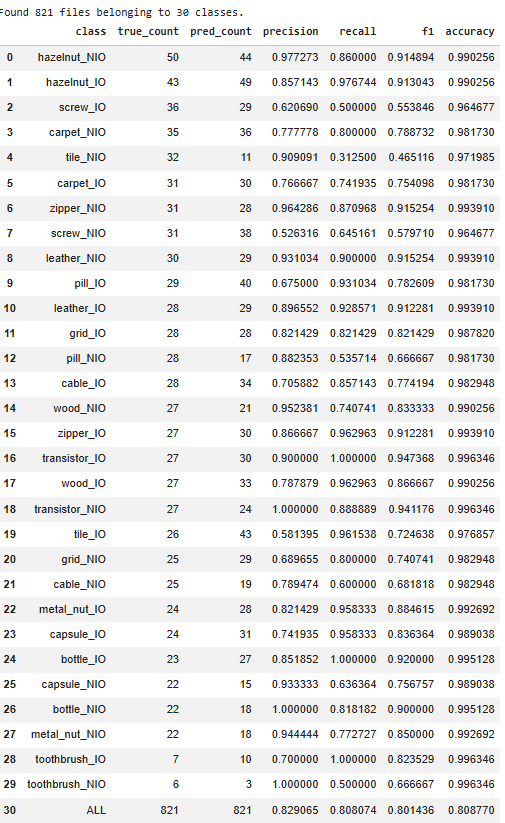

Das getune Modell hat bessere Werte als das Originalmodell.
Der F1 Score ist minimal höher als in der besten Konfiguartion aus 5.2.8. Das zeigt, das die Auswahl beider Hyperparameter die richtige Entscheidung war.


Über mehrere Trainingsläufe hinweg haben wir beobachtet, dass das Modell nicht ganz stabil ist. In einzelnen Runs bricht die Performance ein und es stellt sich nur ein F1-Score um ca. 0.7 ein. Dieses Verhalten trat genau dann auf, wenn in den Callback-Funktionen `val_loss` als Monitoring-Metrik verwendet wurde und das Training anschließend ein Modell aus einer frühen Epoche wiederherstellte. In solchen Fällen kam es zu Verwechslungen, bei denen für einzelne Produktkategorien die IO/NIO-Klassen vertauscht wurden.


Dadurch das die `val_loss` Metrik (wir verwenden Cross-Entropy) nicht nur “richtig/falsch” bewertet, sondern auch die Sicherheit der Vorhersagen, könnte es sein, das einzelne überkonfidente Fehlklassifikationen den Loss so stark erhöhen, dass obwohl spätere Epochen bessere Klassifikationsleistung (und in unserem Fall häufig auch besseren F1-Score) liefern, sich nicht wieder (schnell genug) ein geringerer Loss einstellt.

Um das Training stabiler zu machen, haben wir als Monitoring-Metrik `val_accuracy` verwendet. Damit wird das Modell in der Regel in einer späteren Epoche ausgewählt, in der häufig auch der F1-Score höher und stabiler ist.


### 5.2.10 Tensorboard


Im Folgenden untersuchen wir das Verhalten aus 5.2.9 unter Verwendung des Tensorboards.

Das Tensorboard bietet uns eine Visualisierungen des Trainingsverhaltens. Um es zu nutzen haben wir bei der vorherigen Ausführung die Logs abgespeichert. Diese sind ebenfalls über Google Drive [hier](https://drive.google.com/file/d/1VbHWIEJS8TGulII33OqVxy9c2D9r_Kes/view?usp=sharing) abrufbar.

In [ ]:
file_url: str = "https://drive.google.com/file/d/1VbHWIEJS8TGulII33OqVxy9c2D9r_Kes/view?usp=sharing"
prefix: str = "tensorboard_logs"
load(file_url, prefix)

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir data/tensorboard_logs

Für uns relevant ist jeweils die Accuracy und den Loss über die Epochen hinweg für Train und Validation.

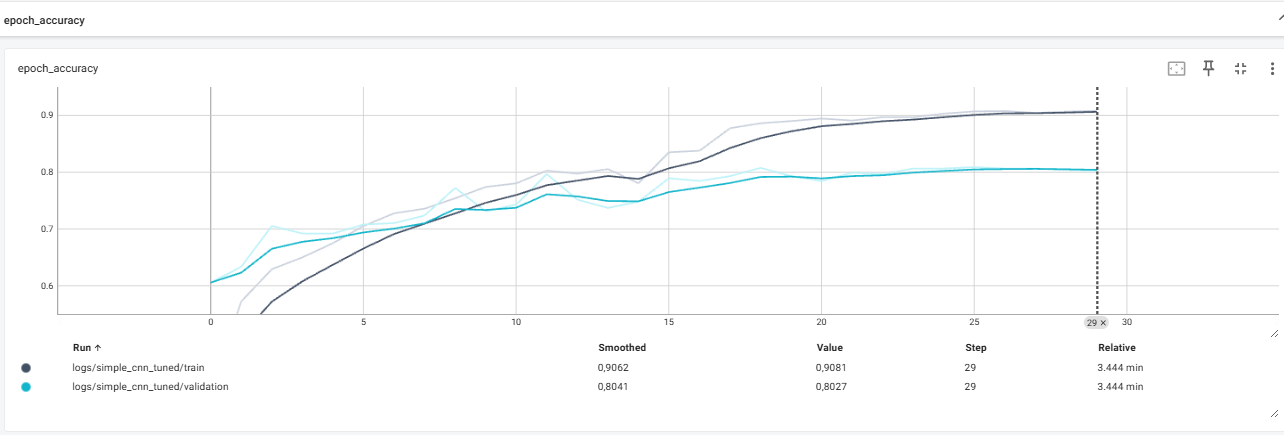

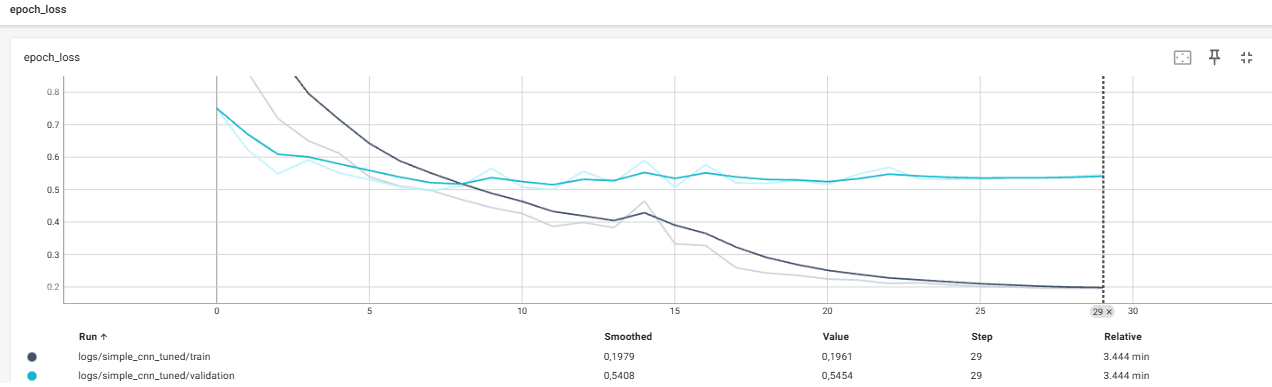

Die Accuracy steigt sowohl auf Trainings- als auch auf Validierungsdaten an. Die Validierungskurve flacht früher ab.
Gleichzeitig fällt der Trainings-Loss kontinuierlich, während der Validierungs-Loss nach einer anfänglichen Verbesserung stagniert.

Dieses Muster deutet darauf hin, dass in späteren Epochen nur noch wenig zusätzliche Generalisierung erreicht wird. Das Modell passt sich auf den Trainingsdaten weiter an, ohne dass sich die Qualität der Vorhersagewahrscheinlichkeiten auf den Validierungsdaten verbessert.
Da der Loss (noch) nicht wieder zunimmt, gehen wir nicht von klassichen Overfitting aus.

Eine plausible Erklärung ist, dass das Modell in vielen Fällen nahe an der Entscheidungsgrenze zwischen IO und NIO liegt. Es wird dadurch auf dem Validierungsset im Mittel nicht deutlich “sicherer” (stagnierender val_loss), kann aber dennoch die Trefferquote leicht erhöhen (steigende val_accuracy), indem einzelne Beispiele gerade noch auf die richtige Seite der Entscheidungsgrenze kippen. Gerade dieses “knappe Über die Grenze kommen” wirkt sich auf die Accuracy aus, ohne dass die Modellkonfidenz insgesamt entsprechend zunimmt.

Da wir konstant einen besseren F1-Score mit der `val_accuracy` erreichen, verwenden ab jetzt `val_accuracy` als Monitoring-Metrik in den Callback-Funktionen.

### 5.2.11 Confusion Matrix

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/11dIeq5jv0vJ0tj8OeWbqwk0u1JKlM5AL/view?usp=sharing",
    "simple_cnn_tuned_bundle")

In [ ]:
cm_counts = plot_confusionmatrix(
    model,
    "data/data_augmented_split/val",
    batch_size=32,
    seed=43,
)

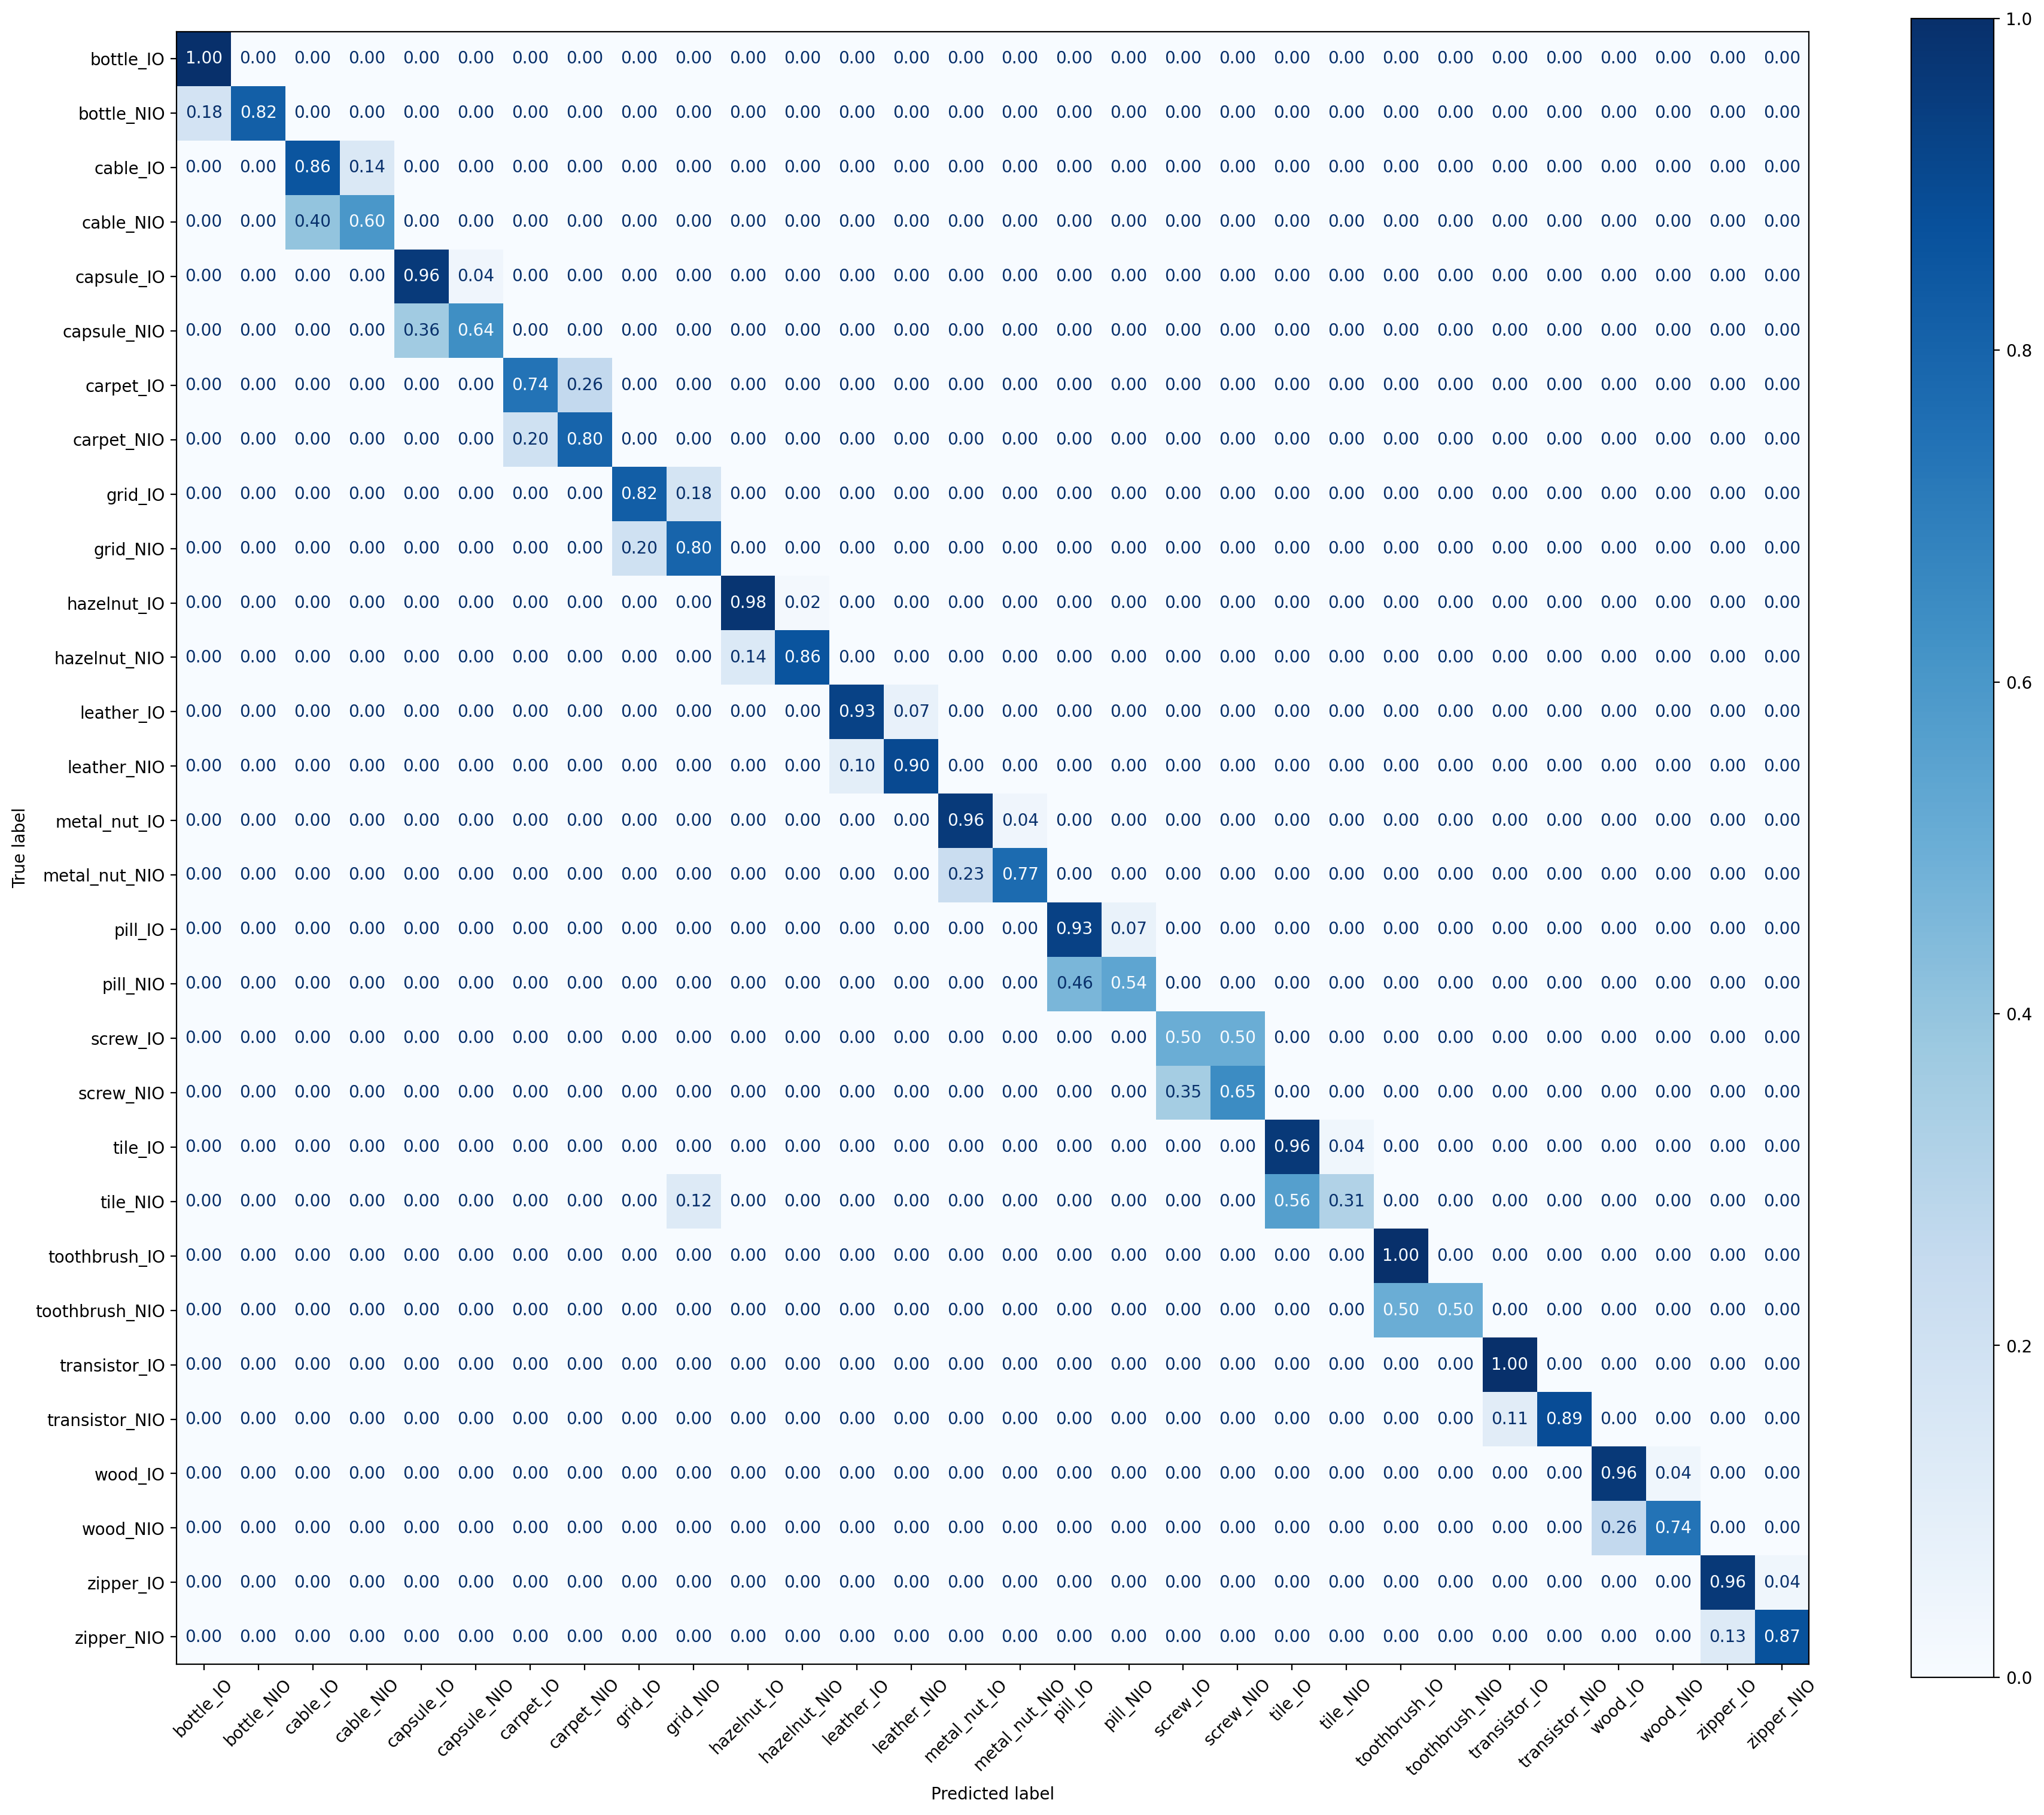

Die Confusionmatrix zeigt recht deutlich, dass wenn eine Klasse falsch klassifziert wird, sie innerhalb einer Kategorie falsch klassifiziert wird.

Interessant ist eine kleine Anomalie über die Kategorien hinaus: Tile NIO und Grid NIO werden manchmal vertauscht.

Evaluationswerte: (werden in Kapitel 5.2.14 besprochen)


In [ ]:
df = eval(model, "data/data_augmented_split/test", batch_size=32, seed=43)
df


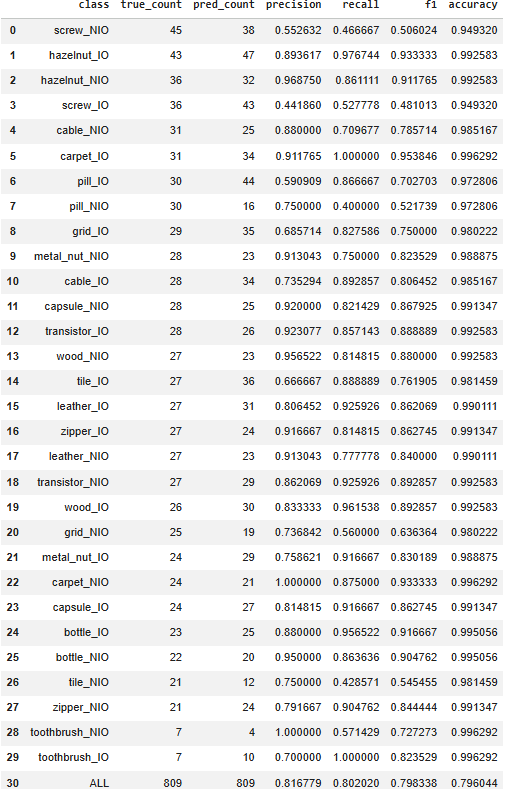

### 5.2.12 Variation A: Classifier-Ensemble

Die Idee dieser Variation des simple_cnn ist es, dem System die Information mitzuteilen, dass es 15 Kategorien gibt und diese sich dann erst in IO/NIO klassifzieren lassen.

Die vorhersage des Modells läuft dabei wie folgt ab:

Es wird zunächst nur die Kategorie durch ein Modell klassifiziert. Anschließend wird das IO/NIO Modell der vorhergesagten Kategorie ausgewählt und angewendet. Die beiden Ergebnisse (Kategorie + IO/NIO) können anschließend wieder zusammengeführt werden um das 30er Klassifikationsproblem zu lösen.

Der größte Nachteil des Modell ist es, dass ein IO/NIO Modell nicht mehr den Fehler des Kategoriemodells korrigieren kann. Würde der Kategorieklassifikator nur 80% der Kategorien richtig vorhersagen und jeder IO/NIO Klassifikator ebenfalls nur 80% richtig vorhersagen, so wären wir nur noch bei 64 % (0.8x0.8).
Da wir jedoch einen "perfekten" Kategorieklassifkator aus Sektion 5.2.3 haben, ist dieser Nachteil nicht existent.




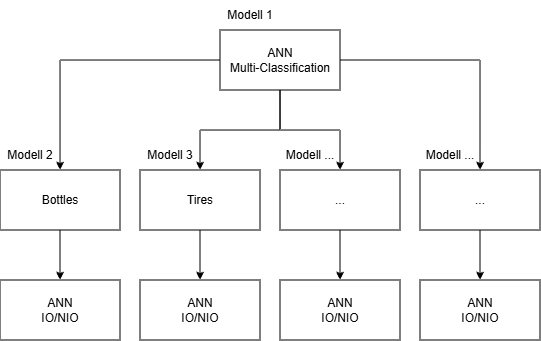

Als Kategorie-Klassifizierer importieren wir das in Kapitel 5.2.3 trainierte Modell wieder. Für jede Kategorie trainieren wir in einem Loop ein IO/NIO Klassifikationsmodell auf den augmentierten IO/NIO Daten der jeweiligen Kategorie. Für die IO/NIO Modelle verwenden wir die Architektur des `simple_cnn` wieder.

Im Anschluss bauen wir uns das Ensemble als kleines "Pseudomodell". Es enhält alle 1 + 15 Modelle. Es wendet den Kategorieklassifikator an, wählt die Kategorie mit der höchsten Confidence aus, wendet das IO/NIO Modell aus und wendet es an. Anschließend kombiniert er die beiden Outputs. Das Pseudomodell hat damit die gleiche Schnittstelle wie das einfaches `simple_cnn`.

#### 5.2.12.1 IO/NIO Modell

In [ ]:
from tensorflow import keras
from keras import layers

def make_simple_cnn_io_nio(input_shape=(180, 180, 3), lr=1e-3, model_name="simple_cnn_io_nio"):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0/255)(inputs)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(2, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


#### 5.2.12.2 IO/NIO Training

In [ ]:
from tensorflow import keras

# We need the category sorting from here, as we trained the category modell based on not augmented data
cat_ds = keras.utils.image_dataset_from_directory(
    "data/data_not_augmented_split_categories_only/val",
    image_size=(180,180),
    batch_size=32,
    shuffle=False,
)
CATEGORIES = cat_ds.class_names
print(CATEGORIES)


In [ ]:
lr = 1e-3
epochs = 20
seed = 43

io_models = {}  # Per category a model

for cat in CATEGORIES:
    class_names_2 = [f"{cat}_IO", f"{cat}_NIO"]

    name = f"simple_cnn_io_nio_{cat}"
    model_io = make_simple_cnn_io_nio(lr=lr, model_name=name)

    inp = TrainInput(
        data_dir="data/data_augmented_split",
        model=model_io,
        seed=seed,
        epochs=epochs,
        callback_metric="val_accuracy",
        tensorboard_logdir=f"logs/io_{cat}",
        class_names=class_names_2,
    )

    out = train(inp)
    io_models[cat] = out.model

    run = dict(
        name=out.model.name,
        model=out.model,
        model_name=out.model.name,
        lr=lr,
        seed=seed,
        epochs=epochs,
    )
    zip_path = export_model(run)
    print("Exported:", zip_path)

    df2 = eval(out.model, "data/data_augmented_split/val", class_names=class_names_2)
    print(cat, df2.tail(1))  # ALL-Line


<details>
  <summary>Training-Log</summary>

```

Found 368 files belonging to 2 classes.
Found 45 files belonging to 2 classes.
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 411ms/step - accuracy: 0.5165 - loss: 0.8148 - val_accuracy: 0.4889 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5650 - loss: 0.6886 - val_accuracy: 0.9111 - val_loss: 0.6701 - learning_rate: 0.0010
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7216 - loss: 0.6349 - val_accuracy: 0.5111 - val_loss: 0.6497 - learning_rate: 0.0010
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7693 - loss: 0.5603 - val_accuracy: 0.5333 - val_loss: 0.6206 - learning_rate: 0.0010
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8757 - loss: 0.3738 - val_accuracy: 0.9333 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9328 - loss: 0.2672 - val_accuracy: 0.8222 - val_loss: 0.3752 - learning_rate: 0.0010
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9098 - loss: 0.2462 - val_accuracy: 0.9333 - val_loss: 0.3142 - learning_rate: 0.0010
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9520 - loss: 0.1665 - val_accuracy: 0.9333 - val_loss: 0.2000 - learning_rate: 0.0010
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9687 - loss: 0.1310 - val_accuracy: 0.8889 - val_loss: 0.2599 - learning_rate: 0.0010
Epoch 10/20
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9583 - loss: 0.1353
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9564 - loss: 0.1362 - val_accuracy: 0.9111 - val_loss: 0.2283 - learning_rate: 0.0010
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9275 - loss: 0.1826 - val_accuracy: 0.8222 - val_loss: 0.3255 - learning_rate: 1.0000e-04
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9667 - loss: 0.1151 - val_accuracy: 0.8667 - val_loss: 0.2726 - learning_rate: 1.0000e-04
Epoch 13/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9779 - loss: 0.0771 - val_accuracy: 0.8889 - val_loss: 0.1982 - learning_rate: 1.0000e-04
Epoch 14/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9706 - loss: 0.0966 - val_accuracy: 0.8889 - val_loss: 0.1909 - learning_rate: 1.0000e-04
Epoch 15/20
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9677 - loss: 0.1019
Epoch 15: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9697 - loss: 0.0993 - val_accuracy: 0.8889 - val_loss: 0.2013 - learning_rate: 1.0000e-04
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 5.
Exported: export/simple_cnn_io_nio_bottle_bundle.zip
Found 45 files belonging to 2 classes.
bottle   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          45          45   0.942308  0.931818  0.932802  0.933333
Found 452 files belonging to 2 classes.
Found 53 files belonging to 2 classes.
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.4483 - loss: 0.8922 - val_accuracy: 0.4717 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5398 - loss: 0.6937 - val_accuracy: 0.5472 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6786 - loss: 0.6901 - val_accuracy: 0.5094 - val_loss: 0.6848 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6237 - loss: 0.6682 - val_accuracy: 0.5283 - val_loss: 0.6885 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6663 - loss: 0.6087 - val_accuracy: 0.7925 - val_loss: 0.5933 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7548 - loss: 0.5120 - val_accuracy: 0.6038 - val_loss: 0.5777 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7916 - loss: 0.4239 - val_accuracy: 0.8302 - val_loss: 0.5156 - learning_rate: 0.0010
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8590 - loss: 0.4132 - val_accuracy: 0.7736 - val_loss: 0.6655 - learning_rate: 0.0010
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8237 - loss: 0.3530 - val_accuracy: 0.8302 - val_loss: 0.3842 - learning_rate: 0.0010
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9016 - loss: 0.2438 - val_accuracy: 0.8868 - val_loss: 0.2915 - learning_rate: 0.0010
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9351 - loss: 0.1695 - val_accuracy: 0.7736 - val_loss: 0.3690 - learning_rate: 0.0010
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9337 - loss: 0.1873 - val_accuracy: 0.9057 - val_loss: 0.3263 - learning_rate: 0.0010
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9585 - loss: 0.1318 - val_accuracy: 0.8302 - val_loss: 0.4136 - learning_rate: 0.0010
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9185 - loss: 0.1623 - val_accuracy: 0.8491 - val_loss: 0.3563 - learning_rate: 0.0010
Epoch 15/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9693 - loss: 0.1084 - val_accuracy: 0.8868 - val_loss: 0.3647 - learning_rate: 0.0010
Epoch 16/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9687 - loss: 0.0938 - val_accuracy: 0.8868 - val_loss: 0.3887 - learning_rate: 0.0010
Epoch 17/20
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9858 - loss: 0.0685
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9834 - loss: 0.0699 - val_accuracy: 0.8679 - val_loss: 0.3758 - learning_rate: 0.0010
Epoch 18/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9928 - loss: 0.0385 - val_accuracy: 0.8679 - val_loss: 0.3910 - learning_rate: 1.0000e-04
Epoch 19/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9871 - loss: 0.0457 - val_accuracy: 0.8679 - val_loss: 0.4046 - learning_rate: 1.0000e-04
Epoch 20/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9933 - loss: 0.0252 - val_accuracy: 0.8679 - val_loss: 0.4197 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 12.
Exported: export/simple_cnn_io_nio_cable_bundle.zip
Found 53 files belonging to 2 classes.
cable   class  true_count  pred_count  precision    recall       f1  accuracy
2   ALL          53          53   0.906609  0.904286  0.90512   0.90566
Found 386 files belonging to 2 classes.
Found 46 files belonging to 2 classes.
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.5089 - loss: 1.1230 - val_accuracy: 0.4783 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4717 - loss: 0.6952 - val_accuracy: 0.6522 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5788 - loss: 0.6903 - val_accuracy: 0.4565 - val_loss: 0.6891 - learning_rate: 0.0010
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5634 - loss: 0.6882 - val_accuracy: 0.5870 - val_loss: 0.6751 - learning_rate: 0.0010
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4963 - loss: 0.6757 - val_accuracy: 0.4783 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5575 - loss: 0.6476 - val_accuracy: 0.4565 - val_loss: 0.6549 - learning_rate: 0.0010
Epoch 7/20
10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5863 - loss: 0.6463
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5918 - loss: 0.6414 - val_accuracy: 0.6304 - val_loss: 0.6363 - learning_rate: 0.0010
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6176 - loss: 0.6201 - val_accuracy: 0.6304 - val_loss: 0.6343 - learning_rate: 1.0000e-04
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5604 - loss: 0.6180 - val_accuracy: 0.6087 - val_loss: 0.6336 - learning_rate: 1.0000e-04
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5924 - loss: 0.6209 - val_accuracy: 0.6304 - val_loss: 0.6304 - learning_rate: 1.0000e-04
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6575 - loss: 0.6170 - val_accuracy: 0.6304 - val_loss: 0.6294 - learning_rate: 1.0000e-04
Epoch 12/20
10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6150 - loss: 0.6133
Epoch 12: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6229 - loss: 0.6132 - val_accuracy: 0.6522 - val_loss: 0.6275 - learning_rate: 1.0000e-04
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 2.
Exported: export/simple_cnn_io_nio_capsule_bundle.zip
Found 46 files belonging to 2 classes.
capsule   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          46          46        0.8  0.636364  0.589286  0.652174
Found 495 files belonging to 2 classes.
Found 66 files belonging to 2 classes.
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 0.5086 - loss: 0.8637 - val_accuracy: 0.5303 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4947 - loss: 0.7001 - val_accuracy: 0.4697 - val_loss: 0.6960 - learning_rate: 0.0010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5304 - loss: 0.6908 - val_accuracy: 0.5303 - val_loss: 0.6861 - learning_rate: 0.0010
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5164 - loss: 0.6925 - val_accuracy: 0.5303 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4764 - loss: 0.6932 - val_accuracy: 0.5303 - val_loss: 0.6889 - learning_rate: 0.0010
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4997 - loss: 0.6911 - val_accuracy: 0.8485 - val_loss: 0.6889 - learning_rate: 0.0010
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5207 - loss: 0.6917 - val_accuracy: 0.4697 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5329 - loss: 0.6837 - val_accuracy: 0.5303 - val_loss: 0.6542 - learning_rate: 0.0010
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5365 - loss: 0.6867 - val_accuracy: 0.5303 - val_loss: 0.6817 - learning_rate: 0.0010
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4868 - loss: 0.6924 - val_accuracy: 0.5303 - val_loss: 0.6875 - learning_rate: 0.0010
Epoch 11/20
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5109 - loss: 0.6869
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5145 - loss: 0.6861 - val_accuracy: 0.4697 - val_loss: 0.7173 - learning_rate: 0.0010
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5493 - loss: 0.6660 - val_accuracy: 0.5606 - val_loss: 0.6280 - learning_rate: 1.0000e-04
Epoch 13/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6779 - loss: 0.6347 - val_accuracy: 0.8182 - val_loss: 0.6009 - learning_rate: 1.0000e-04
Epoch 14/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7698 - loss: 0.6095 - val_accuracy: 0.8788 - val_loss: 0.5715 - learning_rate: 1.0000e-04
Epoch 15/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8607 - loss: 0.5811 - val_accuracy: 0.8788 - val_loss: 0.5415 - learning_rate: 1.0000e-04
Epoch 16/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7274 - loss: 0.5760 - val_accuracy: 0.6212 - val_loss: 0.5550 - learning_rate: 1.0000e-04
Epoch 17/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6964 - loss: 0.5710 - val_accuracy: 0.8788 - val_loss: 0.4969 - learning_rate: 1.0000e-04
Epoch 18/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8605 - loss: 0.5224 - val_accuracy: 0.8788 - val_loss: 0.4719 - learning_rate: 1.0000e-04
Epoch 19/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8627 - loss: 0.4997 - val_accuracy: 0.8939 - val_loss: 0.4375 - learning_rate: 1.0000e-04
Epoch 20/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8457 - loss: 0.4903 - val_accuracy: 0.8939 - val_loss: 0.4273 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 19.
Exported: export/simple_cnn_io_nio_carpet_bundle.zip
Found 66 files belonging to 2 classes.
carpet   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          66          66   0.894444  0.892627  0.893327  0.893939
Found 463 files belonging to 2 classes.
Found 53 files belonging to 2 classes.
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.4863 - loss: 0.7672 - val_accuracy: 0.5283 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5201 - loss: 0.6942 - val_accuracy: 0.4906 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5734 - loss: 0.6903 - val_accuracy: 0.4906 - val_loss: 0.6903 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5701 - loss: 0.6856 - val_accuracy: 0.5283 - val_loss: 0.6921 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5303 - loss: 0.6849 - val_accuracy: 0.5283 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6545 - loss: 0.6480 - val_accuracy: 0.5472 - val_loss: 0.6877 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6607 - loss: 0.6350 - val_accuracy: 0.5094 - val_loss: 0.7107 - learning_rate: 0.0010
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6907 - loss: 0.5771 - val_accuracy: 0.5472 - val_loss: 0.6860 - learning_rate: 0.0010
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7017 - loss: 0.5611 - val_accuracy: 0.5660 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7728 - loss: 0.4681 - val_accuracy: 0.5660 - val_loss: 0.6141 - learning_rate: 0.0010
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7964 - loss: 0.4326 - val_accuracy: 0.6226 - val_loss: 0.6289 - learning_rate: 0.0010
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8264 - loss: 0.4062 - val_accuracy: 0.6415 - val_loss: 0.6199 - learning_rate: 0.0010
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8226 - loss: 0.3542 - val_accuracy: 0.7358 - val_loss: 0.5602 - learning_rate: 0.0010
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8654 - loss: 0.2831 - val_accuracy: 0.7358 - val_loss: 0.5740 - learning_rate: 0.0010
Epoch 15/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9091 - loss: 0.2243 - val_accuracy: 0.6226 - val_loss: 0.9349 - learning_rate: 0.0010
Epoch 16/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8976 - loss: 0.2820 - val_accuracy: 0.7170 - val_loss: 0.7751 - learning_rate: 0.0010
Epoch 17/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9488 - loss: 0.1657 - val_accuracy: 0.6981 - val_loss: 0.7385 - learning_rate: 0.0010
Epoch 18/20
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9544 - loss: 0.1394
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9541 - loss: 0.1386 - val_accuracy: 0.6792 - val_loss: 0.8056 - learning_rate: 0.0010
Epoch 19/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9228 - loss: 0.1556 - val_accuracy: 0.6792 - val_loss: 0.8007 - learning_rate: 1.0000e-04
Epoch 20/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9808 - loss: 0.0957 - val_accuracy: 0.6981 - val_loss: 0.6732 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 13.
Exported: export/simple_cnn_io_nio_grid_bundle.zip
Found 53 files belonging to 2 classes.
grid   class  true_count  pred_count  precision  recall     f1  accuracy
2   ALL          53          53      0.735   0.735  0.735  0.735849
Found 690 files belonging to 2 classes.
Found 93 files belonging to 2 classes.
Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - accuracy: 0.5795 - loss: 0.7338 - val_accuracy: 0.6774 - val_loss: 0.6437 - learning_rate: 0.0010
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7241 - loss: 0.5851 - val_accuracy: 0.6882 - val_loss: 0.5787 - learning_rate: 0.0010
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7489 - loss: 0.4748 - val_accuracy: 0.7312 - val_loss: 0.5161 - learning_rate: 0.0010
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8522 - loss: 0.3461 - val_accuracy: 0.8172 - val_loss: 0.3596 - learning_rate: 0.0010
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8644 - loss: 0.2758 - val_accuracy: 0.8280 - val_loss: 0.3904 - learning_rate: 0.0010
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9235 - loss: 0.2060 - val_accuracy: 0.8495 - val_loss: 0.3588 - learning_rate: 0.0010
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9526 - loss: 0.1396 - val_accuracy: 0.8602 - val_loss: 0.3880 - learning_rate: 0.0010
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9520 - loss: 0.1388 - val_accuracy: 0.8710 - val_loss: 0.3709 - learning_rate: 0.0010
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9775 - loss: 0.0874 - val_accuracy: 0.8925 - val_loss: 0.3326 - learning_rate: 0.0010
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9757 - loss: 0.0955 - val_accuracy: 0.9032 - val_loss: 0.3228 - learning_rate: 0.0010
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9774 - loss: 0.0632 - val_accuracy: 0.8817 - val_loss: 0.2957 - learning_rate: 0.0010
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9792 - loss: 0.0531 - val_accuracy: 0.8817 - val_loss: 0.5816 - learning_rate: 0.0010
Epoch 13/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9590 - loss: 0.1073 - val_accuracy: 0.9032 - val_loss: 0.2522 - learning_rate: 0.0010
Epoch 14/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9819 - loss: 0.0625 - val_accuracy: 0.9570 - val_loss: 0.1409 - learning_rate: 0.0010
Epoch 15/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9893 - loss: 0.0471 - val_accuracy: 0.9140 - val_loss: 0.1945 - learning_rate: 0.0010
Epoch 16/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9893 - loss: 0.0431 - val_accuracy: 0.8495 - val_loss: 0.5135 - learning_rate: 0.0010
Epoch 17/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9496 - loss: 0.1176 - val_accuracy: 0.8280 - val_loss: 0.4647 - learning_rate: 0.0010
Epoch 18/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9786 - loss: 0.0594 - val_accuracy: 0.8602 - val_loss: 0.3295 - learning_rate: 0.0010
Epoch 19/20
19/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9837 - loss: 0.0474
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9843 - loss: 0.0462 - val_accuracy: 0.9462 - val_loss: 0.1791 - learning_rate: 0.0010
Epoch 20/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9940 - loss: 0.0274 - val_accuracy: 0.9570 - val_loss: 0.1365 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 14.
Exported: export/simple_cnn_io_nio_hazelnut_bundle.zip
Found 93 files belonging to 2 classes.
hazelnut   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          93          93    0.95625  0.958372  0.956865  0.956989
Found 442 files belonging to 2 classes.
Found 58 files belonging to 2 classes.
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 45s 245ms/step - accuracy: 0.4770 - loss: 1.0689 - val_accuracy: 0.5172 - val_loss: 0.6881 - learning_rate: 0.0010
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4748 - loss: 0.6912 - val_accuracy: 0.5172 - val_loss: 0.6785 - learning_rate: 0.0010
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5359 - loss: 0.6915 - val_accuracy: 0.5172 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5490 - loss: 0.6774 - val_accuracy: 0.8276 - val_loss: 0.6523 - learning_rate: 0.0010
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6024 - loss: 0.6709 - val_accuracy: 0.5172 - val_loss: 0.6809 - learning_rate: 0.0010
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5094 - loss: 0.6843 - val_accuracy: 0.5172 - val_loss: 0.6507 - learning_rate: 0.0010
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6087 - loss: 0.6557 - val_accuracy: 0.4655 - val_loss: 0.6656 - learning_rate: 0.0010
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6411 - loss: 0.6544 - val_accuracy: 0.5345 - val_loss: 0.6230 - learning_rate: 0.0010
Epoch 9/20
12/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7502 - loss: 0.5697
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7535 - loss: 0.5676 - val_accuracy: 0.7759 - val_loss: 0.5759 - learning_rate: 0.0010
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8292 - loss: 0.4979 - val_accuracy: 0.8448 - val_loss: 0.5286 - learning_rate: 1.0000e-04
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8680 - loss: 0.4376 - val_accuracy: 0.8966 - val_loss: 0.5077 - learning_rate: 1.0000e-04
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8718 - loss: 0.4368 - val_accuracy: 0.8448 - val_loss: 0.5145 - learning_rate: 1.0000e-04
Epoch 13/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8627 - loss: 0.4091 - val_accuracy: 0.8448 - val_loss: 0.4771 - learning_rate: 1.0000e-04
Epoch 14/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9083 - loss: 0.3585 - val_accuracy: 0.8966 - val_loss: 0.4829 - learning_rate: 1.0000e-04
Epoch 15/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8864 - loss: 0.3900 - val_accuracy: 0.8448 - val_loss: 0.4556 - learning_rate: 1.0000e-04
Epoch 16/20
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8674 - loss: 0.3975
Epoch 16: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8694 - loss: 0.3964 - val_accuracy: 0.8448 - val_loss: 0.4493 - learning_rate: 1.0000e-04
Epoch 17/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8968 - loss: 0.3489 - val_accuracy: 0.8448 - val_loss: 0.4545 - learning_rate: 1.0000e-05
Epoch 18/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8795 - loss: 0.3741 - val_accuracy: 0.8966 - val_loss: 0.4679 - learning_rate: 1.0000e-05
Epoch 19/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8774 - loss: 0.3804 - val_accuracy: 0.8966 - val_loss: 0.4678 - learning_rate: 1.0000e-05
Epoch 20/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8550 - loss: 0.4138 - val_accuracy: 0.8966 - val_loss: 0.4631 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 11.
Exported: export/simple_cnn_io_nio_leather_bundle.zip
Found 58 files belonging to 2 classes.
leather   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          58          58   0.916667  0.892857  0.894545  0.896552
Found 386 files belonging to 2 classes.
Found 46 files belonging to 2 classes.
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step - accuracy: 0.5364 - loss: 0.8088 - val_accuracy: 0.5217 - val_loss: 0.6866 - learning_rate: 0.0010
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6674 - loss: 0.6818 - val_accuracy: 0.7609 - val_loss: 0.6565 - learning_rate: 0.0010
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6737 - loss: 0.6401 - val_accuracy: 0.6957 - val_loss: 0.6001 - learning_rate: 0.0010
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7681 - loss: 0.5443 - val_accuracy: 0.8696 - val_loss: 0.4602 - learning_rate: 0.0010
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8244 - loss: 0.4269 - val_accuracy: 0.7609 - val_loss: 0.4327 - learning_rate: 0.0010
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7302 - loss: 0.4988 - val_accuracy: 0.8261 - val_loss: 0.4595 - learning_rate: 0.0010
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8113 - loss: 0.4504 - val_accuracy: 0.8696 - val_loss: 0.4112 - learning_rate: 0.0010
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8688 - loss: 0.3562 - val_accuracy: 0.8696 - val_loss: 0.3550 - learning_rate: 0.0010
Epoch 9/20
10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8815 - loss: 0.3197
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8784 - loss: 0.3174 - val_accuracy: 0.8696 - val_loss: 0.3811 - learning_rate: 0.0010
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8505 - loss: 0.3254 - val_accuracy: 0.8478 - val_loss: 0.3489 - learning_rate: 1.0000e-04
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8722 - loss: 0.2940 - val_accuracy: 0.8478 - val_loss: 0.3593 - learning_rate: 1.0000e-04
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8971 - loss: 0.2819 - val_accuracy: 0.8478 - val_loss: 0.3503 - learning_rate: 1.0000e-04
Epoch 13/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8854 - loss: 0.2937 - val_accuracy: 0.8261 - val_loss: 0.3335 - learning_rate: 1.0000e-04
Epoch 14/20
10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8918 - loss: 0.2752
Epoch 14: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8880 - loss: 0.2764 - val_accuracy: 0.8696 - val_loss: 0.3336 - learning_rate: 1.0000e-04
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.
Exported: export/simple_cnn_io_nio_metal_nut_bundle.zip
Found 46 files belonging to 2 classes.
metal_nut   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          46          46        0.9  0.863636  0.865497  0.869565
Found 469 files belonging to 2 classes.
Found 57 files belonging to 2 classes.
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.4791 - loss: 0.9369 - val_accuracy: 0.4912 - val_loss: 0.6879 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5371 - loss: 0.6629 - val_accuracy: 0.5439 - val_loss: 0.6531 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5899 - loss: 0.6470 - val_accuracy: 0.5965 - val_loss: 0.6246 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6046 - loss: 0.6117 - val_accuracy: 0.6316 - val_loss: 0.5868 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6437 - loss: 0.5709 - val_accuracy: 0.6316 - val_loss: 0.5726 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5917 - loss: 0.5982 - val_accuracy: 0.5789 - val_loss: 0.6045 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6667 - loss: 0.5800 - val_accuracy: 0.7018 - val_loss: 0.5438 - learning_rate: 0.0010
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7103 - loss: 0.5515 - val_accuracy: 0.6667 - val_loss: 0.6157 - learning_rate: 0.0010
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7116 - loss: 0.5712 - val_accuracy: 0.4912 - val_loss: 0.7427 - learning_rate: 0.0010
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7007 - loss: 0.6223 - val_accuracy: 0.7719 - val_loss: 0.5182 - learning_rate: 0.0010
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7243 - loss: 0.5323 - val_accuracy: 0.6667 - val_loss: 0.5837 - learning_rate: 0.0010
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6880 - loss: 0.5591 - val_accuracy: 0.7193 - val_loss: 0.5138 - learning_rate: 0.0010
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7112 - loss: 0.5104 - val_accuracy: 0.7368 - val_loss: 0.4891 - learning_rate: 0.0010
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7328 - loss: 0.5140 - val_accuracy: 0.7368 - val_loss: 0.4738 - learning_rate: 0.0010
Epoch 15/20
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7691 - loss: 0.4788
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7672 - loss: 0.4774 - val_accuracy: 0.7018 - val_loss: 0.4894 - learning_rate: 0.0010
Epoch 16/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7076 - loss: 0.5259 - val_accuracy: 0.7719 - val_loss: 0.4788 - learning_rate: 1.0000e-04
Epoch 17/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7035 - loss: 0.5193 - val_accuracy: 0.7719 - val_loss: 0.4691 - learning_rate: 1.0000e-04
Epoch 18/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7224 - loss: 0.4660 - val_accuracy: 0.8246 - val_loss: 0.4489 - learning_rate: 1.0000e-04
Epoch 19/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7457 - loss: 0.4589 - val_accuracy: 0.8596 - val_loss: 0.4245 - learning_rate: 1.0000e-04
Epoch 20/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7611 - loss: 0.4246 - val_accuracy: 0.8596 - val_loss: 0.4068 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 19.
Exported: export/simple_cnn_io_nio_pill_bundle.zip
Found 57 files belonging to 2 classes.
pill   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          57          57   0.867424  0.858374  0.858561  0.859649
Found 574 files belonging to 2 classes.
Found 67 files belonging to 2 classes.
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 199ms/step - accuracy: 0.5128 - loss: 0.9471 - val_accuracy: 0.4627 - val_loss: 0.7040 - learning_rate: 0.0010
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.4943 - loss: 0.6957 - val_accuracy: 0.5373 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5408 - loss: 0.6928 - val_accuracy: 0.5224 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5221 - loss: 0.6925 - val_accuracy: 0.5373 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5725 - loss: 0.6927 - val_accuracy: 0.5224 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5475 - loss: 0.6918 - val_accuracy: 0.5373 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 7/20
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5786 - loss: 0.6915
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5850 - loss: 0.6912 - val_accuracy: 0.5075 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6076 - loss: 0.6852 - val_accuracy: 0.5075 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5967 - loss: 0.6856 - val_accuracy: 0.4925 - val_loss: 0.6924 - learning_rate: 1.0000e-04
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5996 - loss: 0.6831 - val_accuracy: 0.5224 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5900 - loss: 0.6849 - val_accuracy: 0.4925 - val_loss: 0.6922 - learning_rate: 1.0000e-04
Epoch 12/20
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6290 - loss: 0.6823
Epoch 12: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6300 - loss: 0.6816 - val_accuracy: 0.4478 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 2.
Exported: export/simple_cnn_io_nio_screw_bundle.zip
Found 67 files belonging to 2 classes.
screw   class  true_count  pred_count  precision  recall        f1  accuracy
2   ALL          67          67   0.268657     0.5  0.349515  0.537313
Found 420 files belonging to 2 classes.
Found 58 files belonging to 2 classes.
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step - accuracy: 0.4970 - loss: 0.8269 - val_accuracy: 0.4483 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6130 - loss: 0.6917 - val_accuracy: 0.4483 - val_loss: 0.6962 - learning_rate: 0.0010
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5252 - loss: 0.6898 - val_accuracy: 0.4483 - val_loss: 0.7314 - learning_rate: 0.0010
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5318 - loss: 0.6990 - val_accuracy: 0.4483 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4991 - loss: 0.6903 - val_accuracy: 0.4828 - val_loss: 0.6862 - learning_rate: 0.0010
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5861 - loss: 0.6833 - val_accuracy: 0.5000 - val_loss: 0.6799 - learning_rate: 0.0010
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6192 - loss: 0.6785 - val_accuracy: 0.5517 - val_loss: 0.6751 - learning_rate: 0.0010
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6484 - loss: 0.6683 - val_accuracy: 0.4483 - val_loss: 0.7493 - learning_rate: 0.0010
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6193 - loss: 0.6566 - val_accuracy: 0.5690 - val_loss: 0.6786 - learning_rate: 0.0010
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7156 - loss: 0.6233 - val_accuracy: 0.6207 - val_loss: 0.6236 - learning_rate: 0.0010
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7426 - loss: 0.5274 - val_accuracy: 0.6207 - val_loss: 0.5660 - learning_rate: 0.0010
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7343 - loss: 0.5117 - val_accuracy: 0.5345 - val_loss: 0.6665 - learning_rate: 0.0010
Epoch 13/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7920 - loss: 0.6215 - val_accuracy: 0.5000 - val_loss: 1.5755 - learning_rate: 0.0010
Epoch 14/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7764 - loss: 0.7145 - val_accuracy: 0.6897 - val_loss: 0.4798 - learning_rate: 0.0010
Epoch 15/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7287 - loss: 0.4778 - val_accuracy: 0.6897 - val_loss: 0.5503 - learning_rate: 0.0010
Epoch 16/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7006 - loss: 0.5718 - val_accuracy: 0.7931 - val_loss: 0.5532 - learning_rate: 0.0010
Epoch 17/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9030 - loss: 0.3897 - val_accuracy: 0.7931 - val_loss: 0.4395 - learning_rate: 0.0010
Epoch 18/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8747 - loss: 0.3098 - val_accuracy: 0.7414 - val_loss: 0.5945 - learning_rate: 0.0010
Epoch 19/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8313 - loss: 0.3551 - val_accuracy: 0.7931 - val_loss: 0.3788 - learning_rate: 0.0010
Epoch 20/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8900 - loss: 0.2627 - val_accuracy: 0.7931 - val_loss: 0.5418 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 16.
Exported: export/simple_cnn_io_nio_tile_bundle.zip
Found 58 files belonging to 2 classes.
tile   class  true_count  pred_count  precision  recall        f1  accuracy
2   ALL          58          58   0.842105  0.8125  0.790865  0.793103
Found 117 files belonging to 2 classes.
Found 13 files belonging to 2 classes.
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 880ms/step - accuracy: 0.4186 - loss: 0.8395 - val_accuracy: 0.4615 - val_loss: 0.7216 - learning_rate: 0.0010
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5194 - loss: 0.6957 - val_accuracy: 0.4615 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5215 - loss: 0.6833 - val_accuracy: 0.4615 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5931 - loss: 0.6804 - val_accuracy: 0.4615 - val_loss: 0.6878 - learning_rate: 0.0010
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5231 - loss: 0.6737 - val_accuracy: 0.4615 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5424 - loss: 0.6740 - val_accuracy: 0.5385 - val_loss: 0.6705 - learning_rate: 0.0010
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7356 - loss: 0.6361 - val_accuracy: 0.4615 - val_loss: 0.6667 - learning_rate: 0.0010
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5538 - loss: 0.6130 - val_accuracy: 0.7692 - val_loss: 0.6230 - learning_rate: 0.0010
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7220 - loss: 0.6018 - val_accuracy: 0.6154 - val_loss: 0.6056 - learning_rate: 0.0010
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5868 - loss: 0.5957 - val_accuracy: 0.6154 - val_loss: 0.6019 - learning_rate: 0.0010
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7308 - loss: 0.5486 - val_accuracy: 0.7692 - val_loss: 0.5509 - learning_rate: 0.0010
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7535 - loss: 0.5216 - val_accuracy: 0.7692 - val_loss: 0.5482 - learning_rate: 0.0010
Epoch 13/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7679 - loss: 0.5111
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7631 - loss: 0.5144 - val_accuracy: 0.7692 - val_loss: 0.4599 - learning_rate: 0.0010
Epoch 14/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7510 - loss: 0.4499 - val_accuracy: 0.7692 - val_loss: 0.4482 - learning_rate: 1.0000e-04
Epoch 15/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8307 - loss: 0.4022 - val_accuracy: 0.9231 - val_loss: 0.4440 - learning_rate: 1.0000e-04
Epoch 16/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7333 - loss: 0.4254 - val_accuracy: 0.8462 - val_loss: 0.4531 - learning_rate: 1.0000e-04
Epoch 17/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7357 - loss: 0.4652 - val_accuracy: 0.9231 - val_loss: 0.4375 - learning_rate: 1.0000e-04
Epoch 18/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8178 - loss: 0.3655 - val_accuracy: 0.7692 - val_loss: 0.4279 - learning_rate: 1.0000e-04
Epoch 19/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8022 - loss: 0.4291 - val_accuracy: 0.9231 - val_loss: 0.4204 - learning_rate: 1.0000e-04
Epoch 20/20
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8125 - loss: 0.3778
Epoch 20: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7976 - loss: 0.3971 - val_accuracy: 0.9231 - val_loss: 0.4220 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 15.
Exported: export/simple_cnn_io_nio_toothbrush_bundle.zip
Found 13 files belonging to 2 classes.
toothbrush   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          13          13     0.9375  0.916667  0.921212  0.923077
Found 437 files belonging to 2 classes.
Found 54 files belonging to 2 classes.
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.5709 - loss: 0.7435 - val_accuracy: 0.6111 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7560 - loss: 0.4943 - val_accuracy: 0.9630 - val_loss: 0.1653 - learning_rate: 0.0010
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9386 - loss: 0.1920 - val_accuracy: 0.9259 - val_loss: 0.1897 - learning_rate: 0.0010
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8975 - loss: 0.2671 - val_accuracy: 0.9630 - val_loss: 0.2154 - learning_rate: 0.0010
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9416 - loss: 0.1848 - val_accuracy: 0.9815 - val_loss: 0.1106 - learning_rate: 0.0010
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9532 - loss: 0.1139 - val_accuracy: 0.9815 - val_loss: 0.0765 - learning_rate: 0.0010
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9621 - loss: 0.1374 - val_accuracy: 0.9815 - val_loss: 0.0617 - learning_rate: 0.0010
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9486 - loss: 0.1145 - val_accuracy: 0.9815 - val_loss: 0.0636 - learning_rate: 0.0010
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9571 - loss: 0.1264 - val_accuracy: 0.9815 - val_loss: 0.0628 - learning_rate: 0.0010
Epoch 10/20
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9710 - loss: 0.1066
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9706 - loss: 0.1057 - val_accuracy: 0.9815 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9617 - loss: 0.1201 - val_accuracy: 0.9815 - val_loss: 0.0602 - learning_rate: 1.0000e-04
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9810 - loss: 0.0646 - val_accuracy: 0.9815 - val_loss: 0.0425 - learning_rate: 1.0000e-04
Epoch 13/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9681 - loss: 0.0720 - val_accuracy: 0.9815 - val_loss: 0.0414 - learning_rate: 1.0000e-04
Epoch 14/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9834 - loss: 0.0622 - val_accuracy: 0.9815 - val_loss: 0.0416 - learning_rate: 1.0000e-04
Epoch 15/20
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9837 - loss: 0.0612
Epoch 15: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9831 - loss: 0.0617 - val_accuracy: 0.9815 - val_loss: 0.0379 - learning_rate: 1.0000e-04
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 5.
Exported: export/simple_cnn_io_nio_transistor_bundle.zip
Found 54 files belonging to 2 classes.
transistor   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          54          54   0.982143  0.981481  0.981475  0.981481
Found 425 files belonging to 2 classes.
Found 54 files belonging to 2 classes.
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 238ms/step - accuracy: 0.5065 - loss: 0.9244 - val_accuracy: 0.5000 - val_loss: 0.7096 - learning_rate: 0.0010
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4838 - loss: 0.7002 - val_accuracy: 0.5000 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5159 - loss: 0.6950 - val_accuracy: 0.5000 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4902 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4744 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6921 - learning_rate: 0.0010
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5031 - loss: 0.6923 - val_accuracy: 0.6296 - val_loss: 0.6913 - learning_rate: 0.0010
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6265 - loss: 0.6900 - val_accuracy: 0.5000 - val_loss: 0.6910 - learning_rate: 0.0010
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5104 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6914 - learning_rate: 0.0010
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6762 - loss: 0.6902 - val_accuracy: 0.5000 - val_loss: 0.6896 - learning_rate: 0.0010
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5047 - loss: 0.6922 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 11/20
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5147 - loss: 0.6927
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5129 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5274 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6901 - learning_rate: 1.0000e-04
Epoch 13/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6115 - loss: 0.6900 - val_accuracy: 0.7593 - val_loss: 0.6894 - learning_rate: 1.0000e-04
Epoch 14/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6696 - loss: 0.6872 - val_accuracy: 0.5000 - val_loss: 0.6883 - learning_rate: 1.0000e-04
Epoch 15/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5354 - loss: 0.6861 - val_accuracy: 0.5000 - val_loss: 0.6879 - learning_rate: 1.0000e-04
Epoch 16/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5186 - loss: 0.6849 - val_accuracy: 0.5000 - val_loss: 0.6872 - learning_rate: 1.0000e-04
Epoch 17/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4906 - loss: 0.6887 - val_accuracy: 0.5185 - val_loss: 0.6867 - learning_rate: 1.0000e-04
Epoch 18/20
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5181 - loss: 0.6856
Epoch 18: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5152 - loss: 0.6856 - val_accuracy: 0.5000 - val_loss: 0.6858 - learning_rate: 1.0000e-04
Epoch 19/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5319 - loss: 0.6853 - val_accuracy: 0.5000 - val_loss: 0.6857 - learning_rate: 1.0000e-05
Epoch 20/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5803 - loss: 0.6820 - val_accuracy: 0.5000 - val_loss: 0.6856 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 13.
Exported: export/simple_cnn_io_nio_wood_bundle.zip
Found 54 files belonging to 2 classes.
wood   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          54          54     0.8375  0.759259  0.744448  0.759259
Found 438 files belonging to 2 classes.
Found 58 files belonging to 2 classes.
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 355ms/step - accuracy: 0.4820 - loss: 0.8458 - val_accuracy: 0.4655 - val_loss: 0.6945 - learning_rate: 0.0010
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5284 - loss: 0.6915 - val_accuracy: 0.5345 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5291 - loss: 0.6911 - val_accuracy: 0.6034 - val_loss: 0.6854 - learning_rate: 0.0010
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5033 - loss: 0.6881 - val_accuracy: 0.5345 - val_loss: 0.6787 - learning_rate: 0.0010
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5726 - loss: 0.6773 - val_accuracy: 0.6034 - val_loss: 0.6473 - learning_rate: 0.0010
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5919 - loss: 0.6625 - val_accuracy: 0.5862 - val_loss: 0.6438 - learning_rate: 0.0010
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6452 - loss: 0.6394 - val_accuracy: 0.7931 - val_loss: 0.5940 - learning_rate: 0.0010
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7021 - loss: 0.5983 - val_accuracy: 0.7759 - val_loss: 0.5376 - learning_rate: 0.0010
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7767 - loss: 0.5349 - val_accuracy: 0.7241 - val_loss: 0.4810 - learning_rate: 0.0010
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7958 - loss: 0.4491 - val_accuracy: 0.8276 - val_loss: 0.4332 - learning_rate: 0.0010
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7841 - loss: 0.4584 - val_accuracy: 0.8448 - val_loss: 0.3970 - learning_rate: 0.0010
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8401 - loss: 0.3959 - val_accuracy: 0.8276 - val_loss: 0.4330 - learning_rate: 0.0010
Epoch 13/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8337 - loss: 0.4003 - val_accuracy: 0.8103 - val_loss: 0.3709 - learning_rate: 0.0010
Epoch 14/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8661 - loss: 0.3663 - val_accuracy: 0.8276 - val_loss: 0.3702 - learning_rate: 0.0010
Epoch 15/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8754 - loss: 0.3480 - val_accuracy: 0.8276 - val_loss: 0.3712 - learning_rate: 0.0010
Epoch 16/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8446 - loss: 0.3654 - val_accuracy: 0.8793 - val_loss: 0.3246 - learning_rate: 0.0010
Epoch 17/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8700 - loss: 0.3310 - val_accuracy: 0.8621 - val_loss: 0.3105 - learning_rate: 0.0010
Epoch 18/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8998 - loss: 0.2618 - val_accuracy: 0.8276 - val_loss: 0.3096 - learning_rate: 0.0010
Epoch 19/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8759 - loss: 0.3358 - val_accuracy: 0.8621 - val_loss: 0.3189 - learning_rate: 0.0010
Epoch 20/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8881 - loss: 0.2957 - val_accuracy: 0.8103 - val_loss: 0.3330 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 16.
Exported: export/simple_cnn_io_nio_zipper_bundle.zip
Found 58 files belonging to 2 classes.
zipper   class  true_count  pred_count  precision    recall        f1  accuracy
2   ALL          58          58   0.887019  0.884707  0.879274   0.87931

```



In [ ]:
import pandas as pd

rows = []

for cat, model in io_models.items():
    df2 = eval(model, "data/data_augmented_split/val")
    all_row = df2.loc[df2["class"] == "ALL"].copy()
    all_row.insert(0, "category", cat)
    rows.append(all_row)

summary_df = pd.concat(rows, ignore_index=True).sort_values("f1", ascending=False).reset_index(drop=True)
summary_df

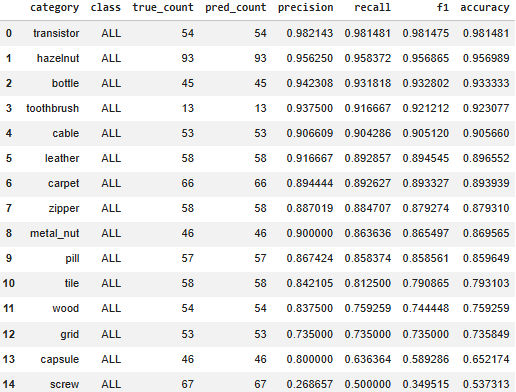

Die meisten IO/NIO Klassifikatoren haben gute Ergebnisse. Negativ sticht vor allem die Schraube und die Pille heraus.

#### 5.2.12.3 Ensemble

Das Kategorie Modell findet sich [hier](https://drive.google.com/file/d/1B94yhHx2SJVVcEqCEdUBrJwt0q4Mn0Rf/view?usp=sharing).

Die NIO/IO Modelle fidnen sich [hier](https://drive.google.com/file/d/1G8xwKwnqIZ90sJQY1vqwiQeP3d0wqXXe/view?usp=sharing).

In [ ]:
import numpy as np

class CatThenIOEnsemble:
    def __init__(self, category_model, io_nio_models, categories):
        self.category_model = category_model
        # io_nio_models: dict {"bottle": model, "capsule": model, ...}
        self.io_nio_models = io_nio_models

        # List of categories in same order as category_model output
        self.categories = categories

    def predict(self, images, verbose=0):
        # [image1, image2] => [ [0.5, 0.1, 0.1, ... ], [0.5, 0.1, 0.1, ...]]
        category_probs = self.category_model.predict(images, verbose=verbose)
        category_ids = np.argmax(category_probs, axis=1)  # Input [Image1, Image2, Image3] => [0, 4, 2] (category ids)

        # [ bottle_io, botte_nio, dable_io, cable_nio, ... ... ]
        output = np.zeros((len(images), 30), dtype=np.float32)

        for i, category_id in enumerate(category_ids):
          # Get Category name => Get model => Predict
          category_name = self.categories[int(category_id)]
          io_nio = self.io_nio_models[category_name].predict(images[i:i+1], verbose=verbose)[0]  # [IO, NIO]

          # e.g. cable_nio => Category id 1 => 2*1 = 2
          # place 2 for IO, place 3 for NIO
          start = 2 * int(category_id)
          output[i, start] = io_nio[0]      # IO
          output[i, start + 1] = io_nio[1]  # NIO

        return output

In [ ]:
CLASS_NAMES_30 = []
for cat in CATEGORIES:
    CLASS_NAMES_30 += [f"{cat}_IO", f"{cat}_NIO"]


In [ ]:
model_category = import_model(
    "https://drive.google.com/file/d/1B94yhHx2SJVVcEqCEdUBrJwt0q4Mn0Rf/view?usp=sharing",
    "simple_cnn_category_only_bundle")

In [ ]:
ensemble = CatThenIOEnsemble(model_category, io_models, CATEGORIES)

df_ens = eval(
    ensemble,
    "data/data_augmented_split/val",
    class_names=CLASS_NAMES_30
)
df_ens

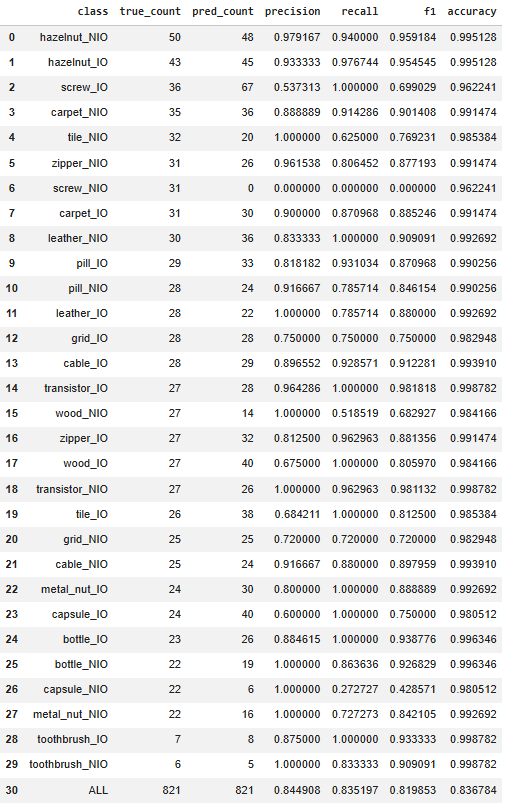

Evaluationswerte: (werden in Kapitel 5.2.14 besprochen)

In [ ]:
ensemble = CatThenIOEnsemble(model_category, io_models, CATEGORIES)

df_ens = eval(
    ensemble,
    "data/data_augmented_split/test",
    class_names=CLASS_NAMES_30
)
df_ens

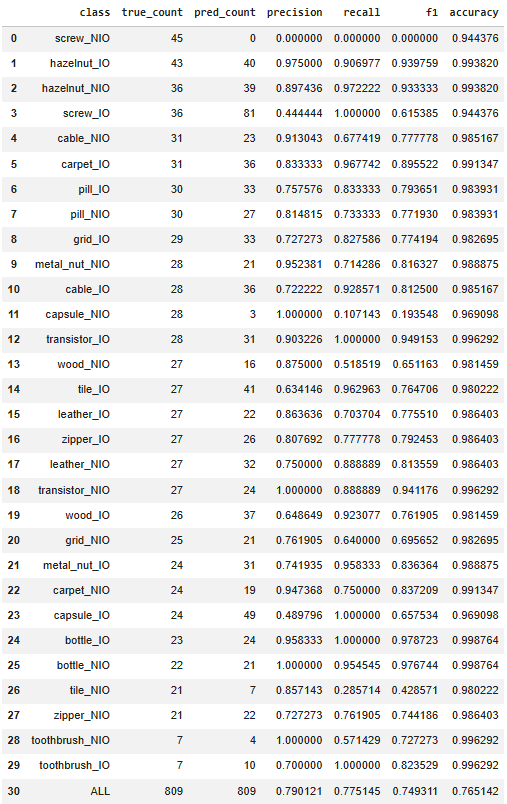

### 5.2.13 Variation B: 2 Head-Classifier

Wie beim Classifier-Ensemble (Variante A) ist die Grundidee, dem `simple_cnn` explizit die Struktur des Problems mitzugeben: Die 30 Klassen lassen sich als Kombination aus 15 Kategorien und dem Zustand IO/NIO darstellen. Statt jedoch zuerst eine Kategorie zu bestimmen und danach ein separates Modell pro Kategorie anzuwenden, lösen wir beide Teilaufgaben gleichzeitig innerhalb eines einzigen Netzes.

Der Ansatz folgt dem Prinzip des Multi-Task Learning. Wir verwenden einen gemeinsamen Backbone, während zwei getrennte Heads klassifizieren. Das Training erfolgt gegen 2 Fehlerfunktionen. Eine für die Kategorie-Klassifikation und eine für die IO/NIO-Klassifikation.

Nach dem trainieren des Modells, werden wir auch hier wieder ein kleines "Pseudomodell" erstellen. Die Aufgabe des Pseudomodells ist es hier die zwei vereinzelten Ausgaben der Heads zu dem regulären 30er Outputformat zu transformieren.

#### 5.2.13.1 Modell

Der Backbone des Modells ist identisch zu unserem ursprünglichen `simple_cnn` Modell aufgebaut. Der Unterschied sind nun die zwei Dense Layer, welche unsere Outputs bereitstellen.

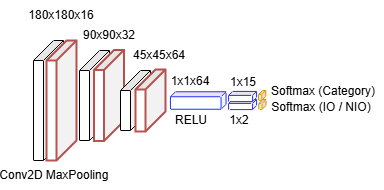

In [ ]:
from tensorflow import keras
from keras import layers

def make_simple_cnn_two_heads(input_shape=(180, 180, 3), num_categories=15):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0/255)(inputs)

    # Backbone
    x = layers.Conv2D(filters=16, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)

    x = layers.Conv2D(filters=32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)

    x = layers.Conv2D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Heads
    category_out = layers.Dense(num_categories, activation="softmax", name="category")(x)
    quality_out = layers.Dense(2, activation="softmax", name="io")(x)

    model = keras.Model(inputs, [category_out, quality_out], name="simple_cnn_two_heads")
    return model

#### 5.2.13.2 Train-Pipeline

Für das Training müssen wir die Methode aus 5.1.1 anpassen um aus der 30er Klassifikation eine (15, 2) Klassifikation zu machen.
Damit wir die Implementierung dort nicht komplexer machen, haben wir diese folgend neu definiert für die Two-Head Classification angepasst.

In [ ]:
from dataclasses import dataclass
from typing import Dict, Optional
import numpy as np
import tensorflow as tf
from tensorflow import keras

@dataclass
class TrainInput:
    data_dir: str
    model: tf.keras.Model
    batch_size: int = 32
    seed: int = 42
    epochs: int = 50
    class_weight: Optional[Dict[int, float]] = None
    tensorboard_logdir: Optional[str] = None
    callback_metric: str = "val_loss"

@dataclass
class TrainOutput:
    model: tf.keras.Model
    hist: keras.callbacks.History

def split_label(image, y30):
    y_category = y30 // 2   # 0..14 => Immer eines Skippen => bottle, capsule
    y_io       = y30 % 2    # 0..1  => Jedes 2. IO, NIO, IO, NIO
    return image, {"category": y_category, "io": y_io}

def train_2heads(inp: TrainInput) -> TrainOutput:
    tf.keras.utils.set_random_seed(inp.seed)

    #Required to set, as we need the ordering for split_label
    CLASS_NAMES = [
      "bottle_IO",      "bottle_NIO",
      "capsule_IO",     "capsule_NIO",
      "grid_IO",        "grid_NIO",
      "leather_IO",     "leather_NIO",
      "pill_IO",        "pill_NIO",
      "tile_IO",        "tile_NIO",
      "transistor_IO",  "transistor_NIO",
      "zipper_IO",      "zipper_NIO",
      "cable_IO",       "cable_NIO",
      "carpet_IO",      "carpet_NIO",
      "hazelnut_IO",    "hazelnut_NIO",
      "metal_nut_IO",   "metal_nut_NIO",
      "screw_IO",       "screw_NIO",
      "toothbrush_IO",  "toothbrush_NIO",
      "wood_IO",        "wood_NIO",
    ]

    training_train_tensor = tf.keras.utils.image_dataset_from_directory(
        inp.data_dir+"/train",
        class_names=CLASS_NAMES,
        seed=inp.seed,
        image_size=(180, 180),
        batch_size=inp.batch_size)

    training_eval_tensor = tf.keras.utils.image_dataset_from_directory(
        inp.data_dir+"/val",
        class_names=CLASS_NAMES,
        seed=inp.seed,
        image_size=(180, 180),
        batch_size=inp.batch_size)

    training_train_tensor = training_train_tensor.map(split_label, num_parallel_calls=tf.data.AUTOTUNE)
    training_eval_tensor  = training_eval_tensor.map(split_label, num_parallel_calls=tf.data.AUTOTUNE)

    callbacks = [
        # Stops earlier than specified epochs, when no longer a
        # significant improve on 'val_loss' occurs for 10 epochs
        keras.callbacks.EarlyStopping(
            monitor=inp.callback_metric,
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        # Saves the best model based on val_loss
        keras.callbacks.ModelCheckpoint(
            f"{inp.model.name}.keras",
            monitor=inp.callback_metric,
            save_best_only=True
        ),
        # Reduces learning rate when a val_loss has stopped improving.
        keras.callbacks.ReduceLROnPlateau(
            monitor=inp.callback_metric,
            factor=0.1,
            patience=5,
            verbose=1
        )
    ]

    if inp.tensorboard_logdir:
        callbacks.append(
            keras.callbacks.TensorBoard(
                log_dir=inp.tensorboard_logdir,
                histogram_freq=0,
                write_graph=True)
            )


    hist = inp.model.fit(
        training_train_tensor,
        validation_data=training_eval_tensor,
        epochs=inp.epochs,
        callbacks=callbacks,
        verbose=1,
        class_weight=inp.class_weight,  # When none => ignored
    )

    return TrainOutput(
        model=inp.model,
        hist=hist)

#### 5.2.13.3 Training

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_simple_cnn_two_heads()
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss={"category": "sparse_categorical_crossentropy", "io": "sparse_categorical_crossentropy"},
    metrics={"category": ["accuracy"], "io": ["accuracy"]},
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir="logs/simple_cnn_two_heads"
)

out = train_2heads(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs,

)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - category_accuracy: 0.6095 - category_loss: 1.2848 - io_accuracy: 0.4947 - io_loss: 0.8034 - loss: 2.0882 - val_category_accuracy: 0.9294 - val_category_loss: 0.1032 - val_io_accuracy: 0.5664 - val_io_loss: 0.6842 - val_loss: 0.7883 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - category_accuracy: 0.9497 - category_loss: 0.1481 - io_accuracy: 0.5813 - io_loss: 0.6979 - loss: 0.8461 - val_category_accuracy: 0.9976 - val_category_loss: 0.0081 - val_io_accuracy: 0.5652 - val_io_loss: 0.6693 - val_loss: 0.6774 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - category_accuracy: 0.9678 - category_loss: 0.0922 - io_accuracy: 0.5903 - io_loss: 0.6594 - loss: 0.7516 - val_category_accuracy: 0.9988 - val_category_loss: 0.0044 - val_io_accuracy: 0.5798 - val_io_loss: 0.6504 - val_loss: 0.6551 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - category_accuracy: 0.9662 - category_loss: 0.0888 - io_accuracy: 0.5831 - io_loss: 0.6551 - loss: 0.7439 - val_category_accuracy: 0.9951 - val_category_loss: 0.0121 - val_io_accuracy: 0.6346 - val_io_loss: 0.6204 - val_loss: 0.6325 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - category_accuracy: 0.9799 - category_loss: 0.0611 - io_accuracy: 0.6187 - io_loss: 0.6240 - loss: 0.6851 - val_category_accuracy: 0.9951 - val_category_loss: 0.0106 - val_io_accuracy: 0.6663 - val_io_loss: 0.6001 - val_loss: 0.6098 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - category_accuracy: 0.9838 - category_loss: 0.0520 - io_accuracy: 0.6155 - io_loss: 0.6138 - loss: 0.6658 - val_category_accuracy: 1.0000 - val_category_loss: 0.0029 - val_io_accuracy: 0.6285 - val_io_loss: 0.5826 - val_loss: 0.5856 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - category_accuracy: 0.9811 - category_loss: 0.0514 - io_accuracy: 0.6470 - io_loss: 0.5902 - loss: 0.6416 - val_category_accuracy: 0.9951 - val_category_loss: 0.0246 - val_io_accuracy: 0.6163 - val_io_loss: 0.5789 - val_loss: 0.6047 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - category_accuracy: 0.9876 - category_loss: 0.0406 - io_accuracy: 0.6518 - io_loss: 0.5885 - loss: 0.6291 - val_category_accuracy: 1.0000 - val_category_loss: 0.0013 - val_io_accuracy: 0.6590 - val_io_loss: 0.5650 - val_loss: 0.5655 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - category_accuracy: 0.9830 - category_loss: 0.0529 - io_accuracy: 0.6965 - io_loss: 0.5384 - loss: 0.5913 - val_category_accuracy: 1.0000 - val_category_loss: 0.0014 - val_io_accuracy: 0.6894 - val_io_loss: 0.5326 - val_loss: 0.5336 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - category_accuracy: 0.9778 - category_loss: 0.0667 - io_accuracy: 0.6937 - io_loss: 0.5283 - loss: 0.5951 - val_category_accuracy: 1.0000 - val_category_loss: 4.2855e-04 - val_io_accuracy: 0.6675 - val_io_loss: 0.5426 - val_loss: 0.5443 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - category_accuracy: 0.9852 - category_loss: 0.0407 - io_accuracy: 0.7168 - io_loss: 0.4987 - loss: 0.5395 - val_category_accuracy: 0.9951 - val_category_loss: 0.0244 - val_io_accuracy: 0.6529 - val_io_loss: 0.6169 - val_loss: 0.6405 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - category_accuracy: 0.9835 - category_loss: 0.0516 - io_accuracy: 0.7185 - io_loss: 0.4961 - loss: 0.5478 - val_category_accuracy: 1.0000 - val_category_loss: 0.0011 - val_io_accuracy: 0.7442 - val_io_loss: 0.4873 - val_loss: 0.4876 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - category_accuracy: 0.9820 - category_loss: 0.0480 - io_accuracy: 0.7602 - io_loss: 0.4496 - loss: 0.4976 - val_category_accuracy: 0.9951 - val_category_loss: 0.0104 - val_io_accuracy: 0.7223 - val_io_loss: 0.4988 - val_loss: 0.5099 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - category_accuracy: 0.9832 - category_loss: 0.0463 - io_accuracy: 0.7700 - io_loss: 0.4440 - loss: 0.4902 - val_category_accuracy: 0.9951 - val_category_loss: 0.0263 - val_io_accuracy: 0.7113 - val_io_loss: 0.5194 - val_loss: 0.5462 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - category_accuracy: 0.9874 - category_loss: 0.0409 - io_accuracy: 0.7763 - io_loss: 0.4294 - loss: 0.4702 - val_category_accuracy: 0.9951 - val_category_loss: 0.0289 - val_io_accuracy: 0.7454 - val_io_loss: 0.5059 - val_loss: 0.5358 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - category_accuracy: 0.9857 - category_loss: 0.0466 - io_accuracy: 0.7799 - io_loss: 0.4175 - loss: 0.4641 - val_category_accuracy: 0.9951 - val_category_loss: 0.0258 - val_io_accuracy: 0.7308 - val_io_loss: 0.4706 - val_loss: 0.4980 - learning_rate: 0.0010
Epoch 17/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - category_accuracy: 0.9885 - category_loss: 0.0331 - io_accuracy: 0.8070 - io_loss: 0.3786 - loss: 0.4117
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - category_accuracy: 0.9885 - category_loss: 0.0332 - io_accuracy: 0.8070 - io_loss: 0.3786 - loss: 0.4117 - val_category_accuracy: 0.9951 - val_category_loss: 0.0093 - val_io_accuracy: 0.7211 - val_io_loss: 0.5052 - val_loss: 0.5177 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - category_accuracy: 0.9838 - category_loss: 0.0450 - io_accuracy: 0.8256 - io_loss: 0.3637 - loss: 0.4088 - val_category_accuracy: 0.9951 - val_category_loss: 0.0054 - val_io_accuracy: 0.7905 - val_io_loss: 0.4548 - val_loss: 0.4612 - learning_rate: 1.0000e-04
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - category_accuracy: 0.9853 - category_loss: 0.0361 - io_accuracy: 0.8520 - io_loss: 0.3174 - loss: 0.3535 - val_category_accuracy: 0.9951 - val_category_loss: 0.0070 - val_io_accuracy: 0.7881 - val_io_loss: 0.4476 - val_loss: 0.4539 - learning_rate: 1.0000e-04
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - category_accuracy: 0.9849 - category_loss: 0.0419 - io_accuracy: 0.8421 - io_loss: 0.3205 - loss: 0.3624 - val_category_accuracy: 1.0000 - val_category_loss: 0.0015 - val_io_accuracy: 0.7954 - val_io_loss: 0.4386 - val_loss: 0.4410 - learning_rate: 1.0000e-04
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - category_accuracy: 0.9884 - category_loss: 0.0354 - io_accuracy: 0.8571 - io_loss: 0.2966 - loss: 0.3320 - val_category_accuracy: 0.9951 - val_category_loss: 0.0068 - val_io_accuracy: 0.7990 - val_io_loss: 0.4320 - val_loss: 0.4366 - learning_rate: 1.0000e-04
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - category_accuracy: 0.9878 - category_loss: 0.0342 - io_accuracy: 0.8577 - io_loss: 0.2929 - loss: 0.3271 - val_category_accuracy: 0.9951 - val_category_loss: 0.0067 - val_io_accuracy: 0.7917 - val_io_loss: 0.4435 - val_loss: 0.4518 - learning_rate: 1.0000e-04
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - category_accuracy: 0.9878 - category_loss: 0.0316 - io_accuracy: 0.8669 - io_loss: 0.2850 - loss: 0.3166 - val_category_accuracy: 1.0000 - val_category_loss: 0.0031 - val_io_accuracy: 0.7966 - val_io_loss: 0.4427 - val_loss: 0.4430 - learning_rate: 1.0000e-04
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - category_accuracy: 0.9866 - category_loss: 0.0423 - io_accuracy: 0.8734 - io_loss: 0.2759 - loss: 0.3182 - val_category_accuracy: 1.0000 - val_category_loss: 0.0017 - val_io_accuracy: 0.7966 - val_io_loss: 0.4436 - val_loss: 0.4462 - learning_rate: 1.0000e-04
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - category_accuracy: 0.9846 - category_loss: 0.0383 - io_accuracy: 0.8598 - io_loss: 0.2871 - loss: 0.3253 - val_category_accuracy: 1.0000 - val_category_loss: 0.0012 - val_io_accuracy: 0.7649 - val_io_loss: 0.4810 - val_loss: 0.4815 - learning_rate: 1.0000e-04
Epoch 26/30
203/206 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - category_accuracy: 0.9861 - category_loss: 0.0403 - io_accuracy: 0.8578 - io_loss: 0.2974 - loss: 0.3377
Epoch 26: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - category_accuracy: 0.9861 - category_loss: 0.0403 - io_accuracy: 0.8579 - io_loss: 0.2971 - loss: 0.3373 - val_category_accuracy: 1.0000 - val_category_loss: 1.7194e-04 - val_io_accuracy: 0.8039 - val_io_loss: 0.4550 - val_loss: 0.4520 - learning_rate: 1.0000e-04
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - category_accuracy: 0.9900 - category_loss: 0.0372 - io_accuracy: 0.8698 - io_loss: 0.2635 - loss: 0.3007 - val_category_accuracy: 1.0000 - val_category_loss: 1.8320e-04 - val_io_accuracy: 0.8100 - val_io_loss: 0.4523 - val_loss: 0.4494 - learning_rate: 1.0000e-05
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - category_accuracy: 0.9864 - category_loss: 0.0396 - io_accuracy: 0.8790 - io_loss: 0.2627 - loss: 0.3023 - val_category_accuracy: 1.0000 - val_category_loss: 3.6227e-04 - val_io_accuracy: 0.8100 - val_io_loss: 0.4440 - val_loss: 0.4458 - learning_rate: 1.0000e-05
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - category_accuracy: 0.9859 - category_loss: 0.0352 - io_accuracy: 0.8755 - io_loss: 0.2619 - loss: 0.2971 - val_category_accuracy: 1.0000 - val_category_loss: 1.6574e-04 - val_io_accuracy: 0.8088 - val_io_loss: 0.4510 - val_loss: 0.4474 - learning_rate: 1.0000e-05
Epoch 30/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - category_accuracy: 0.9868 - category_loss: 0.0365 - io_accuracy: 0.8856 - io_loss: 0.2542 - loss: 0.2906 - val_category_accuracy: 1.0000 - val_category_loss: 1.9530e-04 - val_io_accuracy: 0.8063 - val_io_loss: 0.4409 - val_loss: 0.4448 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 21.
Exported: export/simple_cnn_two_heads_bundle.zip

```



In [ ]:
model = import_model(
    "https://drive.google.com/file/d/17QiKR-6pltuogsZplfrfhKfWxvyqc6cp/view?usp=sharing",
    "simple_cnn_two_heads_bundle")

#### 5.2.13.4 2 Head-Classifier Wrapper

In [ ]:
import numpy as np

categories = [
  "bottle",
  "capsule",
  "grid",
  "leather",
  "pill",
  "tile",
  "transistor",
  "zipper",
  "cable",
  "carpet",
  "hazelnut",
  "metal_nut",
  "screw",
  "toothbrush",
  "wood",
]

CLASS_NAMES_30 = [
      "bottle_IO",      "bottle_NIO",
      "capsule_IO",     "capsule_NIO",
      "grid_IO",        "grid_NIO",
      "leather_IO",     "leather_NIO",
      "pill_IO",        "pill_NIO",
      "tile_IO",        "tile_NIO",
      "transistor_IO",  "transistor_NIO",
      "zipper_IO",      "zipper_NIO",
      "cable_IO",       "cable_NIO",
      "carpet_IO",      "carpet_NIO",
      "hazelnut_IO",    "hazelnut_NIO",
      "metal_nut_IO",   "metal_nut_NIO",
      "screw_IO",       "screw_NIO",
      "toothbrush_IO",  "toothbrush_NIO",
      "wood_IO",        "wood_NIO",
]

class TwoHeadTo30:
    def __init__(self, two_head_model, categories):
        self.m = two_head_model
        self.categories = categories

    def predict(self, images, verbose=0):
        probability_category, probability_io_nio = self.m.predict(images, verbose=verbose)  # (B,15), (B,2)

        category_id = np.argmax(probability_category, axis=1)  # (B,)
        probability_30_classes = np.zeros((len(images), 30), dtype=np.float32)

        for image_index, predicted_category_id in enumerate(category_id):
            io_index  = 2 * int(predicted_category_id)
            nio_index = io_index + 1

            probability_30_classes[image_index, io_index]  = probability_io_nio[image_index, 0]
            probability_30_classes[image_index, nio_index] = probability_io_nio[image_index, 1]

        return probability_30_classes

In [ ]:
wrapped = TwoHeadTo30(model, categories)

In [ ]:
df = eval(wrapped, "data/data_augmented_split/val", batch_size=32, seed=43, class_names=CLASS_NAMES_30)
df

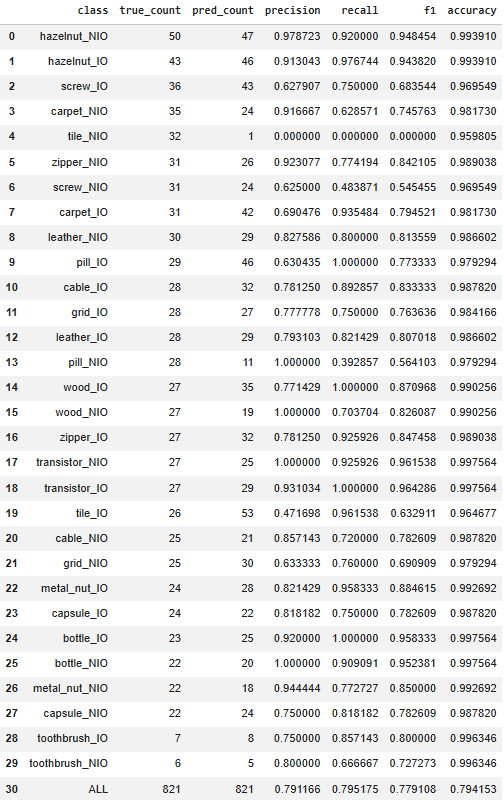

Evaluationswerte: (werden in Kapitel 5.2.14 besprochen)

In [ ]:
df = eval(wrapped, "data/data_augmented_split/test", batch_size=32, seed=43, class_names=CLASS_NAMES_30)
df

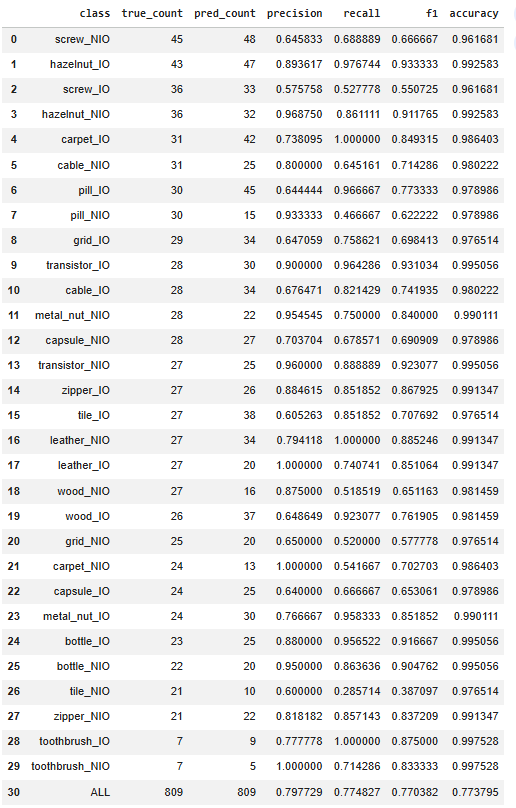

### 5.2.14 Evaluation

In diesem Kapitel machen wir einen kleinen Vergleich des getunten Modells mit den 2 alterantiven Varianten. Unten sind die Evaluationstabellen der Modelle gegen den Test-Datensatz abgebildet.

**Getuntes Modell** Evaluationswerte

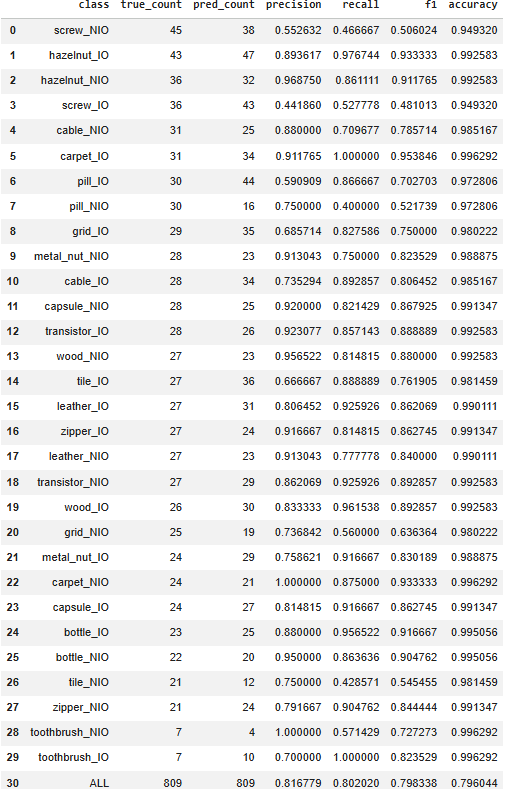

**Ensemble**
Evaluationswerte

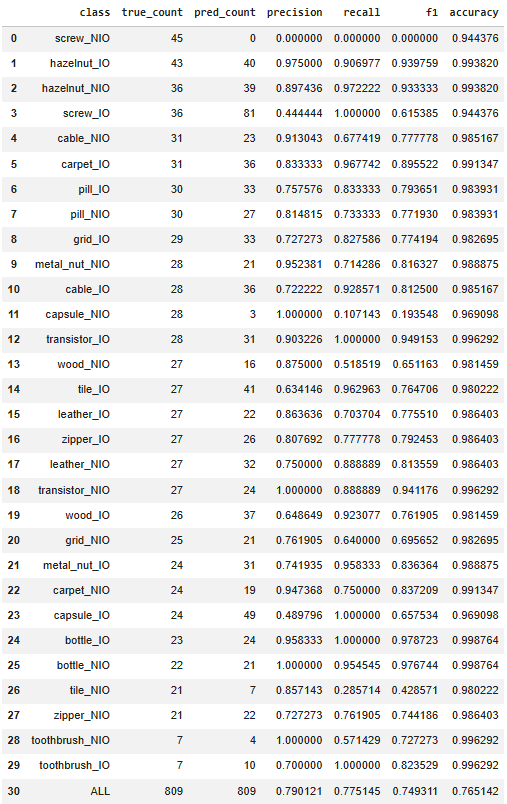

**2 Head Classifier** Evaluationswerte

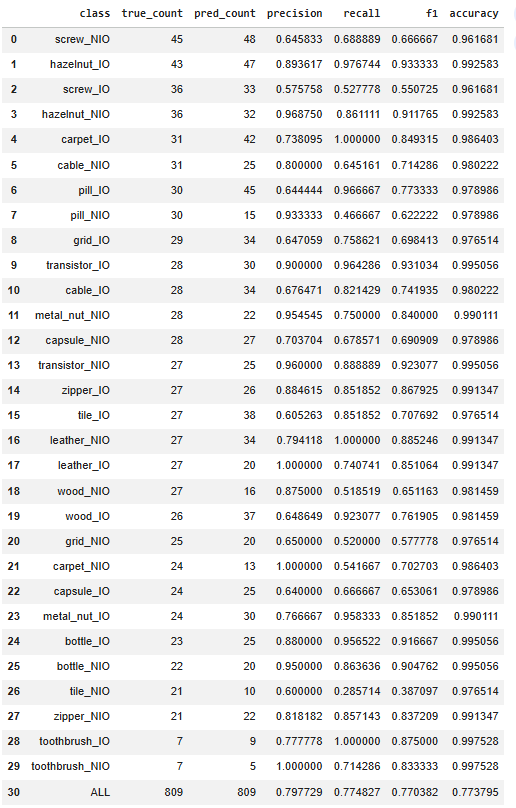

Insgesamt haben alle 3 Modelle sinnvolle Ergebnisse geliefert.

Der F1-Score über Evaluationsdaten ist beim getunten Modell und beim 2 Head-Classifier nahezu identisch mit dem F1-Score der Validierungsdaten. Nur beim Ensemble gibt es eine deutlichere Abweichung  im F1-Score. Dieser ist bei den Evaluationswerten um 0.07 Punkten niedriger, was auf leichtes Overfitting hinweist.

Fast alle Modelle können die verschiedenen Kategorien sauber unterteilen. Eine Ausnahme bilden folgende Klassen:
- capsule und screw bei dem Ensemble
- tile bei dem 2 Head Classifier
- screw bei dem getunten Modell

Diese Klassen wurden mit einem F1-Score von < 0.5 vorhergesagt.
Die Performance der Modelle ist vernachlässigbar ähnlich zueinander, wobei anzumerken ist, dass bei der Ensemble Varation und bei der 2 Head Classifier Varation noch kein Tuning erfolgt ist.

<a name="pretrained"></a>
## 5.3 Experiments - Transfer learning on pretrained Models

---

**Zusammenfassung des Learnigpfads:**

Insgesamt zeigt sich, wie vermutet, das Transfer Learning mit vortraintierten Modellen deutlich bessere Ergebnisse liefern als die selbst von Scratch trainierten Modelle.

Wir haben mehre Backbones mit mehren Heads kombiniert. Heads schienen für unseren Use-Case eine größere Rolle zu spielen. Die beste Kombination war der MobileNetV3Small Backbone mit dem "Direct" Head, welcher aus nur einem Output-Layer besteht.

Durch Fine-Tuning des Modells konnten wir die Performance noch etwas erhöhen.

Unsere Performancemetrik, der F1-Score, ist auf dem Evaluationsdaten ähnlich gut, wie auf dem Validierungsdaten.

Die Konfusionsmatrix zeigt, dass das Modell die IO/NIOs der Kategorien Pill, Grid und Transistor noch etwas durcheinander bringt.

---

Referenzen für diesen Lernpfad:

https://www.tensorflow.org/api_docs/python/tf/keras/applications

https://keras.io/guides/transfer_learning/

### 5.3.1 Pretrained Mobile Net V3 Small

#### 5.3.1.1 Direct classification

In [ ]:
import keras
from keras import layers

def make_mobilenetv3_small_050(num_classes=30, image_size=(180, 180), dropout: float = 0.3) -> keras.Model:
    inputs = keras.Input(shape=image_size + (3,))

    x = keras.applications.mobilenet_v3.preprocess_input(inputs)

    base = keras.applications.MobileNetV3Small(
        input_shape=image_size + (3,),
        include_top=False,
        weights="imagenet",
        pooling="avg",      # Makes GlobalAveragePooling intern e.g. height and width dimensions are gone
    )
    base.trainable = False

    x = base(x, training=False)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="mobilenetv3_small_050_simple")


In [ ]:
import keras
from keras import layers

lr = 1e-3
epochs = 30
seed = 43

model = make_mobilenetv3_small_050()
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir="logs/mobilenetv3_small_050",
    callback_metric="val_accuracy"
)

out = train(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs,

)
zip_path = export_model(run)
print("Exported:", zip_path)

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1SRhdjAXfVGbhHg5RuAfUcLy9pG0r5uw0/view?usp=sharing",
    "mobilenetv3_small_050_simple_bundle")

In [ ]:
df = eval(model, "data/data_augmented_split/val", batch_size=32, seed=43)
df

In [ ]:
df = eval(model, "data/data_augmented_split/test", batch_size=32, seed=43)
df

#### 5.3.1.2 One Hidden Layer

In [ ]:
import keras
from keras import layers

def make_mobilenetv3_small_050(num_classes=30, image_size=(180, 180), dropout: float = 0.3) -> keras.Model:
    inputs = keras.Input(shape=image_size + (3,))

    x = keras.applications.mobilenet_v3.preprocess_input(inputs)

    base = keras.applications.MobileNetV3Small(
        input_shape=image_size + (3,),
        include_top=False,
        weights="imagenet",
        pooling="avg",
    )
    base.trainable = False

    x = base(x, training=False)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="mobilenetv3_small_050_one_dense")


In [ ]:
import keras
from keras import layers

lr = 1e-3
epochs = 30
seed = 43

model = make_mobilenetv3_small_050()
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir="logs/mobilenetv3_small_050",
    callback_metric="val_accuracy"
)

out = train(inp)

run = dict(
    name=out.model.name,
    model=out.model,
    model_name=out.model.name,
    lr=lr,
    seed=seed,
    epochs=epochs,

)
zip_path = export_model(run)
print("Exported:", zip_path)

In [ ]:
df = eval(model, "data/data_augmented_split/val", batch_size=32, seed=43)
df

In [ ]:
df = eval(model, "data/data_augmented_split/test", batch_size=32, seed=43)
df

### 5.3.2 Combining pretrainted modells and heads

#### 5.3.2.1 Head Collection

In [ ]:
from tensorflow import keras
from keras import layers

def head_direct(x, num_classes: int = 30, dropout: float = 0.3):
    x = layers.Dropout(dropout)(x)
    return layers.Dense(num_classes, activation="softmax", name="category")(x)

In [ ]:
from tensorflow import keras
from keras import layers

def head_dense(x, num_classes: int = 30, dropout: float = 0.3):
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    return layers.Dense(num_classes, activation="softmax", name="category")(x)

In [ ]:
from tensorflow import keras
from keras import layers

def head_two_tasks(x,
                   num_categories: int = 30,
                   num_io: int = 2,
                   dropout: float = 0.3,
                   l2: float = 0.0):
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)

    category_out = layers.Dense(num_categories, activation="softmax", name="category")(x)
    io_out = layers.Dense(num_io, activation="softmax", name="io")(x)
    return [category_out, io_out]

In [ ]:
def build_head(x, head_type: str):
    if head_type == "direct":
        return head_direct(x)

    if head_type == "dense":
        return head_dense(x)

    if head_type == "two_tasks":
        return head_two_tasks(x)


#### 5.3.2.2 Pretrained Modell Collection

In [ ]:
from tensorflow import keras

def make_premodel(backbone: str,
                  head_type="direct",
                  image_size=(180, 180)) -> keras.Model:

    inputs = keras.Input(shape=image_size + (3,), name="image")

    if backbone == "mobilenetv3small":
        x = keras.applications.mobilenet_v3.preprocess_input(inputs)
        base = keras.applications.MobileNetV3Small(
            include_top=False,
            weights="imagenet",
            input_shape=image_size + (3,),
            pooling="avg"
        )

    elif backbone == "xception":
        x = keras.applications.xception.preprocess_input(inputs)
        base = keras.applications.Xception(
            include_top=False,
            weights="imagenet",
            input_shape=image_size + (3,),
            pooling="avg"
        )

    elif backbone == "vgg16":
        x = keras.applications.vgg16.preprocess_input(inputs)
        base = keras.applications.VGG16(
            include_top=False,
            weights="imagenet",
            input_shape=image_size + (3,),
            pooling="avg"
        )

    base.trainable = False
    x = base(x, training=False)

    outputs = build_head(
        x,
        head_type=head_type
    )

    name = f"{backbone}_{head_type}"
    return keras.Model(inputs, outputs, name=name)


#### 5.3.2.3 Training

##### MobileNetV3Small-Backbone x Direct-Head

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_premodel("mobilenetv3small", "direct")
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}",
    callback_metric="val_accuracy"
)

out = train(inp)

run = dict(name=out.model.name, model=out.model, model_name=out.model.name, lr=lr, seed=seed, epochs=epochs)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.4197 - loss: 1.7900 - val_accuracy: 0.7138 - val_loss: 0.5672 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7034 - loss: 0.5989 - val_accuracy: 0.7637 - val_loss: 0.4634 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7533 - loss: 0.5065 - val_accuracy: 0.7954 - val_loss: 0.4263 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7805 - loss: 0.4453 - val_accuracy: 0.8246 - val_loss: 0.3872 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.7977 - loss: 0.4134 - val_accuracy: 0.8404 - val_loss: 0.3649 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8234 - loss: 0.3815 - val_accuracy: 0.8246 - val_loss: 0.3555 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8265 - loss: 0.3679 - val_accuracy: 0.8611 - val_loss: 0.3285 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8465 - loss: 0.3387 - val_accuracy: 0.8404 - val_loss: 0.3378 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8427 - loss: 0.3327 - val_accuracy: 0.8636 - val_loss: 0.3179 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8585 - loss: 0.3201 - val_accuracy: 0.8587 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8673 - loss: 0.3038 - val_accuracy: 0.8782 - val_loss: 0.2961 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8542 - loss: 0.3182 - val_accuracy: 0.8879 - val_loss: 0.2849 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8721 - loss: 0.2964 - val_accuracy: 0.8794 - val_loss: 0.2884 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8740 - loss: 0.2910 - val_accuracy: 0.8599 - val_loss: 0.2924 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8796 - loss: 0.2841 - val_accuracy: 0.8660 - val_loss: 0.2805 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8754 - loss: 0.2803 - val_accuracy: 0.8721 - val_loss: 0.2835 - learning_rate: 0.0010
Epoch 17/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8761 - loss: 0.2865 - val_accuracy: 0.8965 - val_loss: 0.2760 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8852 - loss: 0.2657 - val_accuracy: 0.8733 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8840 - loss: 0.2629 - val_accuracy: 0.8733 - val_loss: 0.2726 - learning_rate: 0.0010
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8861 - loss: 0.2566 - val_accuracy: 0.8660 - val_loss: 0.2718 - learning_rate: 0.0010
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8908 - loss: 0.2512 - val_accuracy: 0.8831 - val_loss: 0.2624 - learning_rate: 0.0010
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8912 - loss: 0.2483
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.8912 - loss: 0.2483 - val_accuracy: 0.8892 - val_loss: 0.2557 - learning_rate: 0.0010
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9087 - loss: 0.2293 - val_accuracy: 0.9001 - val_loss: 0.2442 - learning_rate: 1.0000e-04
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.8999 - loss: 0.2320 - val_accuracy: 0.9062 - val_loss: 0.2447 - learning_rate: 1.0000e-04
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9040 - loss: 0.2302 - val_accuracy: 0.9086 - val_loss: 0.2439 - learning_rate: 1.0000e-04
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9097 - loss: 0.2338 - val_accuracy: 0.9062 - val_loss: 0.2436 - learning_rate: 1.0000e-04
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9021 - loss: 0.2315 - val_accuracy: 0.9013 - val_loss: 0.2439 - learning_rate: 1.0000e-04
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9070 - loss: 0.2300 - val_accuracy: 0.9074 - val_loss: 0.2448 - learning_rate: 1.0000e-04
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9134 - loss: 0.2210 - val_accuracy: 0.9086 - val_loss: 0.2434 - learning_rate: 1.0000e-04
Epoch 30/30
202/206 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8993 - loss: 0.2287
Epoch 30: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8995 - loss: 0.2287 - val_accuracy: 0.9050 - val_loss: 0.2418 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 25.
Exported: export/mobilenetv3small_direct_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/18FVBX1Bm6kIrs8KDFqa-3ldUvGUtNwr_/view?usp=sharing",
    "mobilenetv3small_direct_bundle")

df = eval(model, "data/data_augmented_split/val")
df

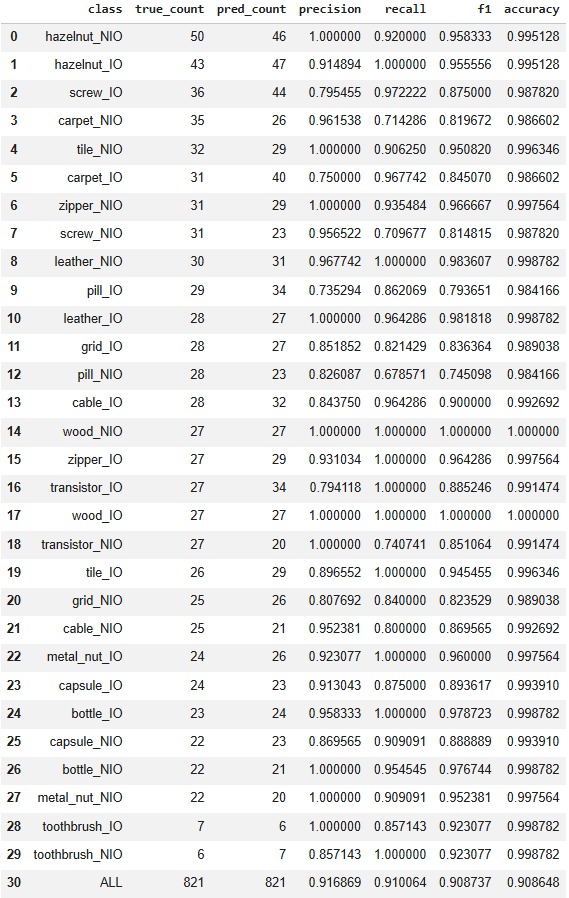

##### MobileNetV3Small-Backbone x Dense-Head

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_premodel("mobilenetv3small", "dense")
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}",
    callback_metric="val_accuracy",
)

out = train(inp)

run = dict(name=out.model.name, model=out.model, model_name=out.model.name, lr=lr, seed=seed, epochs=epochs)
zip_path = export_model(run)
print("Exported:", zip_path)


<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.4089 - loss: 1.8569 - val_accuracy: 0.6577 - val_loss: 0.5982 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.6912 - loss: 0.5926 - val_accuracy: 0.7320 - val_loss: 0.4676 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7263 - loss: 0.5161 - val_accuracy: 0.7576 - val_loss: 0.4450 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7574 - loss: 0.4645 - val_accuracy: 0.7820 - val_loss: 0.4334 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7698 - loss: 0.4465 - val_accuracy: 0.7942 - val_loss: 0.4133 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7727 - loss: 0.4430 - val_accuracy: 0.7844 - val_loss: 0.4049 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7873 - loss: 0.4215 - val_accuracy: 0.8417 - val_loss: 0.3496 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8048 - loss: 0.3957 - val_accuracy: 0.8015 - val_loss: 0.3833 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7967 - loss: 0.4116 - val_accuracy: 0.8283 - val_loss: 0.3354 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8103 - loss: 0.3830 - val_accuracy: 0.8392 - val_loss: 0.3271 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8077 - loss: 0.3805 - val_accuracy: 0.8551 - val_loss: 0.3360 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8076 - loss: 0.4120 - val_accuracy: 0.8575 - val_loss: 0.3287 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8207 - loss: 0.3721 - val_accuracy: 0.8465 - val_loss: 0.3275 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8268 - loss: 0.3543 - val_accuracy: 0.8210 - val_loss: 0.3646 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8255 - loss: 0.3690 - val_accuracy: 0.8465 - val_loss: 0.3286 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8260 - loss: 0.3680 - val_accuracy: 0.8514 - val_loss: 0.3178 - learning_rate: 0.0010
Epoch 17/30
203/206 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8329 - loss: 0.3618
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8330 - loss: 0.3614 - val_accuracy: 0.8502 - val_loss: 0.3280 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8556 - loss: 0.3170 - val_accuracy: 0.8782 - val_loss: 0.2858 - learning_rate: 1.0000e-04
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8621 - loss: 0.2991 - val_accuracy: 0.8733 - val_loss: 0.2846 - learning_rate: 1.0000e-04
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8574 - loss: 0.2914 - val_accuracy: 0.8685 - val_loss: 0.2815 - learning_rate: 1.0000e-04
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8624 - loss: 0.2885 - val_accuracy: 0.8733 - val_loss: 0.2779 - learning_rate: 1.0000e-04
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8643 - loss: 0.2857 - val_accuracy: 0.8758 - val_loss: 0.2831 - learning_rate: 1.0000e-04
Epoch 23/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8756 - loss: 0.2768
Epoch 23: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8756 - loss: 0.2768 - val_accuracy: 0.8745 - val_loss: 0.2780 - learning_rate: 1.0000e-04
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8685 - loss: 0.2821 - val_accuracy: 0.8770 - val_loss: 0.2745 - learning_rate: 1.0000e-05
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8670 - loss: 0.2824 - val_accuracy: 0.8745 - val_loss: 0.2722 - learning_rate: 1.0000e-05
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8716 - loss: 0.2843 - val_accuracy: 0.8721 - val_loss: 0.2717 - learning_rate: 1.0000e-05
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8645 - loss: 0.2824 - val_accuracy: 0.8721 - val_loss: 0.2720 - learning_rate: 1.0000e-05
Epoch 28/30
202/206 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8777 - loss: 0.2811
Epoch 28: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8776 - loss: 0.2811 - val_accuracy: 0.8721 - val_loss: 0.2725 - learning_rate: 1.0000e-05
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 18.
Exported: export/mobilenetv3small_dense_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1ZEWbd1BzHmcBdFBaaBnY5xLtU0xCbmSa/view?usp=sharing",
    "mobilenetv3small_dense_bundle")

df = eval(model, "data/data_augmented_split/val")
df

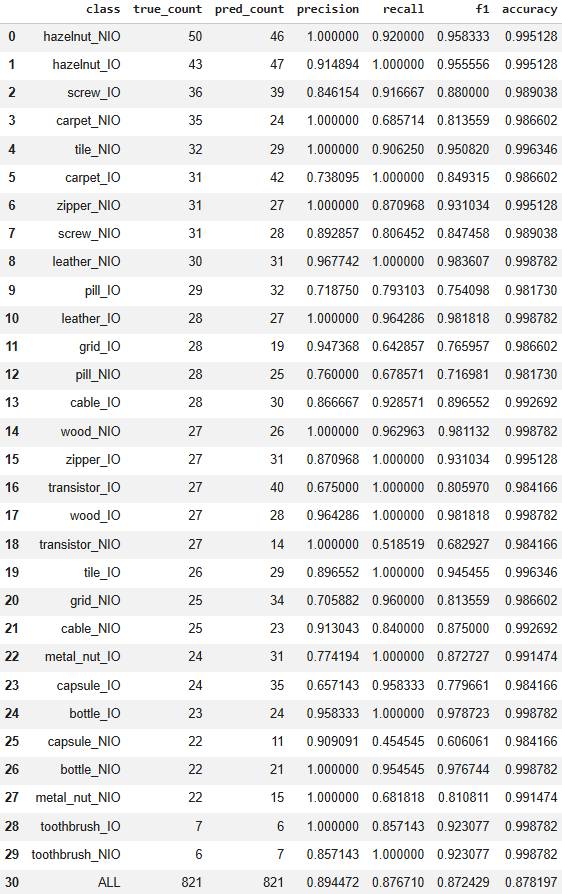

##### MobileNetV3Small-Backbone x 2-Heads-Head

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_premodel("mobilenetv3small", "two_tasks")
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss={"category": "sparse_categorical_crossentropy", "io": "sparse_categorical_crossentropy"},
    metrics={"category": ["accuracy"], "io": ["accuracy"]},
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}",
)

out = train_2heads(inp)

run = dict(name=out.model.name, model=out.model, model_name=out.model.name, lr=lr, seed=seed, epochs=epochs)
zip_path = export_model(run)
print("Exported:", zip_path)


<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - category_accuracy: 0.7701 - category_loss: 1.0295 - io_accuracy: 0.5761 - io_loss: 0.7400 - loss: 1.7696 - val_category_accuracy: 1.0000 - val_category_loss: 0.0071 - val_io_accuracy: 0.7247 - val_io_loss: 0.5231 - val_loss: 0.5314 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - category_accuracy: 0.9997 - category_loss: 0.0135 - io_accuracy: 0.6902 - io_loss: 0.5702 - loss: 0.5837 - val_category_accuracy: 1.0000 - val_category_loss: 0.0024 - val_io_accuracy: 0.7467 - val_io_loss: 0.4763 - val_loss: 0.4779 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - category_accuracy: 0.9999 - category_loss: 0.0061 - io_accuracy: 0.7237 - io_loss: 0.5234 - loss: 0.5295 - val_category_accuracy: 1.0000 - val_category_loss: 0.0017 - val_io_accuracy: 0.7637 - val_io_loss: 0.4614 - val_loss: 0.4640 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - category_accuracy: 1.0000 - category_loss: 0.0038 - io_accuracy: 0.7295 - io_loss: 0.5060 - loss: 0.5099 - val_category_accuracy: 1.0000 - val_category_loss: 0.0010 - val_io_accuracy: 0.7296 - val_io_loss: 0.4734 - val_loss: 0.4741 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - category_accuracy: 1.0000 - category_loss: 0.0031 - io_accuracy: 0.7526 - io_loss: 0.4720 - loss: 0.4751 - val_category_accuracy: 1.0000 - val_category_loss: 7.2151e-04 - val_io_accuracy: 0.7905 - val_io_loss: 0.4184 - val_loss: 0.4172 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - category_accuracy: 1.0000 - category_loss: 0.0025 - io_accuracy: 0.7711 - io_loss: 0.4504 - loss: 0.4529 - val_category_accuracy: 1.0000 - val_category_loss: 5.9525e-04 - val_io_accuracy: 0.7795 - val_io_loss: 0.3976 - val_loss: 0.3980 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - category_accuracy: 1.0000 - category_loss: 0.0016 - io_accuracy: 0.7867 - io_loss: 0.4266 - loss: 0.4282 - val_category_accuracy: 1.0000 - val_category_loss: 4.0635e-04 - val_io_accuracy: 0.8088 - val_io_loss: 0.4090 - val_loss: 0.4107 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - category_accuracy: 1.0000 - category_loss: 0.0013 - io_accuracy: 0.7985 - io_loss: 0.4136 - loss: 0.4148 - val_category_accuracy: 1.0000 - val_category_loss: 3.9350e-04 - val_io_accuracy: 0.7990 - val_io_loss: 0.3865 - val_loss: 0.3859 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - category_accuracy: 1.0000 - category_loss: 0.0012 - io_accuracy: 0.7916 - io_loss: 0.4160 - loss: 0.4172 - val_category_accuracy: 1.0000 - val_category_loss: 3.0791e-04 - val_io_accuracy: 0.8197 - val_io_loss: 0.3718 - val_loss: 0.3715 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - category_accuracy: 0.9993 - category_loss: 0.0017 - io_accuracy: 0.7992 - io_loss: 0.4031 - loss: 0.4048 - val_category_accuracy: 1.0000 - val_category_loss: 3.2251e-04 - val_io_accuracy: 0.8319 - val_io_loss: 0.3669 - val_loss: 0.3669 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - category_accuracy: 1.0000 - category_loss: 9.8398e-04 - io_accuracy: 0.8086 - io_loss: 0.3855 - loss: 0.3865 - val_category_accuracy: 1.0000 - val_category_loss: 2.4144e-04 - val_io_accuracy: 0.8173 - val_io_loss: 0.3548 - val_loss: 0.3554 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - category_accuracy: 1.0000 - category_loss: 8.9130e-04 - io_accuracy: 0.8074 - io_loss: 0.3814 - loss: 0.3822 - val_category_accuracy: 1.0000 - val_category_loss: 2.1091e-04 - val_io_accuracy: 0.8477 - val_io_loss: 0.3284 - val_loss: 0.3296 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - category_accuracy: 1.0000 - category_loss: 6.2722e-04 - io_accuracy: 0.8230 - io_loss: 0.3763 - loss: 0.3770 - val_category_accuracy: 1.0000 - val_category_loss: 1.6542e-04 - val_io_accuracy: 0.8246 - val_io_loss: 0.3398 - val_loss: 0.3406 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - category_accuracy: 1.0000 - category_loss: 6.3215e-04 - io_accuracy: 0.8144 - io_loss: 0.3789 - loss: 0.3795 - val_category_accuracy: 1.0000 - val_category_loss: 1.3690e-04 - val_io_accuracy: 0.8563 - val_io_loss: 0.3239 - val_loss: 0.3236 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - category_accuracy: 1.0000 - category_loss: 5.6101e-04 - io_accuracy: 0.8323 - io_loss: 0.3526 - loss: 0.3532 - val_category_accuracy: 1.0000 - val_category_loss: 1.3586e-04 - val_io_accuracy: 0.8502 - val_io_loss: 0.3216 - val_loss: 0.3209 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - category_accuracy: 1.0000 - category_loss: 6.2680e-04 - io_accuracy: 0.8369 - io_loss: 0.3414 - loss: 0.3420 - val_category_accuracy: 1.0000 - val_category_loss: 1.3539e-04 - val_io_accuracy: 0.8526 - val_io_loss: 0.3326 - val_loss: 0.3347 - learning_rate: 0.0010
Epoch 17/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - category_accuracy: 1.0000 - category_loss: 4.8984e-04 - io_accuracy: 0.8316 - io_loss: 0.3464 - loss: 0.3469 - val_category_accuracy: 1.0000 - val_category_loss: 1.3009e-04 - val_io_accuracy: 0.8745 - val_io_loss: 0.3048 - val_loss: 0.3061 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - category_accuracy: 1.0000 - category_loss: 4.1227e-04 - io_accuracy: 0.8351 - io_loss: 0.3492 - loss: 0.3496 - val_category_accuracy: 1.0000 - val_category_loss: 1.3440e-04 - val_io_accuracy: 0.8404 - val_io_loss: 0.3035 - val_loss: 0.3028 - learning_rate: 0.0010
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - category_accuracy: 1.0000 - category_loss: 3.8852e-04 - io_accuracy: 0.8322 - io_loss: 0.3384 - loss: 0.3388 - val_category_accuracy: 1.0000 - val_category_loss: 9.5868e-05 - val_io_accuracy: 0.8465 - val_io_loss: 0.3216 - val_loss: 0.3223 - learning_rate: 0.0010
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - category_accuracy: 1.0000 - category_loss: 3.8365e-04 - io_accuracy: 0.8348 - io_loss: 0.3402 - loss: 0.3406 - val_category_accuracy: 1.0000 - val_category_loss: 9.1033e-05 - val_io_accuracy: 0.8575 - val_io_loss: 0.2916 - val_loss: 0.2924 - learning_rate: 0.0010
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - category_accuracy: 1.0000 - category_loss: 4.5998e-04 - io_accuracy: 0.8467 - io_loss: 0.3383 - loss: 0.3388 - val_category_accuracy: 1.0000 - val_category_loss: 7.9623e-05 - val_io_accuracy: 0.8477 - val_io_loss: 0.3033 - val_loss: 0.3032 - learning_rate: 0.0010
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - category_accuracy: 1.0000 - category_loss: 2.4716e-04 - io_accuracy: 0.8494 - io_loss: 0.3172 - loss: 0.3175 - val_category_accuracy: 1.0000 - val_category_loss: 7.4025e-05 - val_io_accuracy: 0.8246 - val_io_loss: 0.3171 - val_loss: 0.3173 - learning_rate: 0.0010
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - category_accuracy: 1.0000 - category_loss: 2.7209e-04 - io_accuracy: 0.8455 - io_loss: 0.3207 - loss: 0.3210 - val_category_accuracy: 1.0000 - val_category_loss: 6.0098e-05 - val_io_accuracy: 0.8563 - val_io_loss: 0.3047 - val_loss: 0.3045 - learning_rate: 0.0010
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - category_accuracy: 1.0000 - category_loss: 2.5795e-04 - io_accuracy: 0.8619 - io_loss: 0.3071 - loss: 0.3073 - val_category_accuracy: 1.0000 - val_category_loss: 8.1249e-05 - val_io_accuracy: 0.8210 - val_io_loss: 0.3339 - val_loss: 0.3334 - learning_rate: 0.0010
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - category_accuracy: 1.0000 - category_loss: 2.8875e-04 - io_accuracy: 0.8424 - io_loss: 0.3286 - loss: 0.3289 - val_category_accuracy: 1.0000 - val_category_loss: 6.7704e-05 - val_io_accuracy: 0.8599 - val_io_loss: 0.2884 - val_loss: 0.2884 - learning_rate: 0.0010
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - category_accuracy: 1.0000 - category_loss: 3.3144e-04 - io_accuracy: 0.8403 - io_loss: 0.3286 - loss: 0.3289 - val_category_accuracy: 1.0000 - val_category_loss: 5.0612e-05 - val_io_accuracy: 0.8636 - val_io_loss: 0.2805 - val_loss: 0.2810 - learning_rate: 0.0010
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - category_accuracy: 1.0000 - category_loss: 2.6159e-04 - io_accuracy: 0.8578 - io_loss: 0.3027 - loss: 0.3029 - val_category_accuracy: 1.0000 - val_category_loss: 3.9757e-05 - val_io_accuracy: 0.8538 - val_io_loss: 0.2964 - val_loss: 0.2976 - learning_rate: 0.0010
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - category_accuracy: 1.0000 - category_loss: 2.0776e-04 - io_accuracy: 0.8522 - io_loss: 0.3098 - loss: 0.3101 - val_category_accuracy: 1.0000 - val_category_loss: 3.1609e-05 - val_io_accuracy: 0.8648 - val_io_loss: 0.2942 - val_loss: 0.2936 - learning_rate: 0.0010
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - category_accuracy: 1.0000 - category_loss: 1.8768e-04 - io_accuracy: 0.8589 - io_loss: 0.3066 - loss: 0.3068 - val_category_accuracy: 1.0000 - val_category_loss: 4.7400e-05 - val_io_accuracy: 0.8721 - val_io_loss: 0.2780 - val_loss: 0.2775 - learning_rate: 0.0010
Epoch 30/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - category_accuracy: 1.0000 - category_loss: 2.0207e-04 - io_accuracy: 0.8607 - io_loss: 0.2968 - loss: 0.2970 - val_category_accuracy: 1.0000 - val_category_loss: 3.1218e-05 - val_io_accuracy: 0.8538 - val_io_loss: 0.2839 - val_loss: 0.2851 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 29.
Exported: export/mobilenetv3small_two_tasks_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/18cM72vmB1RqJmib2DNfh3OanucqnB4my/view?usp=sharing",
    "mobilenetv3small_two_tasks_bundle")

wrapped = TwoHeadTo30(model, categories)
df = eval(wrapped, "data/data_augmented_split/val", class_names=CLASS_NAMES_30)
df

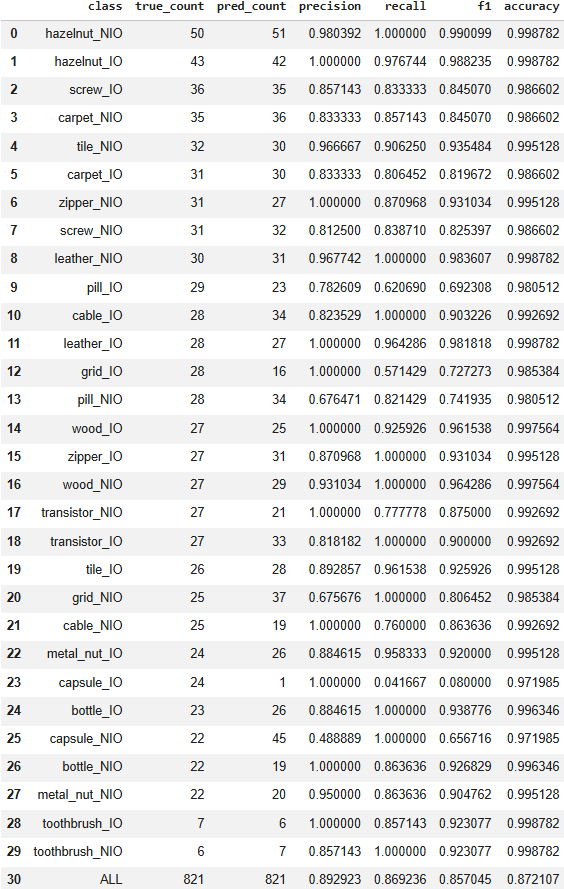

##### Xception-Backbone x Direct-Head

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_premodel("xception", "direct")
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}",
    callback_metric="val_accuracy",
)

out = train(inp)

run = dict(name=out.model.name, model=out.model, model_name=out.model.name, lr=lr, seed=seed, epochs=epochs)
zip_path = export_model(run)
print("Exported:", zip_path)


<details>
  <summary>Training-Log</summary>

```

Downloading data from https://storage.googleapis.com/tensorflow/keras-applications/xception/xception_weights_tf_dim_ordering_tf_kernels_notop.h5
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 71s 243ms/step - accuracy: 0.5928 - loss: 1.1507 - val_accuracy: 0.7917 - val_loss: 0.4214 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.8320 - loss: 0.3823 - val_accuracy: 0.8088 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.8508 - loss: 0.3175 - val_accuracy: 0.8307 - val_loss: 0.3423 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - accuracy: 0.8763 - loss: 0.2773 - val_accuracy: 0.8368 - val_loss: 0.3505 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - accuracy: 0.8826 - loss: 0.2626 - val_accuracy: 0.8514 - val_loss: 0.3181 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.8994 - loss: 0.2304 - val_accuracy: 0.8319 - val_loss: 0.3334 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9048 - loss: 0.2173 - val_accuracy: 0.8538 - val_loss: 0.3085 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.9105 - loss: 0.2140 - val_accuracy: 0.8563 - val_loss: 0.3373 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9170 - loss: 0.2057 - val_accuracy: 0.8563 - val_loss: 0.3322 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.9225 - loss: 0.1857 - val_accuracy: 0.8624 - val_loss: 0.3085 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.9241 - loss: 0.1740 - val_accuracy: 0.8709 - val_loss: 0.3069 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.9350 - loss: 0.1608 - val_accuracy: 0.8794 - val_loss: 0.3064 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9379 - loss: 0.1587 - val_accuracy: 0.8624 - val_loss: 0.3064 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9247 - loss: 0.1746 - val_accuracy: 0.8721 - val_loss: 0.2947 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9352 - loss: 0.1540 - val_accuracy: 0.8782 - val_loss: 0.3073 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - accuracy: 0.9334 - loss: 0.1652 - val_accuracy: 0.8733 - val_loss: 0.3020 - learning_rate: 0.0010
Epoch 17/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9297 - loss: 0.1597
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9298 - loss: 0.1596 - val_accuracy: 0.8648 - val_loss: 0.3114 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9500 - loss: 0.1351 - val_accuracy: 0.8794 - val_loss: 0.2830 - learning_rate: 1.0000e-04
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.9511 - loss: 0.1273 - val_accuracy: 0.8806 - val_loss: 0.2781 - learning_rate: 1.0000e-04
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.9423 - loss: 0.1337 - val_accuracy: 0.8806 - val_loss: 0.2840 - learning_rate: 1.0000e-04
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.9481 - loss: 0.1299 - val_accuracy: 0.8770 - val_loss: 0.2818 - learning_rate: 1.0000e-04
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.9515 - loss: 0.1266 - val_accuracy: 0.8819 - val_loss: 0.2825 - learning_rate: 1.0000e-04
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.9563 - loss: 0.1218 - val_accuracy: 0.8794 - val_loss: 0.2801 - learning_rate: 1.0000e-04
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - accuracy: 0.9507 - loss: 0.1293 - val_accuracy: 0.8806 - val_loss: 0.2783 - learning_rate: 1.0000e-04
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.9543 - loss: 0.1247 - val_accuracy: 0.8794 - val_loss: 0.2819 - learning_rate: 1.0000e-04
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.9547 - loss: 0.1258 - val_accuracy: 0.8794 - val_loss: 0.2804 - learning_rate: 1.0000e-04
Epoch 27/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9569 - loss: 0.1198
Epoch 27: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.9568 - loss: 0.1199 - val_accuracy: 0.8806 - val_loss: 0.2814 - learning_rate: 1.0000e-04
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.9538 - loss: 0.1197 - val_accuracy: 0.8831 - val_loss: 0.2810 - learning_rate: 1.0000e-05
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9561 - loss: 0.1179 - val_accuracy: 0.8831 - val_loss: 0.2812 - learning_rate: 1.0000e-05
Epoch 30/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.9613 - loss: 0.1158 - val_accuracy: 0.8843 - val_loss: 0.2818 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 30.
Exported: export/xception_direct_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1FRBGNLc5Sj268LJ1_9dHD_KWVLi6Ks_s/view?usp=sharing",
    "xception_direct_bundle")

df = eval(model, "data/data_augmented_split/val")
df

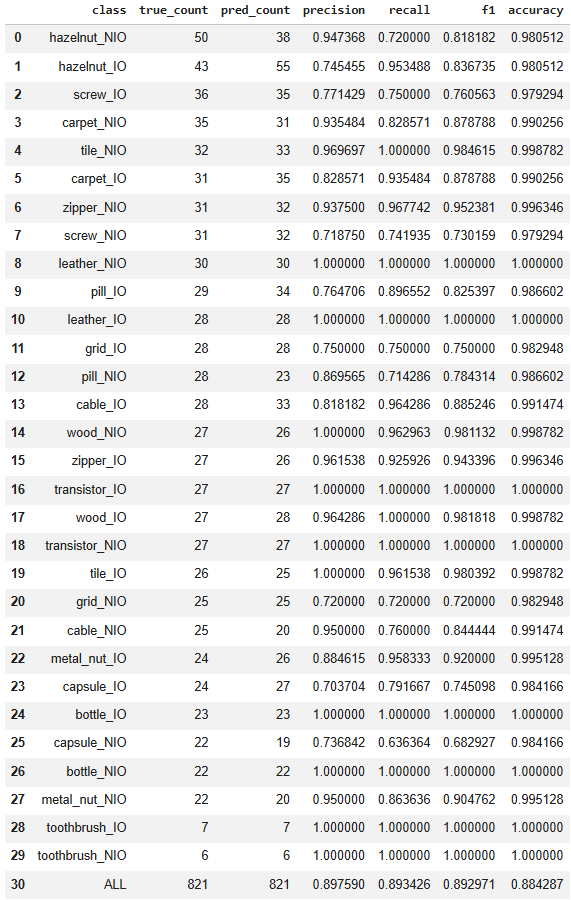

##### Xception-Backbone x Dense-Head

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_premodel("xception", "dense")
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}",
    callback_metric="val_accuracy",
    class_names=CLASS_NAMES_30,
)

out = train(inp)

run = dict(name=out.model.name, model=out.model, model_name=out.model.name, lr=lr, seed=seed, epochs=epochs)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 60s 193ms/step - accuracy: 0.5660 - loss: 1.3678 - val_accuracy: 0.7552 - val_loss: 0.4730 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.7895 - loss: 0.4171 - val_accuracy: 0.8039 - val_loss: 0.4130 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.8301 - loss: 0.3798 - val_accuracy: 0.8307 - val_loss: 0.3565 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.8370 - loss: 0.3377 - val_accuracy: 0.8136 - val_loss: 0.4081 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.8597 - loss: 0.3035 - val_accuracy: 0.8356 - val_loss: 0.3740 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.8596 - loss: 0.2970 - val_accuracy: 0.8222 - val_loss: 0.3865 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.8842 - loss: 0.2641 - val_accuracy: 0.8514 - val_loss: 0.4123 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.8826 - loss: 0.2648 - val_accuracy: 0.8502 - val_loss: 0.3662 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.8987 - loss: 0.2355 - val_accuracy: 0.8331 - val_loss: 0.3662 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 24s 106ms/step - accuracy: 0.8853 - loss: 0.2469 - val_accuracy: 0.8526 - val_loss: 0.3915 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.8920 - loss: 0.2349 - val_accuracy: 0.8624 - val_loss: 0.3677 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.8906 - loss: 0.2575 - val_accuracy: 0.8368 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.8989 - loss: 0.2158 - val_accuracy: 0.8490 - val_loss: 0.3568 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.8991 - loss: 0.2324 - val_accuracy: 0.8404 - val_loss: 0.4055 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.8984 - loss: 0.2225 - val_accuracy: 0.8721 - val_loss: 0.3338 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9069 - loss: 0.2156 - val_accuracy: 0.8660 - val_loss: 0.3399 - learning_rate: 0.0010
Epoch 17/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - accuracy: 0.9132 - loss: 0.1979 - val_accuracy: 0.8831 - val_loss: 0.3128 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.9195 - loss: 0.1818 - val_accuracy: 0.8685 - val_loss: 0.3699 - learning_rate: 0.0010
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.9167 - loss: 0.1899 - val_accuracy: 0.8648 - val_loss: 0.3355 - learning_rate: 0.0010
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.9056 - loss: 0.2292 - val_accuracy: 0.8624 - val_loss: 0.4115 - learning_rate: 0.0010
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - accuracy: 0.9182 - loss: 0.1948 - val_accuracy: 0.8672 - val_loss: 0.3874 - learning_rate: 0.0010
Epoch 22/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9216 - loss: 0.1711
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - accuracy: 0.9216 - loss: 0.1712 - val_accuracy: 0.8624 - val_loss: 0.3708 - learning_rate: 0.0010
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.9301 - loss: 0.1551 - val_accuracy: 0.8794 - val_loss: 0.3117 - learning_rate: 1.0000e-04
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.9486 - loss: 0.1299 - val_accuracy: 0.8758 - val_loss: 0.3100 - learning_rate: 1.0000e-04
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.9392 - loss: 0.1381 - val_accuracy: 0.8879 - val_loss: 0.3066 - learning_rate: 1.0000e-04
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.9431 - loss: 0.1332 - val_accuracy: 0.8806 - val_loss: 0.3262 - learning_rate: 1.0000e-04
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.9467 - loss: 0.1261 - val_accuracy: 0.8892 - val_loss: 0.3294 - learning_rate: 1.0000e-04
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.9486 - loss: 0.1222 - val_accuracy: 0.8819 - val_loss: 0.3094 - learning_rate: 1.0000e-04
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.9454 - loss: 0.1263 - val_accuracy: 0.8843 - val_loss: 0.3183 - learning_rate: 1.0000e-04
Epoch 30/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - accuracy: 0.9484 - loss: 0.1271 - val_accuracy: 0.8831 - val_loss: 0.3264 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 27.
Exported: export/xception_dense_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1L9aMbt_t5wALwHNjdWwBu1IV7AFG0ER2/view?usp=sharing",
    "xception_dense_bundle")

df = eval(model, "data/data_augmented_split/val", class_names=CLASS_NAMES_30,)
df

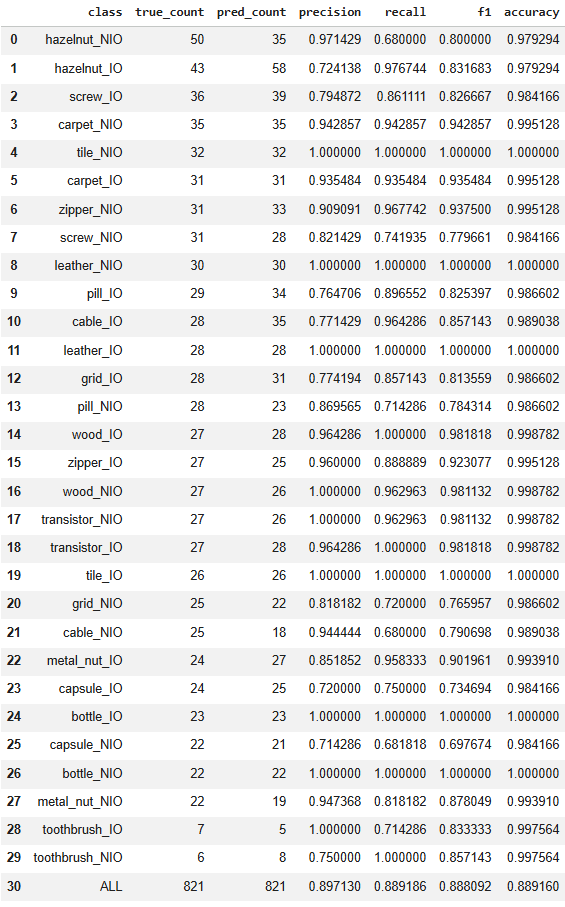

##### Xception-Backbone x 2-Heads-Head

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_premodel("xception", "two_tasks")
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss={"category": "sparse_categorical_crossentropy", "io": "sparse_categorical_crossentropy"},
    metrics={"category": ["accuracy"], "io": ["accuracy"]},
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}",
)

out = train_2heads(inp)

run = dict(name=out.model.name, model=out.model, model_name=out.model.name, lr=lr, seed=seed, epochs=epochs)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 46s 173ms/step - category_accuracy: 0.8766 - category_loss: 0.5762 - io_accuracy: 0.6702 - io_loss: 0.6011 - loss: 1.1772 - val_category_accuracy: 1.0000 - val_category_loss: 0.0060 - val_io_accuracy: 0.7479 - val_io_loss: 0.4669 - val_loss: 0.4729 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - category_accuracy: 1.0000 - category_loss: 0.0049 - io_accuracy: 0.8007 - io_loss: 0.4117 - loss: 0.4166 - val_category_accuracy: 1.0000 - val_category_loss: 0.0022 - val_io_accuracy: 0.8039 - val_io_loss: 0.3853 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - category_accuracy: 1.0000 - category_loss: 0.0022 - io_accuracy: 0.8188 - io_loss: 0.3811 - loss: 0.3833 - val_category_accuracy: 1.0000 - val_category_loss: 0.0013 - val_io_accuracy: 0.8404 - val_io_loss: 0.3612 - val_loss: 0.3631 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - category_accuracy: 1.0000 - category_loss: 0.0017 - io_accuracy: 0.8374 - io_loss: 0.3524 - loss: 0.3541 - val_category_accuracy: 1.0000 - val_category_loss: 8.9688e-04 - val_io_accuracy: 0.8015 - val_io_loss: 0.4074 - val_loss: 0.4081 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - category_accuracy: 1.0000 - category_loss: 9.8701e-04 - io_accuracy: 0.8449 - io_loss: 0.3208 - loss: 0.3217 - val_category_accuracy: 1.0000 - val_category_loss: 5.3860e-04 - val_io_accuracy: 0.8258 - val_io_loss: 0.3684 - val_loss: 0.3696 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - category_accuracy: 1.0000 - category_loss: 7.2034e-04 - io_accuracy: 0.8550 - io_loss: 0.3140 - loss: 0.3147 - val_category_accuracy: 1.0000 - val_category_loss: 4.7969e-04 - val_io_accuracy: 0.8222 - val_io_loss: 0.3693 - val_loss: 0.3714 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - category_accuracy: 1.0000 - category_loss: 5.4282e-04 - io_accuracy: 0.8724 - io_loss: 0.2775 - loss: 0.2780 - val_category_accuracy: 1.0000 - val_category_loss: 4.0590e-04 - val_io_accuracy: 0.8356 - val_io_loss: 0.3736 - val_loss: 0.3732 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - category_accuracy: 1.0000 - category_loss: 4.6129e-04 - io_accuracy: 0.8726 - io_loss: 0.2820 - loss: 0.2824 - val_category_accuracy: 1.0000 - val_category_loss: 2.8961e-04 - val_io_accuracy: 0.8222 - val_io_loss: 0.3522 - val_loss: 0.3503 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - category_accuracy: 1.0000 - category_loss: 3.8207e-04 - io_accuracy: 0.8872 - io_loss: 0.2506 - loss: 0.2510 - val_category_accuracy: 1.0000 - val_category_loss: 2.3957e-04 - val_io_accuracy: 0.8380 - val_io_loss: 0.3336 - val_loss: 0.3357 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - category_accuracy: 1.0000 - category_loss: 3.8641e-04 - io_accuracy: 0.8780 - io_loss: 0.2599 - loss: 0.2603 - val_category_accuracy: 1.0000 - val_category_loss: 2.5881e-04 - val_io_accuracy: 0.8417 - val_io_loss: 0.3392 - val_loss: 0.3400 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - category_accuracy: 1.0000 - category_loss: 2.9384e-04 - io_accuracy: 0.8875 - io_loss: 0.2409 - loss: 0.2411 - val_category_accuracy: 1.0000 - val_category_loss: 2.5468e-04 - val_io_accuracy: 0.8490 - val_io_loss: 0.3657 - val_loss: 0.3663 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - category_accuracy: 1.0000 - category_loss: 3.4586e-04 - io_accuracy: 0.8938 - io_loss: 0.2595 - loss: 0.2598 - val_category_accuracy: 1.0000 - val_category_loss: 2.0551e-04 - val_io_accuracy: 0.8356 - val_io_loss: 0.3302 - val_loss: 0.3305 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - category_accuracy: 1.0000 - category_loss: 2.5767e-04 - io_accuracy: 0.8949 - io_loss: 0.2304 - loss: 0.2306 - val_category_accuracy: 1.0000 - val_category_loss: 1.4161e-04 - val_io_accuracy: 0.8441 - val_io_loss: 0.3392 - val_loss: 0.3421 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - category_accuracy: 1.0000 - category_loss: 2.6619e-04 - io_accuracy: 0.8920 - io_loss: 0.2463 - loss: 0.2465 - val_category_accuracy: 1.0000 - val_category_loss: 1.6759e-04 - val_io_accuracy: 0.8575 - val_io_loss: 0.3512 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - category_accuracy: 1.0000 - category_loss: 2.4828e-04 - io_accuracy: 0.8936 - io_loss: 0.2358 - loss: 0.2361 - val_category_accuracy: 1.0000 - val_category_loss: 1.1673e-04 - val_io_accuracy: 0.8685 - val_io_loss: 0.3298 - val_loss: 0.3327 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - category_accuracy: 1.0000 - category_loss: 1.6362e-04 - io_accuracy: 0.9101 - io_loss: 0.2056 - loss: 0.2057 - val_category_accuracy: 1.0000 - val_category_loss: 9.8283e-05 - val_io_accuracy: 0.8575 - val_io_loss: 0.3502 - val_loss: 0.3516 - learning_rate: 0.0010
Epoch 17/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - category_accuracy: 1.0000 - category_loss: 2.0469e-04 - io_accuracy: 0.9113 - io_loss: 0.2025 - loss: 0.2028
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - category_accuracy: 1.0000 - category_loss: 2.0474e-04 - io_accuracy: 0.9113 - io_loss: 0.2026 - loss: 0.2028 - val_category_accuracy: 1.0000 - val_category_loss: 1.2326e-04 - val_io_accuracy: 0.8636 - val_io_loss: 0.3340 - val_loss: 0.3362 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - category_accuracy: 1.0000 - category_loss: 1.7416e-04 - io_accuracy: 0.9250 - io_loss: 0.1785 - loss: 0.1787 - val_category_accuracy: 1.0000 - val_category_loss: 1.0363e-04 - val_io_accuracy: 0.8672 - val_io_loss: 0.2916 - val_loss: 0.2926 - learning_rate: 1.0000e-04
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - category_accuracy: 1.0000 - category_loss: 1.7117e-04 - io_accuracy: 0.9227 - io_loss: 0.1773 - loss: 0.1774 - val_category_accuracy: 1.0000 - val_category_loss: 8.5889e-05 - val_io_accuracy: 0.8721 - val_io_loss: 0.2966 - val_loss: 0.2991 - learning_rate: 1.0000e-04
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - category_accuracy: 1.0000 - category_loss: 1.5541e-04 - io_accuracy: 0.9272 - io_loss: 0.1733 - loss: 0.1734 - val_category_accuracy: 1.0000 - val_category_loss: 7.4057e-05 - val_io_accuracy: 0.8709 - val_io_loss: 0.2908 - val_loss: 0.2927 - learning_rate: 1.0000e-04
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - category_accuracy: 1.0000 - category_loss: 1.1265e-04 - io_accuracy: 0.9261 - io_loss: 0.1732 - loss: 0.1733 - val_category_accuracy: 1.0000 - val_category_loss: 6.9531e-05 - val_io_accuracy: 0.8697 - val_io_loss: 0.2983 - val_loss: 0.2991 - learning_rate: 1.0000e-04
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - category_accuracy: 1.0000 - category_loss: 1.0438e-04 - io_accuracy: 0.9341 - io_loss: 0.1643 - loss: 0.1644 - val_category_accuracy: 1.0000 - val_category_loss: 6.1449e-05 - val_io_accuracy: 0.8745 - val_io_loss: 0.2935 - val_loss: 0.2935 - learning_rate: 1.0000e-04
Epoch 23/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - category_accuracy: 1.0000 - category_loss: 9.0118e-05 - io_accuracy: 0.9349 - io_loss: 0.1652 - loss: 0.1653
Epoch 23: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - category_accuracy: 1.0000 - category_loss: 9.0146e-05 - io_accuracy: 0.9348 - io_loss: 0.1653 - loss: 0.1654 - val_category_accuracy: 1.0000 - val_category_loss: 5.5934e-05 - val_io_accuracy: 0.8709 - val_io_loss: 0.2964 - val_loss: 0.2948 - learning_rate: 1.0000e-04
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - category_accuracy: 1.0000 - category_loss: 1.0733e-04 - io_accuracy: 0.9305 - io_loss: 0.1659 - loss: 0.1660 - val_category_accuracy: 1.0000 - val_category_loss: 5.7036e-05 - val_io_accuracy: 0.8721 - val_io_loss: 0.2918 - val_loss: 0.2925 - learning_rate: 1.0000e-05
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - category_accuracy: 1.0000 - category_loss: 8.6020e-05 - io_accuracy: 0.9318 - io_loss: 0.1606 - loss: 0.1607 - val_category_accuracy: 1.0000 - val_category_loss: 5.4575e-05 - val_io_accuracy: 0.8782 - val_io_loss: 0.2935 - val_loss: 0.2926 - learning_rate: 1.0000e-05
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - category_accuracy: 1.0000 - category_loss: 8.0658e-05 - io_accuracy: 0.9314 - io_loss: 0.1629 - loss: 0.1630 - val_category_accuracy: 1.0000 - val_category_loss: 5.3516e-05 - val_io_accuracy: 0.8782 - val_io_loss: 0.2963 - val_loss: 0.2926 - learning_rate: 1.0000e-05
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - category_accuracy: 1.0000 - category_loss: 8.0151e-05 - io_accuracy: 0.9278 - io_loss: 0.1706 - loss: 0.1707 - val_category_accuracy: 1.0000 - val_category_loss: 5.3488e-05 - val_io_accuracy: 0.8794 - val_io_loss: 0.2914 - val_loss: 0.2938 - learning_rate: 1.0000e-05
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - category_accuracy: 1.0000 - category_loss: 9.0431e-05 - io_accuracy: 0.9333 - io_loss: 0.1604 - loss: 0.1605 - val_category_accuracy: 1.0000 - val_category_loss: 5.2234e-05 - val_io_accuracy: 0.8782 - val_io_loss: 0.2935 - val_loss: 0.2922 - learning_rate: 1.0000e-05
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - category_accuracy: 1.0000 - category_loss: 8.3849e-05 - io_accuracy: 0.9316 - io_loss: 0.1653 - loss: 0.1654 - val_category_accuracy: 1.0000 - val_category_loss: 5.2082e-05 - val_io_accuracy: 0.8794 - val_io_loss: 0.2942 - val_loss: 0.2925 - learning_rate: 1.0000e-05
Epoch 30/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - category_accuracy: 1.0000 - category_loss: 7.3933e-05 - io_accuracy: 0.9310 - io_loss: 0.1625 - loss: 0.1626 - val_category_accuracy: 1.0000 - val_category_loss: 5.0669e-05 - val_io_accuracy: 0.8806 - val_io_loss: 0.2905 - val_loss: 0.2927 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 28.
Exported: export/xception_two_tasks_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1dHpyI8Y2udgtP_v-kyW75_vbBEJWhXDf/view?usp=sharing",
    "xception_two_tasks_bundle")

wrapped = TwoHeadTo30(model, categories)
df = eval(wrapped, "data/data_augmented_split/val", class_names=CLASS_NAMES_30)
df

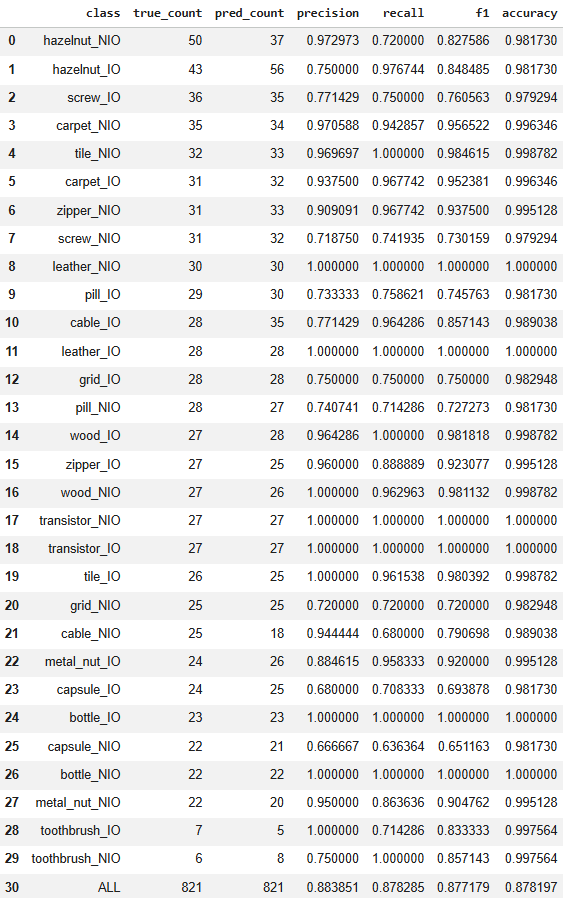

##### VGG16-Backbone x Direct-Head

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_premodel("vgg16", "direct")
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}",
    callback_metric="val_accuracy",
    class_names=CLASS_NAMES_30,
)

out = train(inp)

run = dict(name=out.model.name, model=out.model, model_name=out.model.name, lr=lr, seed=seed, epochs=epochs)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```

Downloading data from https://storage.googleapis.com/tensorflow/keras-applications/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 62s 237ms/step - accuracy: 0.3708 - loss: 4.2452 - val_accuracy: 0.7101 - val_loss: 0.7031 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.7121 - loss: 0.9389 - val_accuracy: 0.7820 - val_loss: 0.4956 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 172ms/step - accuracy: 0.7780 - loss: 0.6262 - val_accuracy: 0.8149 - val_loss: 0.4038 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.8080 - loss: 0.4777 - val_accuracy: 0.8185 - val_loss: 0.3987 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.8242 - loss: 0.4315 - val_accuracy: 0.8477 - val_loss: 0.3311 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.8408 - loss: 0.3753 - val_accuracy: 0.8477 - val_loss: 0.3175 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.8703 - loss: 0.3263 - val_accuracy: 0.8514 - val_loss: 0.3198 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.8625 - loss: 0.3569 - val_accuracy: 0.8490 - val_loss: 0.3284 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.8606 - loss: 0.3289 - val_accuracy: 0.8526 - val_loss: 0.3506 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - accuracy: 0.8649 - loss: 0.3091 - val_accuracy: 0.8538 - val_loss: 0.3052 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 171ms/step - accuracy: 0.8595 - loss: 0.3416 - val_accuracy: 0.8745 - val_loss: 0.2912 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.8719 - loss: 0.2994 - val_accuracy: 0.8648 - val_loss: 0.2877 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.8774 - loss: 0.2854 - val_accuracy: 0.8477 - val_loss: 0.2951 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.8871 - loss: 0.2580 - val_accuracy: 0.8490 - val_loss: 0.3438 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.8887 - loss: 0.2786 - val_accuracy: 0.8636 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 16/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8940 - loss: 0.2620
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.8940 - loss: 0.2620 - val_accuracy: 0.8721 - val_loss: 0.2923 - learning_rate: 0.0010
Epoch 17/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 37s 177ms/step - accuracy: 0.8958 - loss: 0.2325 - val_accuracy: 0.8977 - val_loss: 0.2559 - learning_rate: 1.0000e-04
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.9123 - loss: 0.2089 - val_accuracy: 0.8782 - val_loss: 0.2599 - learning_rate: 1.0000e-04
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.9040 - loss: 0.2158 - val_accuracy: 0.8758 - val_loss: 0.2605 - learning_rate: 1.0000e-04
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.9034 - loss: 0.2287 - val_accuracy: 0.8745 - val_loss: 0.2604 - learning_rate: 1.0000e-04
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 170ms/step - accuracy: 0.9202 - loss: 0.2014 - val_accuracy: 0.8745 - val_loss: 0.2622 - learning_rate: 1.0000e-04
Epoch 22/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9142 - loss: 0.1966
Epoch 22: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.9142 - loss: 0.1966 - val_accuracy: 0.8819 - val_loss: 0.2580 - learning_rate: 1.0000e-04
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 168ms/step - accuracy: 0.9131 - loss: 0.2059 - val_accuracy: 0.8879 - val_loss: 0.2528 - learning_rate: 1.0000e-05
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.9109 - loss: 0.2060 - val_accuracy: 0.8965 - val_loss: 0.2519 - learning_rate: 1.0000e-05
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 169ms/step - accuracy: 0.9123 - loss: 0.2034 - val_accuracy: 0.8952 - val_loss: 0.2478 - learning_rate: 1.0000e-05
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.9172 - loss: 0.1980 - val_accuracy: 0.8916 - val_loss: 0.2478 - learning_rate: 1.0000e-05
Epoch 27/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9132 - loss: 0.1922
Epoch 27: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.9132 - loss: 0.1922 - val_accuracy: 0.8928 - val_loss: 0.2485 - learning_rate: 1.0000e-05
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 17.
Exported: export/vgg16_direct_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/18Dmcc6enkIM5qPug6rGEx5hf_Xb3PPLL/view?usp=sharing",
    "vgg16_direct_bundle")

df = eval(model, "data/data_augmented_split/val", class_names=CLASS_NAMES_30)
df

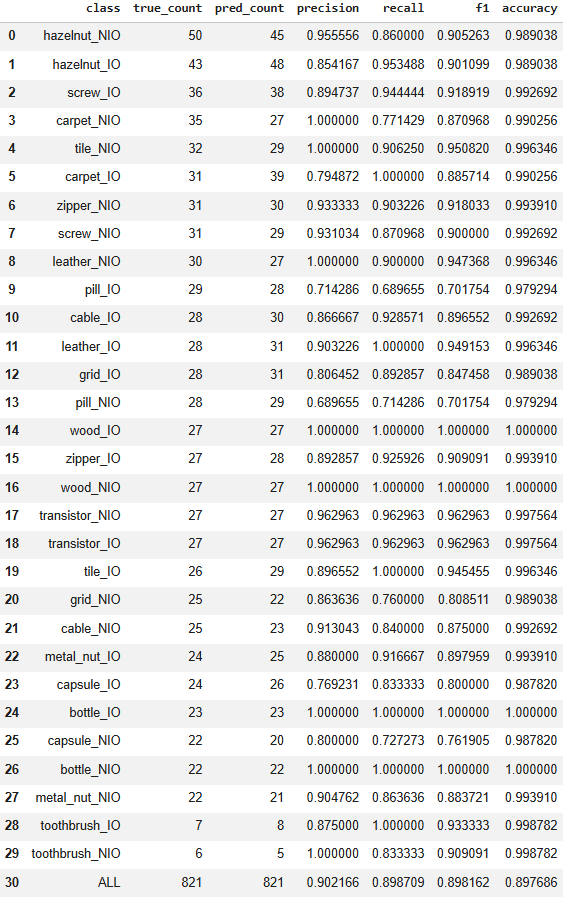

##### VGG16-Backbone x Dense-Head

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_premodel("vgg16", "dense")
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}",
    callback_metric="val_accuracy",
    class_names=CLASS_NAMES_30,
)

out = train(inp)

run = dict(name=out.model.name, model=out.model, model_name=out.model.name, lr=lr, seed=seed, epochs=epochs)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 46s 196ms/step - accuracy: 0.3931 - loss: 2.3234 - val_accuracy: 0.7357 - val_loss: 0.5040 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.7046 - loss: 0.5806 - val_accuracy: 0.7503 - val_loss: 0.4997 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.7502 - loss: 0.5047 - val_accuracy: 0.7954 - val_loss: 0.4152 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - accuracy: 0.7630 - loss: 0.4658 - val_accuracy: 0.8039 - val_loss: 0.4005 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.7839 - loss: 0.4338 - val_accuracy: 0.7942 - val_loss: 0.4060 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.7964 - loss: 0.4196 - val_accuracy: 0.7710 - val_loss: 0.3884 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.8203 - loss: 0.3735 - val_accuracy: 0.8112 - val_loss: 0.3629 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.8137 - loss: 0.3814 - val_accuracy: 0.8076 - val_loss: 0.3783 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.8173 - loss: 0.3653 - val_accuracy: 0.7966 - val_loss: 0.3955 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.8249 - loss: 0.3650 - val_accuracy: 0.8343 - val_loss: 0.3286 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.8229 - loss: 0.3699 - val_accuracy: 0.8380 - val_loss: 0.3377 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.8349 - loss: 0.3354 - val_accuracy: 0.8404 - val_loss: 0.3387 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.8440 - loss: 0.3321 - val_accuracy: 0.8331 - val_loss: 0.3124 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.8476 - loss: 0.3181 - val_accuracy: 0.8222 - val_loss: 0.4106 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.8546 - loss: 0.3055 - val_accuracy: 0.8380 - val_loss: 0.3079 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.8599 - loss: 0.3120 - val_accuracy: 0.8490 - val_loss: 0.3181 - learning_rate: 0.0010
Epoch 17/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.8682 - loss: 0.2941 - val_accuracy: 0.8721 - val_loss: 0.2930 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.8568 - loss: 0.2964 - val_accuracy: 0.8551 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.8546 - loss: 0.3057 - val_accuracy: 0.8356 - val_loss: 0.3400 - learning_rate: 0.0010
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 172ms/step - accuracy: 0.8602 - loss: 0.3056 - val_accuracy: 0.8636 - val_loss: 0.3026 - learning_rate: 0.0010
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.8683 - loss: 0.2981 - val_accuracy: 0.8441 - val_loss: 0.3056 - learning_rate: 0.0010
Epoch 22/30
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8727 - loss: 0.2753
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.8727 - loss: 0.2753 - val_accuracy: 0.8648 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.8796 - loss: 0.2647 - val_accuracy: 0.8831 - val_loss: 0.2623 - learning_rate: 1.0000e-04
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.8874 - loss: 0.2526 - val_accuracy: 0.8758 - val_loss: 0.2644 - learning_rate: 1.0000e-04
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.8813 - loss: 0.2489 - val_accuracy: 0.8879 - val_loss: 0.2558 - learning_rate: 1.0000e-04
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.8913 - loss: 0.2464 - val_accuracy: 0.8782 - val_loss: 0.2669 - learning_rate: 1.0000e-04
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 172ms/step - accuracy: 0.8945 - loss: 0.2342 - val_accuracy: 0.8758 - val_loss: 0.2712 - learning_rate: 1.0000e-04
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.8871 - loss: 0.2314 - val_accuracy: 0.8831 - val_loss: 0.2663 - learning_rate: 1.0000e-04
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.9016 - loss: 0.2238 - val_accuracy: 0.8831 - val_loss: 0.2568 - learning_rate: 1.0000e-04
Epoch 30/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.8962 - loss: 0.2322 - val_accuracy: 0.8952 - val_loss: 0.2518 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.
Exported: export/vgg16_dense_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1PElho0Uwpo7AArGtNugX7c3IeV5MJRN0/view?usp=sharing",
    "vgg16_dense_bundle")

df = eval(model, "data/data_augmented_split/val", class_names=CLASS_NAMES_30)
df

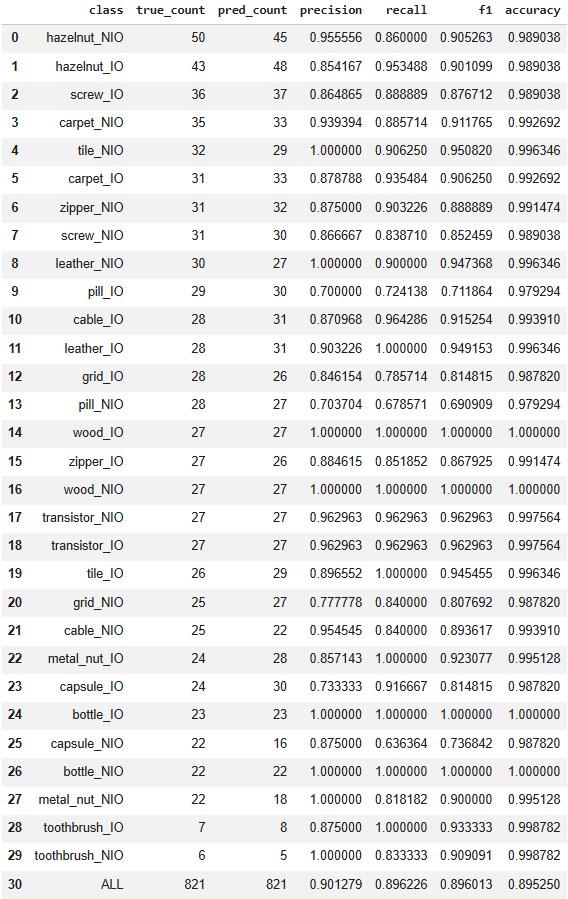

##### VGG16-Backbone x 2-Heads-Head

In [ ]:
epochs = 30
seed = 43
lr = 1e-3

model = make_premodel("vgg16", "two_tasks")
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss={"category": "sparse_categorical_crossentropy", "io": "sparse_categorical_crossentropy"},
    metrics={"category": ["accuracy"], "io": ["accuracy"]},
)

inp = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}",
)

out = train_2heads(inp)

run = dict(name=out.model.name, model=out.model, model_name=out.model.name, lr=lr, seed=seed, epochs=epochs)
zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - category_accuracy: 0.7195 - category_loss: 1.5163 - io_accuracy: 0.5877 - io_loss: 1.4961 - loss: 3.0124 - val_category_accuracy: 0.9988 - val_category_loss: 0.0066 - val_io_accuracy: 0.7467 - val_io_loss: 0.4959 - val_loss: 0.5009 - learning_rate: 0.0010
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 0.9973 - category_loss: 0.0181 - io_accuracy: 0.7336 - io_loss: 0.6012 - loss: 0.6193 - val_category_accuracy: 1.0000 - val_category_loss: 0.0018 - val_io_accuracy: 0.8124 - val_io_loss: 0.4254 - val_loss: 0.4245 - learning_rate: 0.0010
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 37s 177ms/step - category_accuracy: 0.9977 - category_loss: 0.0099 - io_accuracy: 0.7645 - io_loss: 0.5219 - loss: 0.5318 - val_category_accuracy: 1.0000 - val_category_loss: 0.0013 - val_io_accuracy: 0.8222 - val_io_loss: 0.3925 - val_loss: 0.3906 - learning_rate: 0.0010
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - category_accuracy: 0.9994 - category_loss: 0.0051 - io_accuracy: 0.7812 - io_loss: 0.4605 - loss: 0.4656 - val_category_accuracy: 1.0000 - val_category_loss: 4.7180e-04 - val_io_accuracy: 0.8002 - val_io_loss: 0.3718 - val_loss: 0.3744 - learning_rate: 0.0010
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - category_accuracy: 0.9999 - category_loss: 0.0030 - io_accuracy: 0.7892 - io_loss: 0.4271 - loss: 0.4301 - val_category_accuracy: 1.0000 - val_category_loss: 3.5464e-04 - val_io_accuracy: 0.8429 - val_io_loss: 0.3374 - val_loss: 0.3387 - learning_rate: 0.0010
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - category_accuracy: 1.0000 - category_loss: 0.0022 - io_accuracy: 0.8101 - io_loss: 0.4179 - loss: 0.4200 - val_category_accuracy: 1.0000 - val_category_loss: 2.5822e-04 - val_io_accuracy: 0.8270 - val_io_loss: 0.3456 - val_loss: 0.3463 - learning_rate: 0.0010
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 1.0000 - category_loss: 0.0024 - io_accuracy: 0.8145 - io_loss: 0.3869 - loss: 0.3893 - val_category_accuracy: 1.0000 - val_category_loss: 2.7057e-04 - val_io_accuracy: 0.8185 - val_io_loss: 0.3587 - val_loss: 0.3596 - learning_rate: 0.0010
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 0.9995 - category_loss: 0.0028 - io_accuracy: 0.8062 - io_loss: 0.3890 - loss: 0.3918 - val_category_accuracy: 1.0000 - val_category_loss: 1.7708e-04 - val_io_accuracy: 0.8234 - val_io_loss: 0.3474 - val_loss: 0.3466 - learning_rate: 0.0010
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - category_accuracy: 0.9997 - category_loss: 0.0016 - io_accuracy: 0.8236 - io_loss: 0.3730 - loss: 0.3746 - val_category_accuracy: 1.0000 - val_category_loss: 1.5104e-04 - val_io_accuracy: 0.8368 - val_io_loss: 0.3179 - val_loss: 0.3175 - learning_rate: 0.0010
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 0.9997 - category_loss: 0.0017 - io_accuracy: 0.8410 - io_loss: 0.3548 - loss: 0.3565 - val_category_accuracy: 1.0000 - val_category_loss: 1.2879e-04 - val_io_accuracy: 0.8551 - val_io_loss: 0.3247 - val_loss: 0.3236 - learning_rate: 0.0010
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 1.0000 - category_loss: 0.0011 - io_accuracy: 0.8303 - io_loss: 0.3626 - loss: 0.3637 - val_category_accuracy: 1.0000 - val_category_loss: 1.7009e-04 - val_io_accuracy: 0.8343 - val_io_loss: 0.3418 - val_loss: 0.3427 - learning_rate: 0.0010
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - category_accuracy: 0.9991 - category_loss: 0.0023 - io_accuracy: 0.8371 - io_loss: 0.3422 - loss: 0.3445 - val_category_accuracy: 1.0000 - val_category_loss: 1.1054e-04 - val_io_accuracy: 0.8392 - val_io_loss: 0.3154 - val_loss: 0.3170 - learning_rate: 0.0010
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - category_accuracy: 1.0000 - category_loss: 7.8809e-04 - io_accuracy: 0.8381 - io_loss: 0.3469 - loss: 0.3477 - val_category_accuracy: 1.0000 - val_category_loss: 1.2126e-04 - val_io_accuracy: 0.8453 - val_io_loss: 0.3050 - val_loss: 0.3055 - learning_rate: 0.0010
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - category_accuracy: 1.0000 - category_loss: 6.7530e-04 - io_accuracy: 0.8542 - io_loss: 0.3214 - loss: 0.3221 - val_category_accuracy: 1.0000 - val_category_loss: 7.2671e-05 - val_io_accuracy: 0.8380 - val_io_loss: 0.3183 - val_loss: 0.3191 - learning_rate: 0.0010
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - category_accuracy: 1.0000 - category_loss: 0.0013 - io_accuracy: 0.8504 - io_loss: 0.3235 - loss: 0.3248 - val_category_accuracy: 1.0000 - val_category_loss: 7.8735e-05 - val_io_accuracy: 0.8551 - val_io_loss: 0.2900 - val_loss: 0.2904 - learning_rate: 0.0010
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 1.0000 - category_loss: 7.2977e-04 - io_accuracy: 0.8595 - io_loss: 0.3174 - loss: 0.3181 - val_category_accuracy: 1.0000 - val_category_loss: 8.8713e-05 - val_io_accuracy: 0.8624 - val_io_loss: 0.2978 - val_loss: 0.2988 - learning_rate: 0.0010
Epoch 17/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 1.0000 - category_loss: 6.5159e-04 - io_accuracy: 0.8613 - io_loss: 0.3007 - loss: 0.3013 - val_category_accuracy: 1.0000 - val_category_loss: 7.9025e-05 - val_io_accuracy: 0.8685 - val_io_loss: 0.2940 - val_loss: 0.2958 - learning_rate: 0.0010
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - category_accuracy: 0.9998 - category_loss: 8.1581e-04 - io_accuracy: 0.8563 - io_loss: 0.3070 - loss: 0.3078 - val_category_accuracy: 1.0000 - val_category_loss: 2.4081e-05 - val_io_accuracy: 0.8709 - val_io_loss: 0.2895 - val_loss: 0.2904 - learning_rate: 0.0010
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 1.0000 - category_loss: 7.6736e-04 - io_accuracy: 0.8501 - io_loss: 0.3239 - loss: 0.3247 - val_category_accuracy: 1.0000 - val_category_loss: 5.5518e-05 - val_io_accuracy: 0.8502 - val_io_loss: 0.3081 - val_loss: 0.3088 - learning_rate: 0.0010
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - category_accuracy: 1.0000 - category_loss: 7.8403e-04 - io_accuracy: 0.8474 - io_loss: 0.3316 - loss: 0.3324 - val_category_accuracy: 1.0000 - val_category_loss: 2.7699e-05 - val_io_accuracy: 0.8831 - val_io_loss: 0.2713 - val_loss: 0.2712 - learning_rate: 0.0010
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 39s 190ms/step - category_accuracy: 0.9996 - category_loss: 0.0021 - io_accuracy: 0.8653 - io_loss: 0.3044 - loss: 0.3065 - val_category_accuracy: 1.0000 - val_category_loss: 2.4800e-05 - val_io_accuracy: 0.8672 - val_io_loss: 0.2766 - val_loss: 0.2770 - learning_rate: 0.0010
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 40s 186ms/step - category_accuracy: 1.0000 - category_loss: 6.2105e-04 - io_accuracy: 0.8658 - io_loss: 0.2830 - loss: 0.2836 - val_category_accuracy: 1.0000 - val_category_loss: 2.3838e-05 - val_io_accuracy: 0.8831 - val_io_loss: 0.2661 - val_loss: 0.2660 - learning_rate: 0.0010
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - category_accuracy: 0.9996 - category_loss: 0.0012 - io_accuracy: 0.8626 - io_loss: 0.2868 - loss: 0.2880 - val_category_accuracy: 1.0000 - val_category_loss: 2.3239e-05 - val_io_accuracy: 0.8563 - val_io_loss: 0.2931 - val_loss: 0.2926 - learning_rate: 0.0010
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - category_accuracy: 1.0000 - category_loss: 4.3647e-04 - io_accuracy: 0.8640 - io_loss: 0.2953 - loss: 0.2957 - val_category_accuracy: 1.0000 - val_category_loss: 2.0075e-05 - val_io_accuracy: 0.8819 - val_io_loss: 0.2709 - val_loss: 0.2715 - learning_rate: 0.0010
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 37s 177ms/step - category_accuracy: 0.9999 - category_loss: 0.0010 - io_accuracy: 0.8761 - io_loss: 0.2773 - loss: 0.2784 - val_category_accuracy: 1.0000 - val_category_loss: 2.4470e-05 - val_io_accuracy: 0.8721 - val_io_loss: 0.2777 - val_loss: 0.2782 - learning_rate: 0.0010
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 38s 182ms/step - category_accuracy: 1.0000 - category_loss: 5.9932e-04 - io_accuracy: 0.8751 - io_loss: 0.2771 - loss: 0.2777 - val_category_accuracy: 1.0000 - val_category_loss: 1.6795e-05 - val_io_accuracy: 0.8782 - val_io_loss: 0.2639 - val_loss: 0.2645 - learning_rate: 0.0010
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - category_accuracy: 1.0000 - category_loss: 3.6593e-04 - io_accuracy: 0.8809 - io_loss: 0.2636 - loss: 0.2640 - val_category_accuracy: 1.0000 - val_category_loss: 1.3794e-05 - val_io_accuracy: 0.8733 - val_io_loss: 0.2746 - val_loss: 0.2754 - learning_rate: 0.0010
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 37s 177ms/step - category_accuracy: 1.0000 - category_loss: 7.3582e-04 - io_accuracy: 0.8737 - io_loss: 0.2834 - loss: 0.2841 - val_category_accuracy: 1.0000 - val_category_loss: 1.0036e-05 - val_io_accuracy: 0.8672 - val_io_loss: 0.2766 - val_loss: 0.2765 - learning_rate: 0.0010
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 1.0000 - category_loss: 3.2153e-04 - io_accuracy: 0.8829 - io_loss: 0.2558 - loss: 0.2561 - val_category_accuracy: 1.0000 - val_category_loss: 1.5881e-05 - val_io_accuracy: 0.8758 - val_io_loss: 0.2639 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 30/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - category_accuracy: 0.9999 - category_loss: 6.8384e-04 - io_accuracy: 0.8761 - io_loss: 0.2682 - loss: 0.2689 - val_category_accuracy: 1.0000 - val_category_loss: 1.1977e-05 - val_io_accuracy: 0.8770 - val_io_loss: 0.2728 - val_loss: 0.2733 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 26.
Exported: export/vgg16_two_tasks_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1bMKF97U8eFwdb_9Edy7kJ6LQnZtSBAyt/view?usp=sharing",
    "vgg16_two_tasks_bundle")

wrapped = TwoHeadTo30(model, categories)
df = eval(wrapped, "data/data_augmented_split/val", class_names=CLASS_NAMES_30)
df

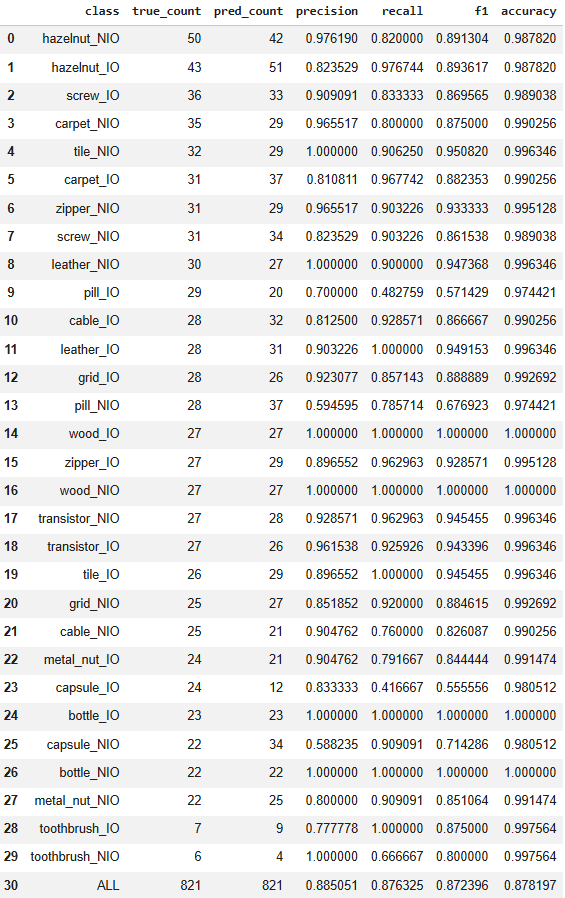

#### 5.3.2.4 Model Selection

Ergebnisse: (Nach F1-Score, absteigend)

| Rank | Backbone   | Head    | F1       |
|-----:|------------|---------|----------|
| 1    | Mobile     | Direct  | 0.908737 |
| 2    | VGG        | Direct  | 0.898162 |
| 3    | VGG        | Dense   | 0.896013 |
| 4    | Xception   | Direct  | 0.892971 |
| 5    | Xception   | Dense   | 0.888092 |
| 6    | Xception   | 2-head  | 0.877179 |
| 7    | Mobile     | Dense   | 0.872429 |
| 8    | VGG        | 2-head  | 0.872396 |
| 9    | Mobile     | 2-head  | 0.857045 |

Für unseren Use-Case scheint es, als hätte der Backbone keinen so großen Einfluss. Die Auwertung lässt vermuten, das für unseren Use-Case der Head eine größere Rolle spielt. "Direct" scheint am vielversprechensten, dann "Dense" und zuletzt "2-head".

### 5.3.3 Fine-Tuning

#### 5.3.3.1 Fine-Tuning (with Keras Guide)

Für das Fine-Tuning halten wir uns an den [Keras-Guide](https://keras.io/guides/transfer_learning/#the-typical-transferlearning-workflow).

Der darin vorgeschlagene Ablauf ist:

1. Instantiate a base model and load pre-trained weights into it.
2. Freeze all layers in the base model by setting trainable = False.
3. Create a new model on top of the output of one (or several) layers from the base model.
4. Train your new model on your new dataset.
5. Unfreeze part of the base model

Man muss dabei vorallem auf Overfitting achten. Aufgrund dessen haben wir die Learning Rate und die Anzahl der Epochen im Fine-Tuning Durchlauf (5) sehr niedrig eingestellt. Im Schritt 5 haben wir das gesamte Base-Modell unfreezed.

In [ ]:
tf.keras.utils.set_random_seed(43)
input_shape = (180, 180, 3)

# 1.
base_model = keras.applications.MobileNetV3Small(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
    pooling="avg",
)

# 2.
base_model.trainable = False

# 3. (Best head evaluated from section 5.3.2.4)
inputs = keras.Input(shape=input_shape, name="image")

x = keras.applications.mobilenet_v3.preprocess_input(inputs)
x = base_model(x, training=False)

x = layers.Dropout(0.3)(x)
outputs = layers.Dense(30, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="mobilenetv3small_direct_finetuning")

# 4
train_ds = keras.utils.image_dataset_from_directory(
    "data/data_augmented_split/train",
    seed=43,
    image_size=image_size,
    batch_size=32,
)

val_ds = keras.utils.image_dataset_from_directory(
    "data/data_augmented_split/val",
    seed=43,
    image_size=image_size,
    batch_size=32,
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), # Much higher learning rate
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    verbose=1,
)

# 5 (The fine tuning)
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5), # Very low learning rate
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1,
)

<details>
  <summary>Training-Log</summary>

```

Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 59s 209ms/step - accuracy: 0.4197 - loss: 1.7900 - val_accuracy: 0.7138 - val_loss: 0.5672
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.7034 - loss: 0.5989 - val_accuracy: 0.7637 - val_loss: 0.4634
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7533 - loss: 0.5065 - val_accuracy: 0.7954 - val_loss: 0.4263
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7805 - loss: 0.4453 - val_accuracy: 0.8246 - val_loss: 0.3872
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7977 - loss: 0.4134 - val_accuracy: 0.8404 - val_loss: 0.3649
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8234 - loss: 0.3815 - val_accuracy: 0.8246 - val_loss: 0.3555
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8265 - loss: 0.3679 - val_accuracy: 0.8611 - val_loss: 0.3285
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8465 - loss: 0.3387 - val_accuracy: 0.8404 - val_loss: 0.3378
Epoch 9/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8427 - loss: 0.3327 - val_accuracy: 0.8636 - val_loss: 0.3179
Epoch 10/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8585 - loss: 0.3201 - val_accuracy: 0.8587 - val_loss: 0.3072
Epoch 11/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8673 - loss: 0.3038 - val_accuracy: 0.8782 - val_loss: 0.2961
Epoch 12/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8542 - loss: 0.3182 - val_accuracy: 0.8879 - val_loss: 0.2849
Epoch 13/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8721 - loss: 0.2964 - val_accuracy: 0.8794 - val_loss: 0.2884
Epoch 14/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8740 - loss: 0.2910 - val_accuracy: 0.8599 - val_loss: 0.2924
Epoch 15/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8796 - loss: 0.2841 - val_accuracy: 0.8660 - val_loss: 0.2805
Epoch 16/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8754 - loss: 0.2803 - val_accuracy: 0.8721 - val_loss: 0.2835
Epoch 17/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8761 - loss: 0.2865 - val_accuracy: 0.8965 - val_loss: 0.2760
Epoch 18/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8852 - loss: 0.2657 - val_accuracy: 0.8733 - val_loss: 0.2735
Epoch 19/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8840 - loss: 0.2629 - val_accuracy: 0.8733 - val_loss: 0.2726
Epoch 20/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8861 - loss: 0.2566 - val_accuracy: 0.8660 - val_loss: 0.2718
Epoch 21/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8908 - loss: 0.2512 - val_accuracy: 0.8831 - val_loss: 0.2624
Epoch 22/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8912 - loss: 0.2483 - val_accuracy: 0.8892 - val_loss: 0.2557
Epoch 23/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9031 - loss: 0.2341 - val_accuracy: 0.8770 - val_loss: 0.2619
Epoch 24/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8842 - loss: 0.2591 - val_accuracy: 0.8879 - val_loss: 0.2598
Epoch 25/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8907 - loss: 0.2536 - val_accuracy: 0.8697 - val_loss: 0.2563
Epoch 26/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8947 - loss: 0.2446 - val_accuracy: 0.8855 - val_loss: 0.2520
Epoch 27/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8970 - loss: 0.2373 - val_accuracy: 0.8904 - val_loss: 0.2581
Epoch 28/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9005 - loss: 0.2333 - val_accuracy: 0.8977 - val_loss: 0.2597
Epoch 29/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9024 - loss: 0.2250 - val_accuracy: 0.8916 - val_loss: 0.2558
Epoch 30/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9004 - loss: 0.2302 - val_accuracy: 0.8952 - val_loss: 0.2477
Epoch 1/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 92s 197ms/step - accuracy: 0.3866 - loss: 4.0285 - val_accuracy: 0.8173 - val_loss: 0.4663
Epoch 2/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.5393 - loss: 1.7609 - val_accuracy: 0.7917 - val_loss: 0.5544
Epoch 3/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6500 - loss: 1.1637 - val_accuracy: 0.8039 - val_loss: 0.4912
Epoch 4/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6936 - loss: 0.9206 - val_accuracy: 0.8136 - val_loss: 0.4516
Epoch 5/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7277 - loss: 0.7910 - val_accuracy: 0.8222 - val_loss: 0.4264
Epoch 6/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.7526 - loss: 0.7335 - val_accuracy: 0.8124 - val_loss: 0.4230
Epoch 7/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7723 - loss: 0.6225 - val_accuracy: 0.8173 - val_loss: 0.4268
Epoch 8/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.7709 - loss: 0.6070 - val_accuracy: 0.8210 - val_loss: 0.4202
Epoch 9/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.7829 - loss: 0.5615 - val_accuracy: 0.8429 - val_loss: 0.3830
Epoch 10/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7934 - loss: 0.5259 - val_accuracy: 0.8392 - val_loss: 0.3961

```

In [ ]:
df = eval(model, "data/data_augmented_split/val")
df

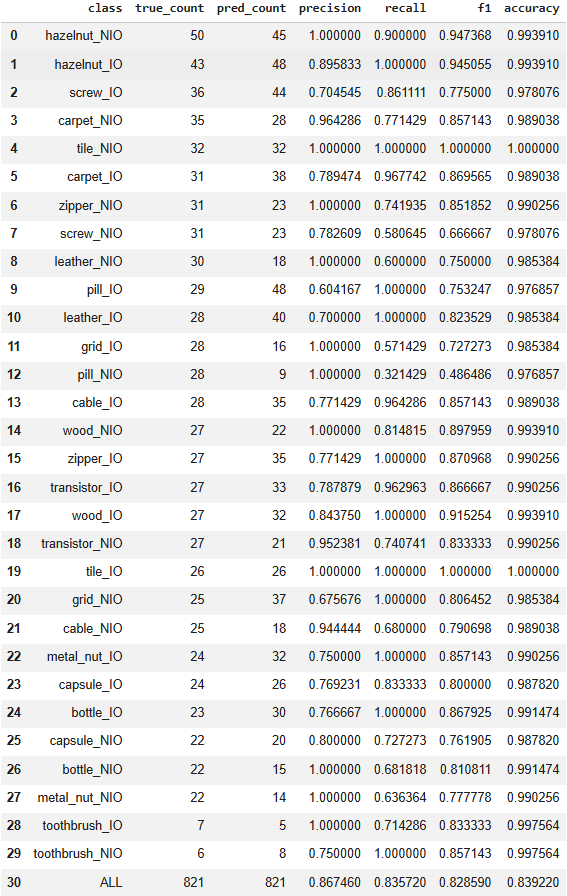

#### 5.3.3.2 Fine-Tuning the best model

Die Idee ist, dass wir unser bestes Modell nehmen und in diesem nur weniger Layer des Backbones entfreezen und minimal zu trainieren um damit das Modell etwas zu tunen.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np

seed = 43
tf.keras.utils.set_random_seed(seed)

# Best model from model selection
model = import_model(
    "https://drive.google.com/file/d/18FVBX1Bm6kIrs8KDFqa-3ldUvGUtNwr_/view?usp=sharing",
    "mobilenetv3small_direct_bundle"
)

backbone = None
for layer in model.layers:
    if isinstance(layer, keras.Model): # The real backbone
        backbone = layer
        break

learningrate = 3e-6
epochs = 10

# Unfreeze only a 15 layers at the end
backbone.trainable = True
for l in backbone.layers[:-15]:
    l.trainable = False

# Keep BatchNorm frozen (stability)
# From keras guide: https://keras.io/guides/transfer_learning/#standardizing-the-data
# "When you unfreeze a model that contains BatchNormalization layers in order
#  to do fine-tuning, you should keep the BatchNormalization layers in inference
#  mode by passing training=False when calling the base model. Otherwise the updates
#  applied to the non-trainable weights will suddenly destroy what the model has learned.""
for l in backbone.layers:
    if isinstance(l, layers.BatchNormalization):
        l.trainable = False

# Fine-Tune Training
model.compile(
    optimizer=keras.optimizers.Adam(learningrate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inp_ft = TrainInput(
    data_dir="data/data_augmented_split",
    model=model,
    seed=seed,
    epochs=epochs,
    tensorboard_logdir=f"logs/{model.name}_finetune_from_best",
    callback_metric="val_accuracy"
    )

out_ft = train(inp_ft)

run = dict(
    name=f"{out_ft.model.name}_finetuned_the_best_model",
    model=out_ft.model,
    model_name=out_ft.model.name,
    lr=float(learningrate),
    seed=int(seed),
    epochs=int(epochs),
)

zip_path = export_model(run)
print("Exported:", zip_path)

<details>
  <summary>Training-Log</summary>

```
Found 6562 files belonging to 30 classes.
Found 821 files belonging to 30 classes.
Epoch 1/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step - accuracy: 0.9032 - loss: 0.2288 - val_accuracy: 0.9086 - val_loss: 0.2429 - learning_rate: 3.0000e-06
Epoch 2/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9130 - loss: 0.2194 - val_accuracy: 0.9086 - val_loss: 0.2412 - learning_rate: 3.0000e-06
Epoch 3/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9084 - loss: 0.2250 - val_accuracy: 0.9099 - val_loss: 0.2405 - learning_rate: 3.0000e-06
Epoch 4/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9196 - loss: 0.2111 - val_accuracy: 0.9074 - val_loss: 0.2397 - learning_rate: 3.0000e-06
Epoch 5/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9102 - loss: 0.2208 - val_accuracy: 0.9086 - val_loss: 0.2401 - learning_rate: 3.0000e-06
Epoch 6/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9164 - loss: 0.2151 - val_accuracy: 0.9062 - val_loss: 0.2381 - learning_rate: 3.0000e-06
Epoch 7/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9138 - loss: 0.2152 - val_accuracy: 0.9086 - val_loss: 0.2374 - learning_rate: 3.0000e-06
Epoch 8/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9223 - loss: 0.2060 - val_accuracy: 0.9111 - val_loss: 0.2385 - learning_rate: 3.0000e-06
Epoch 9/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9199 - loss: 0.2115 - val_accuracy: 0.9111 - val_loss: 0.2385 - learning_rate: 3.0000e-06
Epoch 10/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9154 - loss: 0.2098 - val_accuracy: 0.9086 - val_loss: 0.2387 - learning_rate: 3.0000e-06
Restoring model weights from the end of the best epoch: 8.
Exported: export/mobilenetv3small_direct_finetuned_the_best_model_bundle.zip

```

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1d0d7fHSglLbsoTJKerJezExdFE_ylS1a/view?usp=sharing",
    "mobilenetv3small_direct_finetuned_the_best_model_bundle")

df = eval(model, "data/data_augmented_split/val")
df

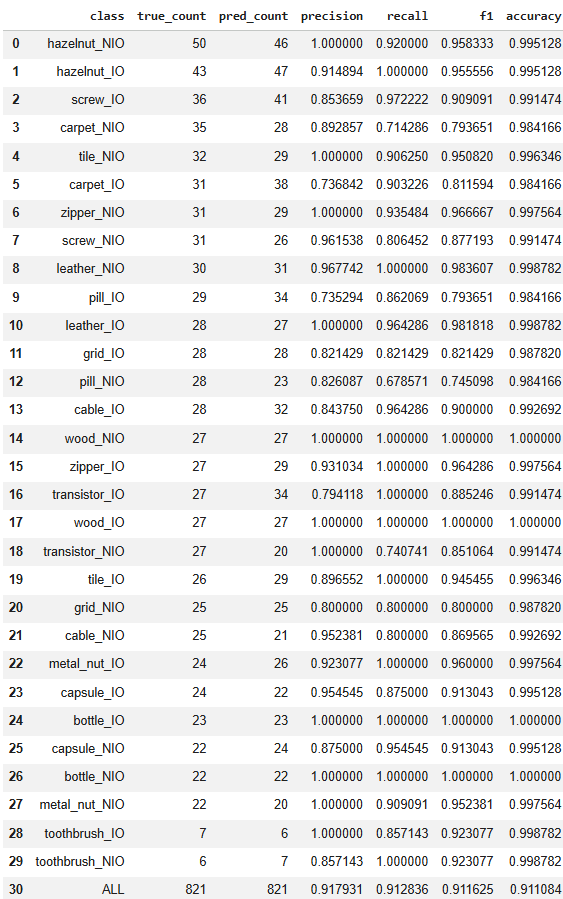

### 5.3.4 Evaluation

In [ ]:
model = import_model(
    "https://drive.google.com/file/d/1d0d7fHSglLbsoTJKerJezExdFE_ylS1a/view?usp=sharing",
    "mobilenetv3small_direct_finetuned_the_best_model_bundle")

df = eval(model, "data/data_augmented_split/test")
df

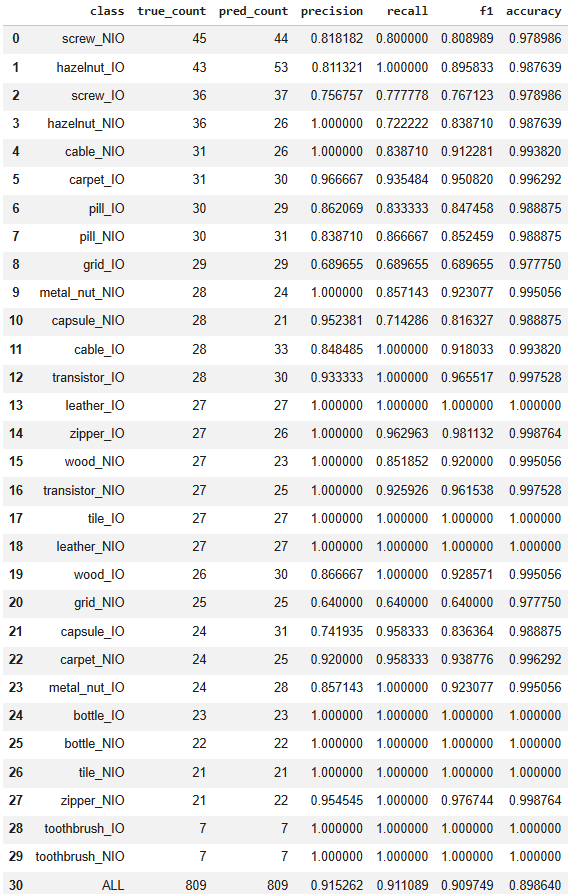

In [ ]:
cm_counts = plot_confusionmatrix(
    model,
    "data/data_augmented_split/val",
    batch_size=32,
    seed=43,
)

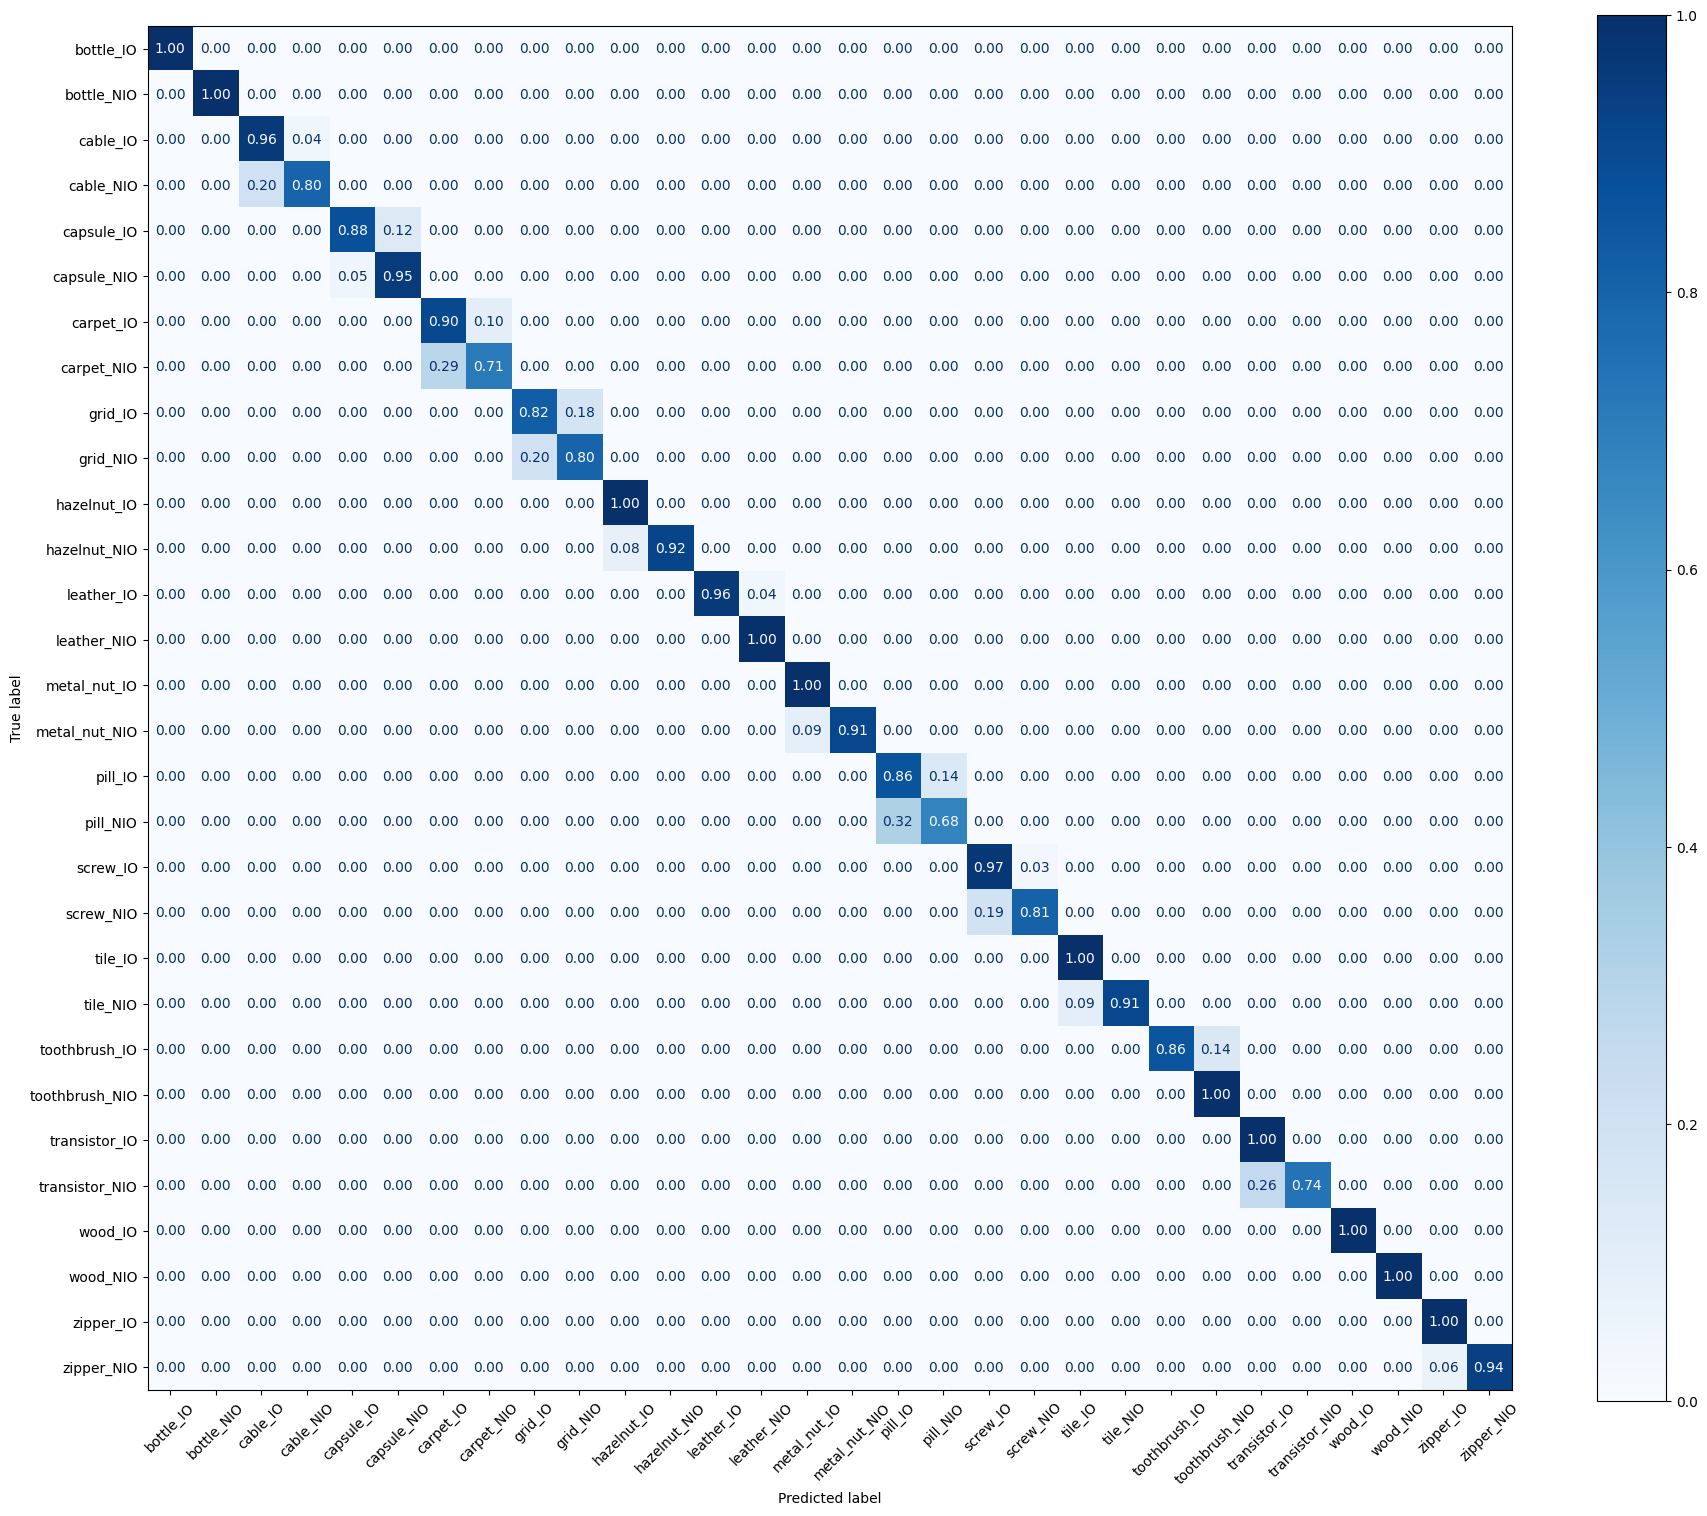

Insgesamt zeigt sich, wie vermutet, das Transfer Learning mit vortraintierten Modellen deutlich bessere Ergebnisse liefern als die selbst von Scratch trainierten Modelle.

- Unsere Performancemetrik, der F1-Score, ist auf dem Evaluationsdaten ist ähnlich gut, wie auf dem Validierungsdaten. Dies zeigt, dass wir nicht in Overfitting gelaufen sind.

- Die Konfusionsmatrix zeigt, dass das Modell die IO/NIOs der Kategorien Pill, Grid und Transistor noch etwas durcheinander bringt. Es gibt keinen Ausreißer, in dem die Kategorien vertauscht wurden.